In [1]:
# imports and settings
import logging
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import gaussian_kde

import pcntoolkit.util.output
from pcntoolkit import (
    HBR,
    NormativeModel,
    NormData,
    SHASHbLikelihood,
    make_prior,
    plot_centiles,
    plot_qq,
)

sns.set_style("darkgrid")

# Suppress some annoying warnings and logs
pymc_logger = logging.getLogger("pymc")
pymc_logger.setLevel(logging.WARNING)
pymc_logger.propagate = False

warnings.simplefilter(action="ignore", category=FutureWarning)
pd.options.mode.chained_assignment = None
pcntoolkit.util.output.Output.set_show_messages(False)

In [2]:
# Datasets 
meta_dir = Path("/home/traaffneu/bersal/digitalrodent/data/MetaData")
dr_dir = Path("/home/traaffneu/bersal/digitalrodent/results/dual_regression")

# name -> (metadata file, DR file)
datasets = {
    "3xTG":             ("3xTGMD.csv", "3xTG.csv"),
    "Alvino":           ("AlvinoMD.csv", "Alvino.csv"),
    "Awake":            ("AwakeMD.csv", "Awake.csv"),
    "Awake_Rest":       ("Awake_RestMD.csv", "Awake_Rest.csv"),
    "Douglas":          ("DouglasMD.csv", "Douglas.csv"),
    "Env_Enrichment":   ("Env_EnrichmentMD.csv", "Env_Enrichment.csv"),
    "Florida":          ("FloridaMD.csv", "Florida.csv"),
    "Longitudinal":     ("LongitudinalMD.csv", "Longitudinal.csv"),
    "MPTP":             ("MPTPMD.csv", "MPTP.csv"),
    "Multicenter":      ("MulticenterMD.csv", "Multicenter.csv"),
    "NDUFS4":           ("NDUFS4MD.csv", "NDUFS4.csv"),
    "Propofol":         ("PropofolMD.csv", "Propofol.csv"),
    "Psilocybin":       ("PsilocybinMD.csv", "Psilocybin.csv"),
    "Psilocybin_Pilot": ("Psilocybin_PilotMD.csv", "Psilocybin_Pilot.csv"),
    "Sexdifference":    ("SexdifferenceMD.csv", "Sexdifference.csv"),
}

exclude = []  # e.g. ["Awake"] to run without it
datasets = {k: v for k, v in datasets.items() if k not in exclude}

# Load metadata
meta_parts = []
for name, (meta_file, _) in datasets.items():
    part = pd.read_csv(meta_dir / meta_file, sep="\t")
    part["dataset"] = name
    meta_parts.append(part[["dataset", "Participant_Id", "Session", "Sex", "fMRI.sequence"]])

meta_df = pd.concat(meta_parts, ignore_index=True)

# Same formats for every dataset: ID as integer, sex as M/F
meta_df["Participant_Id"] = (
    meta_df["Participant_Id"].astype(str)
    .str.replace("sub-", "", regex=False)
    .str.split("_").str[0]
    .str.replace(r"(?<!\d)0+(?=\d)", "", regex=True)
)
meta_df["Sex"] = meta_df["Sex"].astype("string").str.strip().str.upper().str[0]
meta_df["Sex"] = meta_df["Sex"].where(meta_df["Sex"].isin(["M", "F"]), "U") # when M or F IS missing, place U

# fMRI sequence: unify spelling, plain "EPI" -> GE-EPI, missing -> unknown
print(meta_df["fMRI.sequence"].value_counts(dropna=False))  # raw values, check spellings

meta_df["fMRI.sequence"] = meta_df["fMRI.sequence"].astype("string").str.strip().str.upper()
meta_df["fMRI.sequence"] = meta_df["fMRI.sequence"].replace({"EPI": "GE-EPI"})  # add other spellings if needed

known_seq = ["GE-EPI", "SE-EPI", "ME-EPI", "SORDINO"] 
unexpected = set(meta_df["fMRI.sequence"].dropna().unique()) - set(known_seq)
if unexpected:
    print("Unrecognized sequence values, add them to the replace above:", unexpected)

meta_df["fMRI.sequence"] = meta_df["fMRI.sequence"].where(meta_df["fMRI.sequence"].isin(known_seq), "unknown")

# Sex: one value per mouse
sex_df = meta_df[["dataset", "Participant_Id", "Sex"]].drop_duplicates()
assert not sex_df.duplicated(["dataset", "Participant_Id"]).any(), "some mouse has conflicting sex values"

print(sex_df.groupby("dataset")["Sex"].value_counts(dropna=False))

# Sequence: one value per session, since a mouse can be scanned with different sequences
meta_df["Session"] = (
    meta_df["Session"].astype("string")
    .str.extract(r"(\d+)")[0]                     # keep only the number
    .str.replace(r"^0+(?=\d)", "", regex=True)    # 01 -> 1
    .fillna("none")
)
seq_df = meta_df[["dataset", "Participant_Id", "Session", "fMRI.sequence"]].drop_duplicates()
assert not seq_df.duplicated(["dataset", "Participant_Id", "Session"]).any(), "some session has conflicting sequence values"


#Load DR components
dr_parts = []
for name, (_, dr_file) in datasets.items():
    # Comma-separated, with spaces before the commas
    part = pd.read_csv(dr_dir / dr_file, sep=r"\s*,\s*", engine="python")
    part["dataset"] = name
    dr_parts.append(part)

dr_df = pd.concat(dr_parts, ignore_index=True)

comp_cols = [c for c in dr_df.columns if c.startswith("comp")]
dr_df[comp_cols] = dr_df[comp_cols].apply(pd.to_numeric)

# sub-0100100_ses-1_... -> 100100, to match the metadata
dr_df["Participant_Id"] = (
    dr_df["subject"].astype(str)
    .str.replace("sub-", "", regex=False)
    .str.split("_").str[0]
    .str.replace(r"(?<!\d)0+(?=\d)", "", regex=True)
)

# sub-0100100_ses-1_... -> session 1, to match the metadata
dr_df["Session"] = (
    dr_df["subject"].astype(str)
    .str.extract(r"ses-(\d+)")[0]
    .str.replace(r"^0+(?=\d)", "", regex=True)
    .fillna("none")
)

# Sexdifference: S041 is labelled C10 in the DR file instead of C11 (typo)
dr_df.loc[(dr_df["dataset"] == "Sexdifference") & (dr_df["Participant_Id"] == "C10S41"), "Participant_Id"] = "C11S41"

print(dr_df.groupby("dataset").size())

fMRI.sequence
SE-EPI     1048
GE-EPI      749
EPI         317
NaN         165
ME-EPI       39
SORDINO      10
Name: count, dtype: int64
dataset           Sex
3xTG              M        8
Alvino            M       14
                  F        8
Awake             M      110
                  F       88
                  U       10
Awake_Rest        F       28
Douglas           M       15
Env_Enrichment    F       23
                  M       16
Florida           M        6
                  F        6
Longitudinal      F       36
                  M       34
MPTP              M        9
Multicenter       U      150
                  M       70
                  F       35
NDUFS4            U       31
Propofol          U       10
Psilocybin        M       15
Psilocybin_Pilot  M       24
Sexdifference     M       30
                  F       30
Name: count, dtype: Int64
dataset
3xTG                  21
Alvino                22
Awake               1552
Awake_Rest           171
Douglas     

In [3]:
# Merging and dummy coding
# Merge on dataset + ID, so equal IDs from different sites never mix
df = dr_df.merge(sex_df, on=["dataset", "Participant_Id"], how="left", indicator=True)
df["mouse_id"] = df["dataset"] + "_" + df["Participant_Id"].astype(str)

# Mice not found in the metadata (e.g. Awake_Rest jgrAesAWc11L), dropped below
unmatched = df.loc[df["_merge"] == "left_only", ["dataset", "mouse_id"]].drop_duplicates()
print("Unmatched mice per dataset:")
print(unmatched.groupby("dataset").size())

df = df[df["_merge"] == "both"].drop(columns="_merge")
df = df.dropna(subset=comp_cols)

# Sequence per session
df = df.merge(seq_df, on=["dataset", "Participant_Id", "Session"], how="left")
print("Scans whose session is not in the metadata:")
print(df[df["fMRI.sequence"].isna()].groupby("dataset").size())
df["fMRI.sequence"] = df["fMRI.sequence"].fillna("unknown")

print(len(df), "scans,", df["mouse_id"].nunique(), "mice")

# Dummy coding, most frequent category as reference
def add_dummies(df, col, prefix):
    ref = df[col].value_counts().idxmax()
    dummies = pd.get_dummies(df[col], prefix=prefix, dtype="float64").drop(columns=f"{prefix}_{ref}")
    print(f"{col}: reference = {ref} | dummy columns: {list(dummies.columns)}")
    return pd.concat([df, dummies], axis=1), list(dummies.columns)

categorical = {"Sex": "sex", "fMRI.sequence": "seq"}  # column -> prefix, add new categorical covariates here

dummy_cols = []
for col, prefix in categorical.items():
    df, cols = add_dummies(df, col, prefix)
    dummy_cols += cols

# Mice per dataset for each categorical covariate
mice = df[["mouse_id", "dataset"] + list(categorical)].drop_duplicates()
for col in categorical:
    print(pd.crosstab(mice["dataset"], mice[col]))

# Scans per mouse
print(df.groupby("mouse_id").size().describe())

name = "Awake"

meta_ids = set(meta_df.loc[meta_df["dataset"] == name, "Participant_Id"])
dr_ids = set(dr_df.loc[dr_df["dataset"] == name, "Participant_Id"])

print("Mice in metadata:", len(meta_ids))
print("Mice in DR:      ", len(dr_ids))
print("In metadata but not in DR:", sorted(meta_ids - dr_ids))
print("In DR but not in metadata:", sorted(dr_ids - meta_ids))

Unmatched mice per dataset:
dataset
3xTG             11
Awake_Rest        1
Longitudinal     35
Sexdifference     1
dtype: int64
Scans whose session is not in the metadata:
dataset
Alvino            22
Env_Enrichment    39
Florida           12
Propofol           5
dtype: int64
2208 scans, 707 mice
Sex: reference = M | dummy columns: ['sex_F', 'sex_U']
fMRI.sequence: reference = SE-EPI | dummy columns: ['seq_GE-EPI', 'seq_ME-EPI', 'seq_unknown']
Sex                F    M    U
dataset                       
Alvino             8   14    0
Awake             88  106    0
Awake_Rest        28    0    0
Douglas            0   15    0
Env_Enrichment    23   16    0
Florida            6    6    0
MPTP               0    9    0
Multicenter       35   70  150
NDUFS4             0    0   31
Propofol           0    0    5
Psilocybin         0   15    0
Psilocybin_Pilot   0   24    0
Sexdifference     30   29    0
fMRI.sequence     GE-EPI  ME-EPI  SE-EPI  unknown
dataset                             

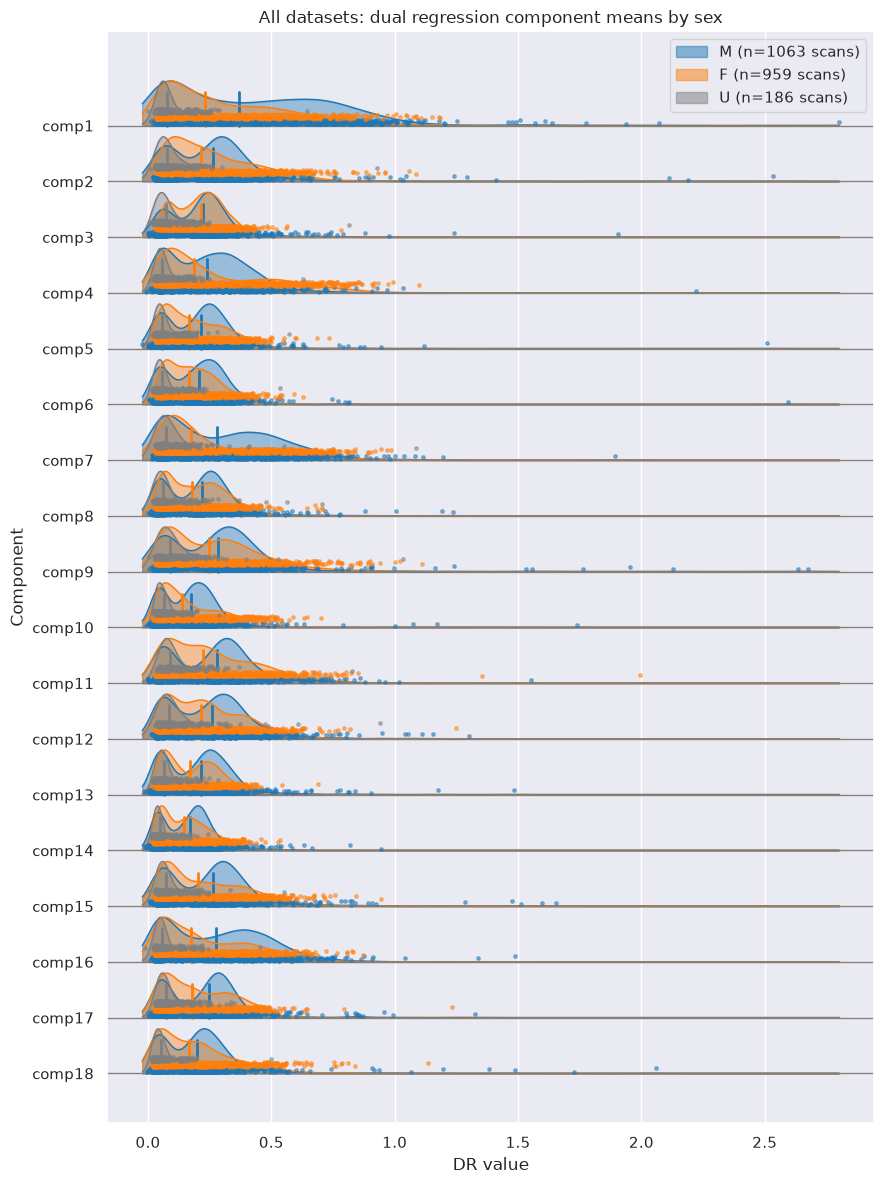

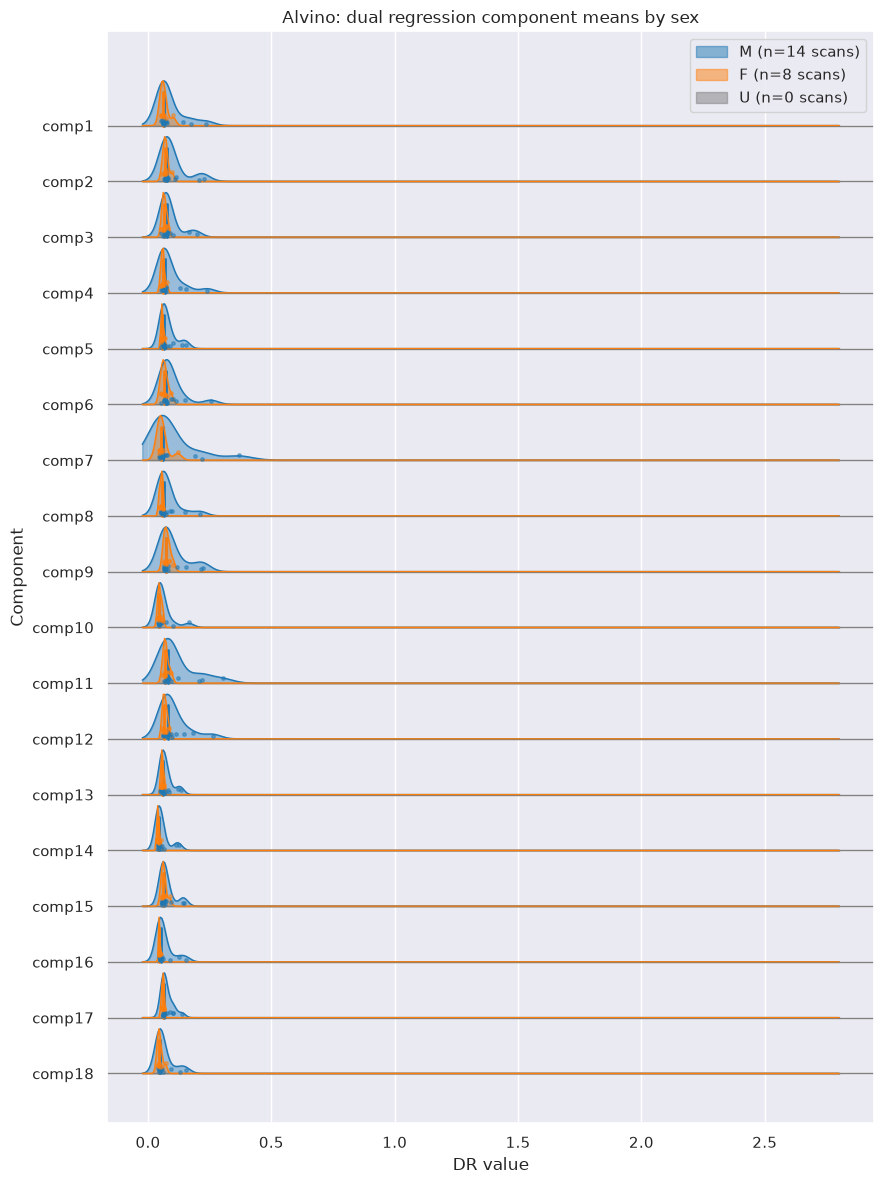

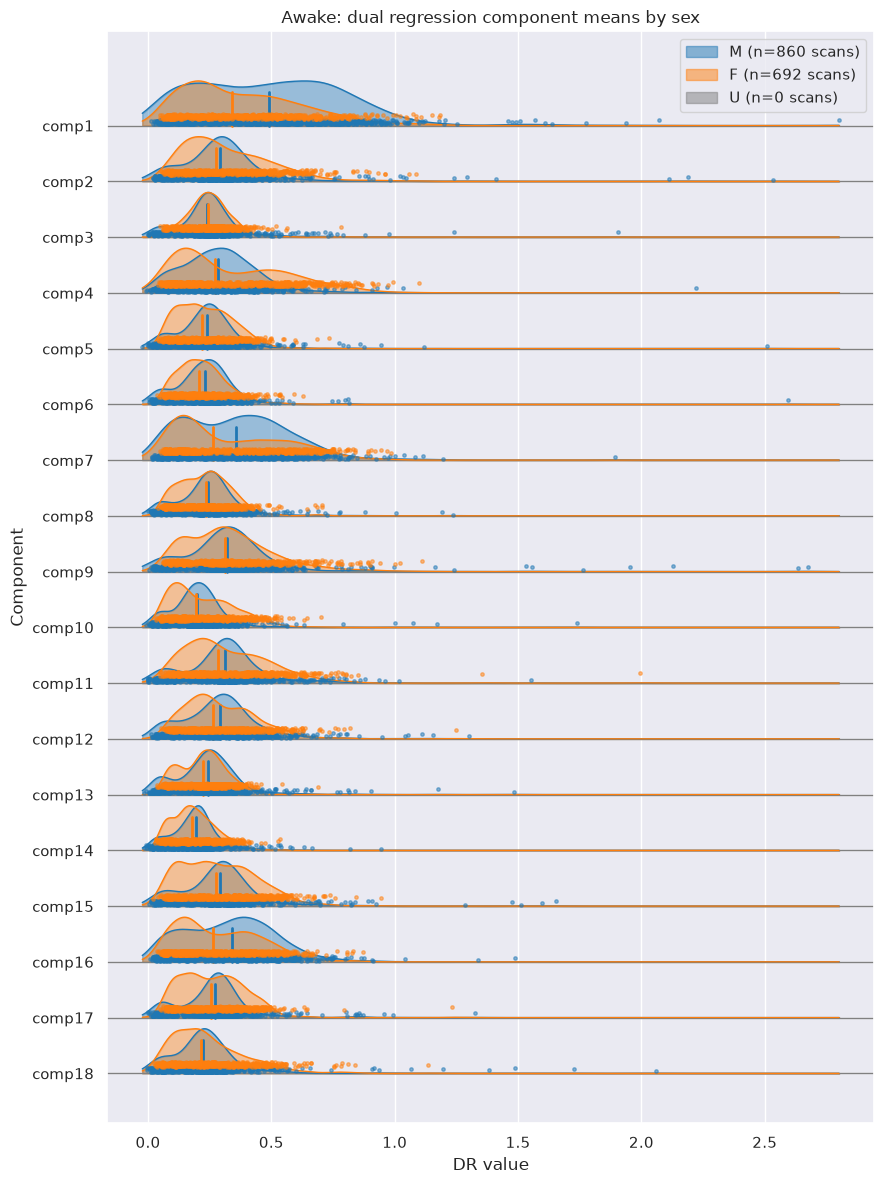

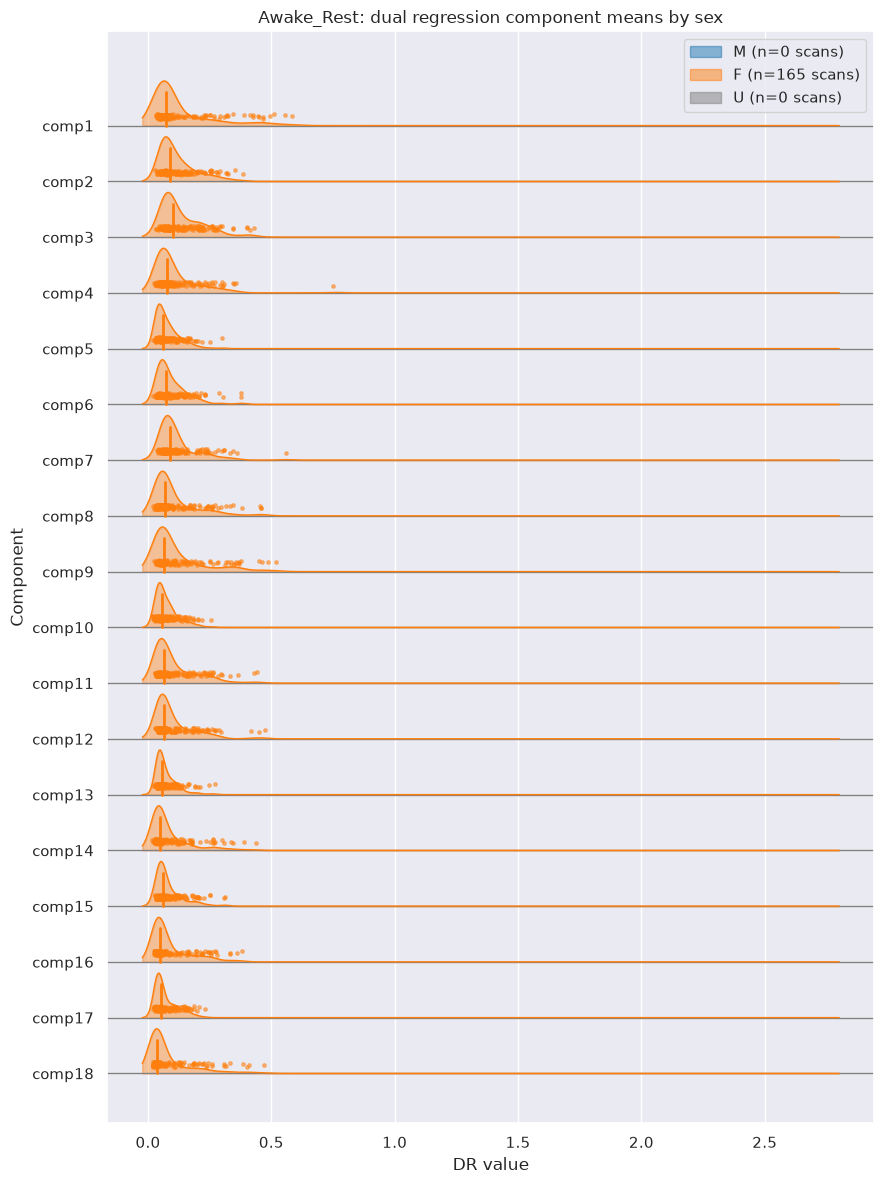

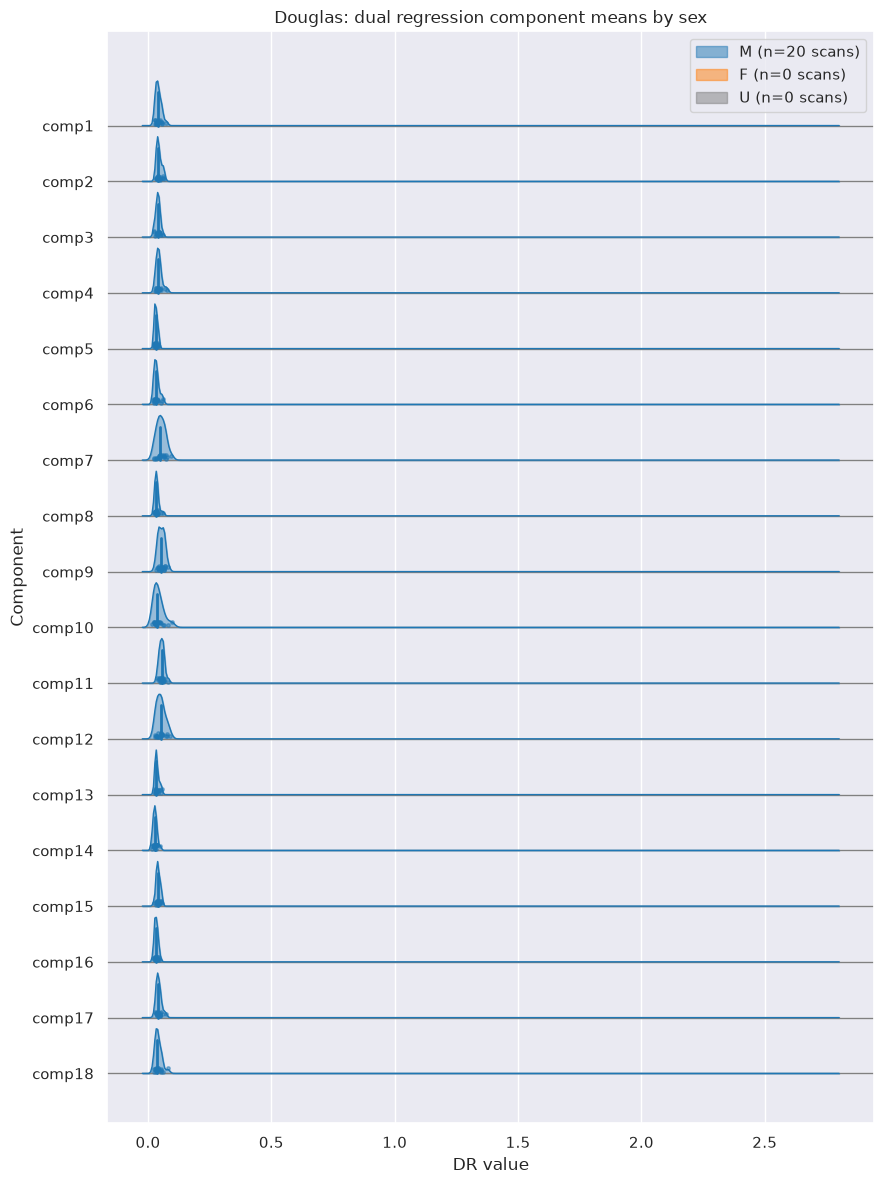

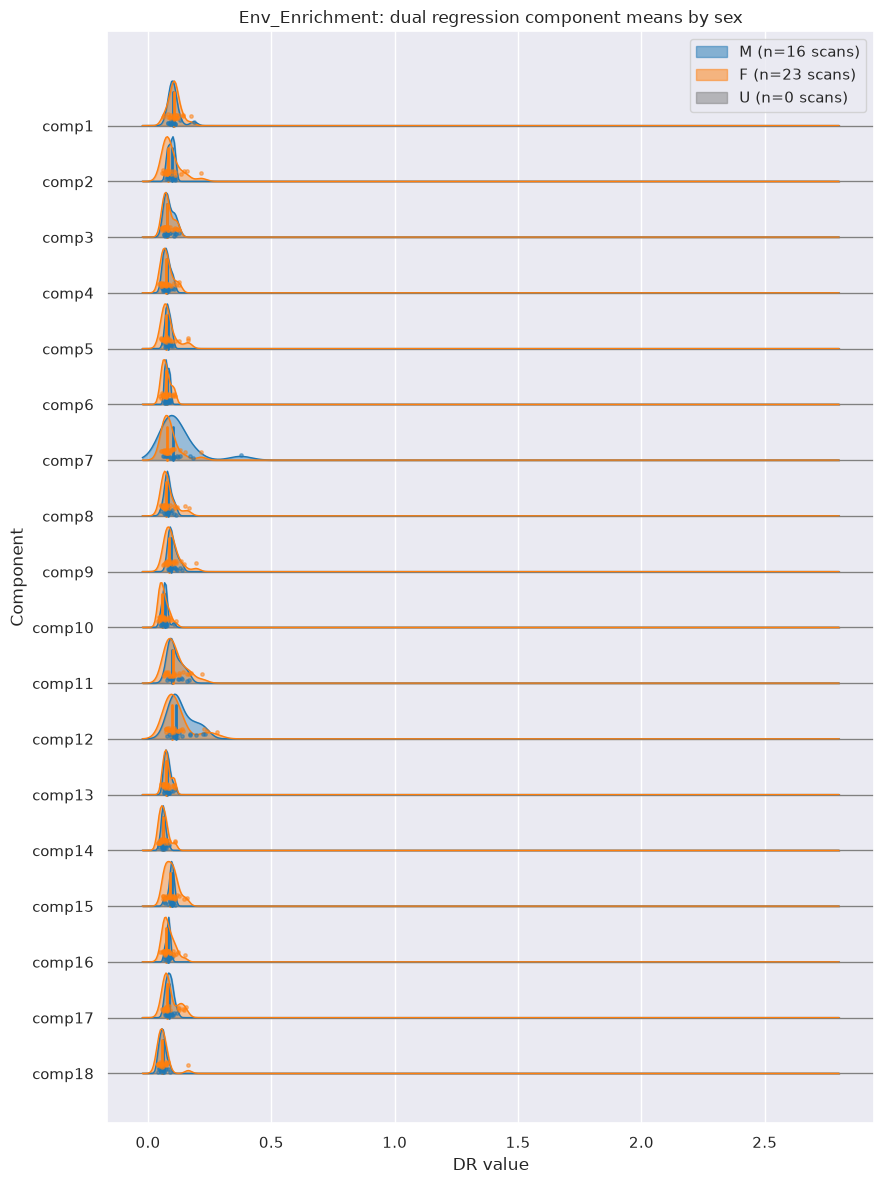

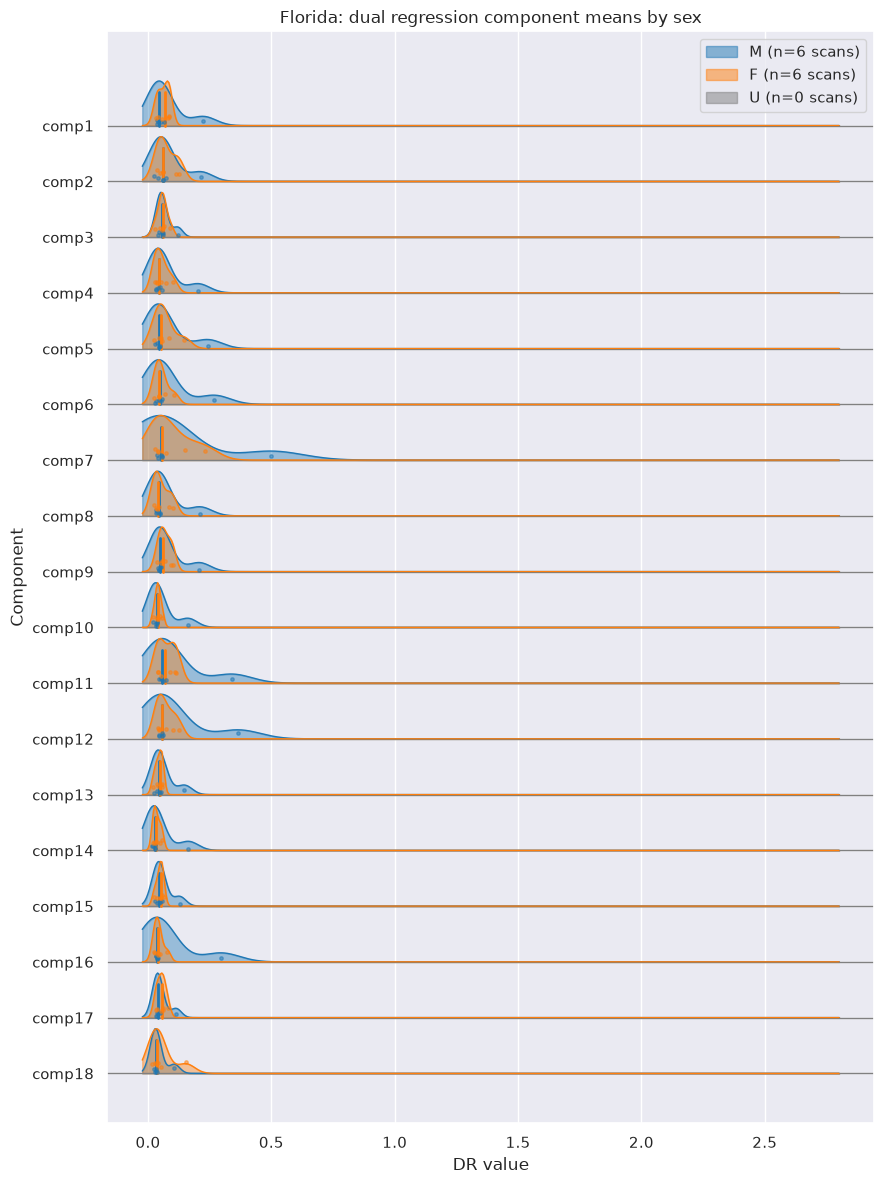

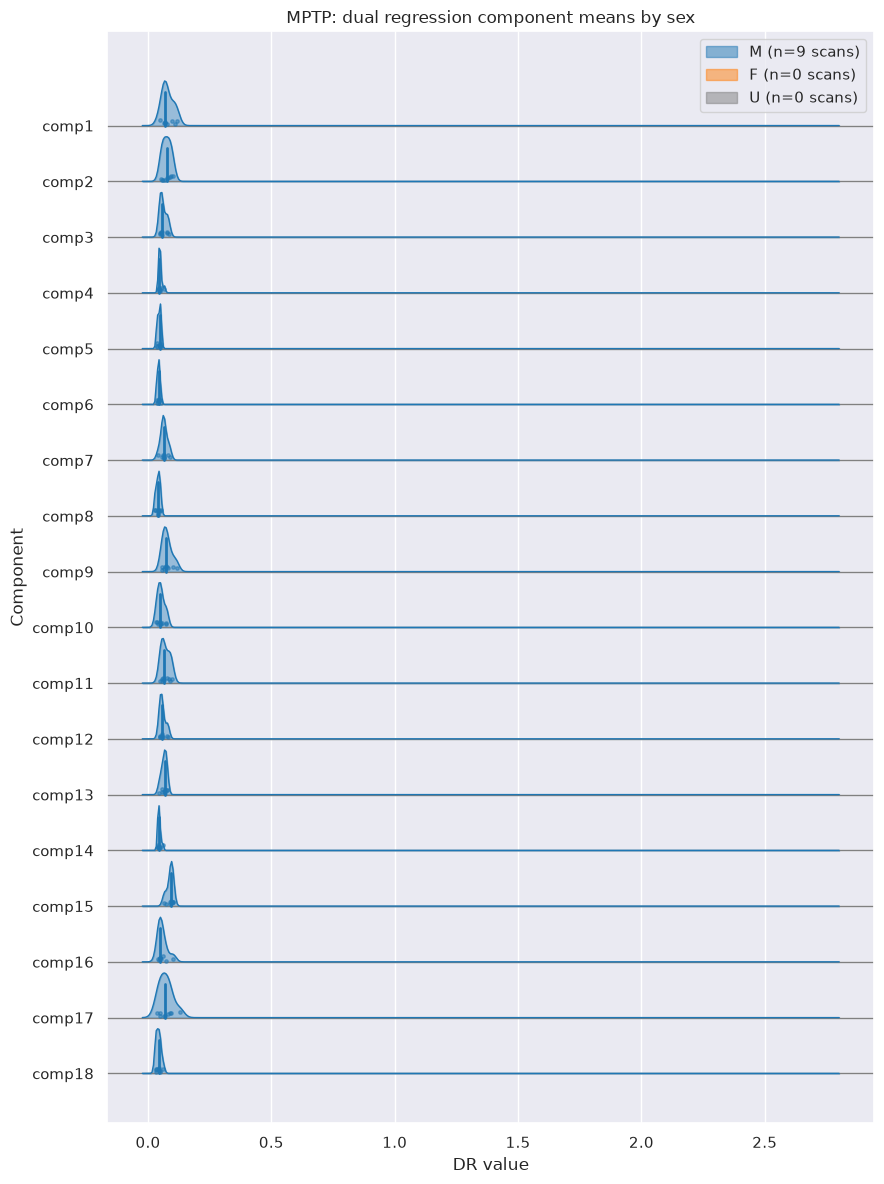

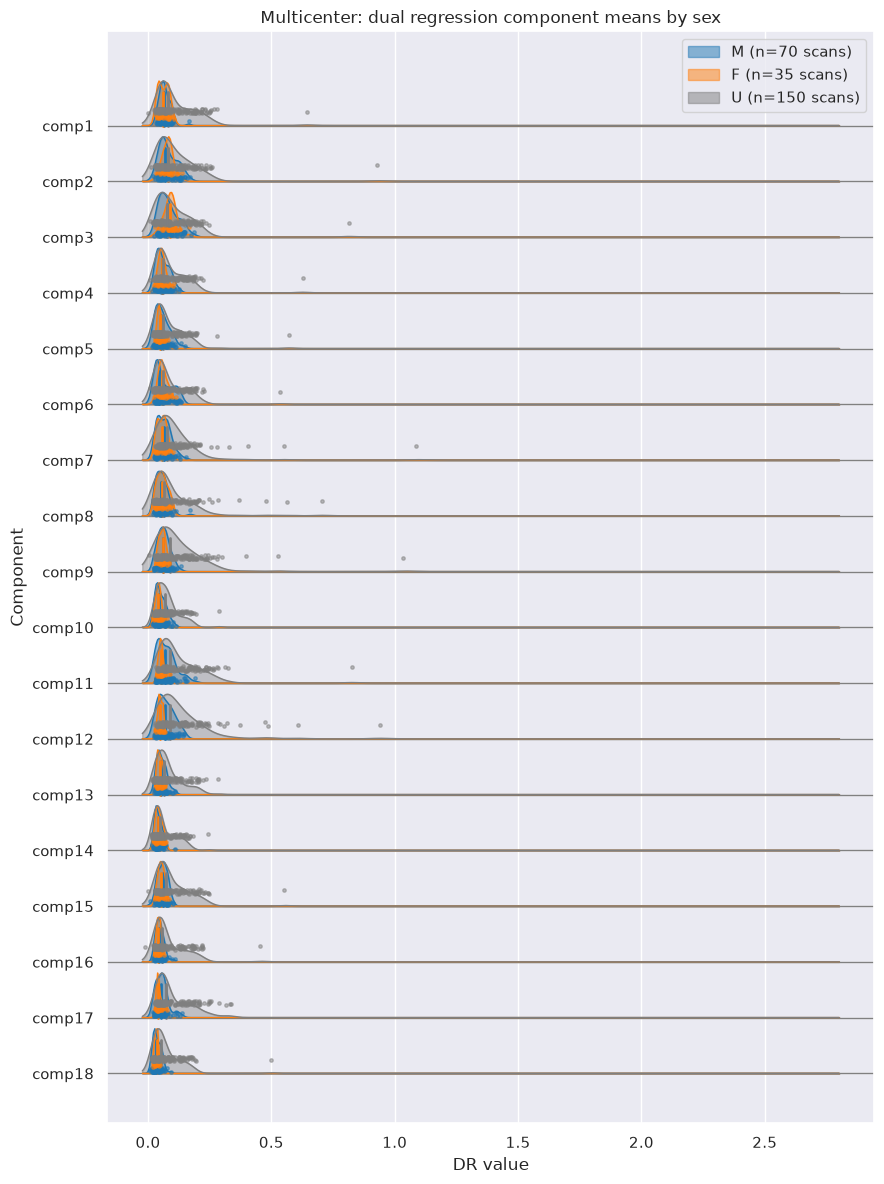

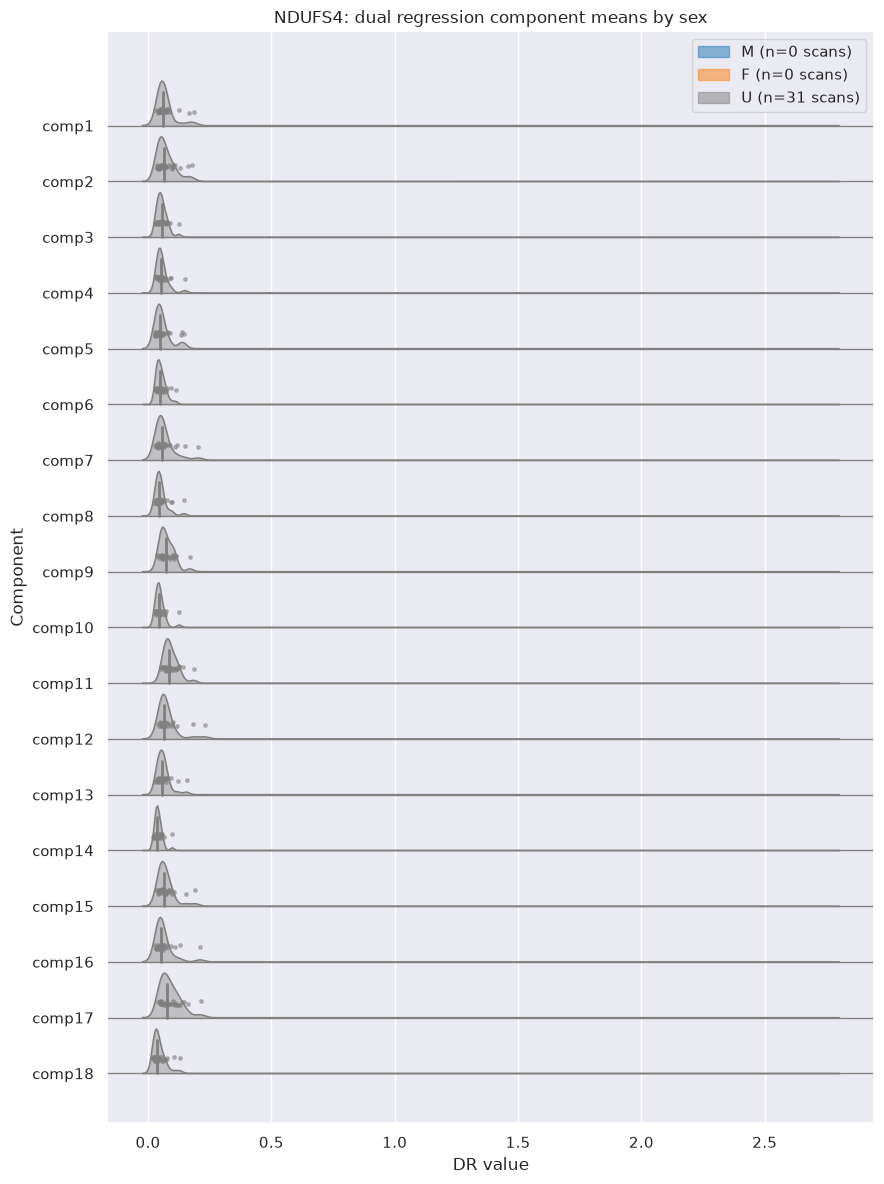

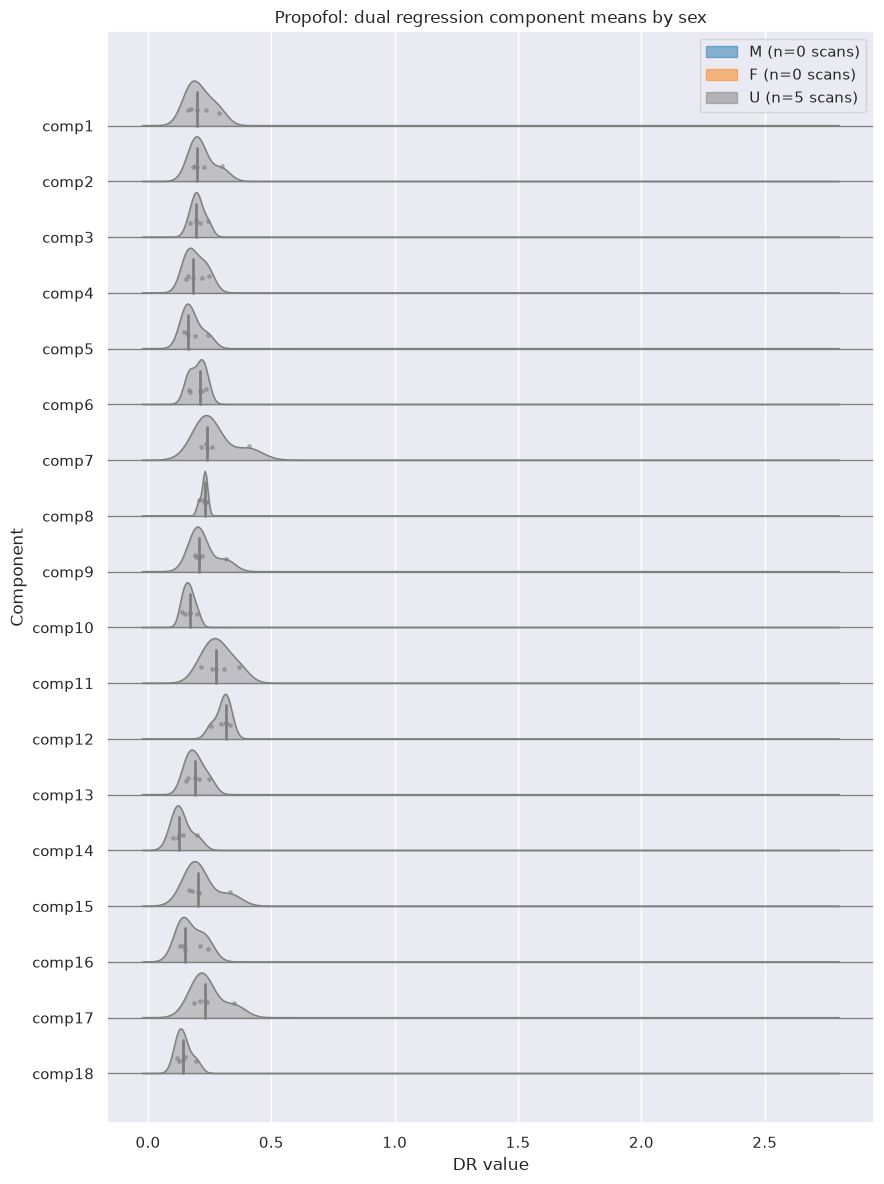

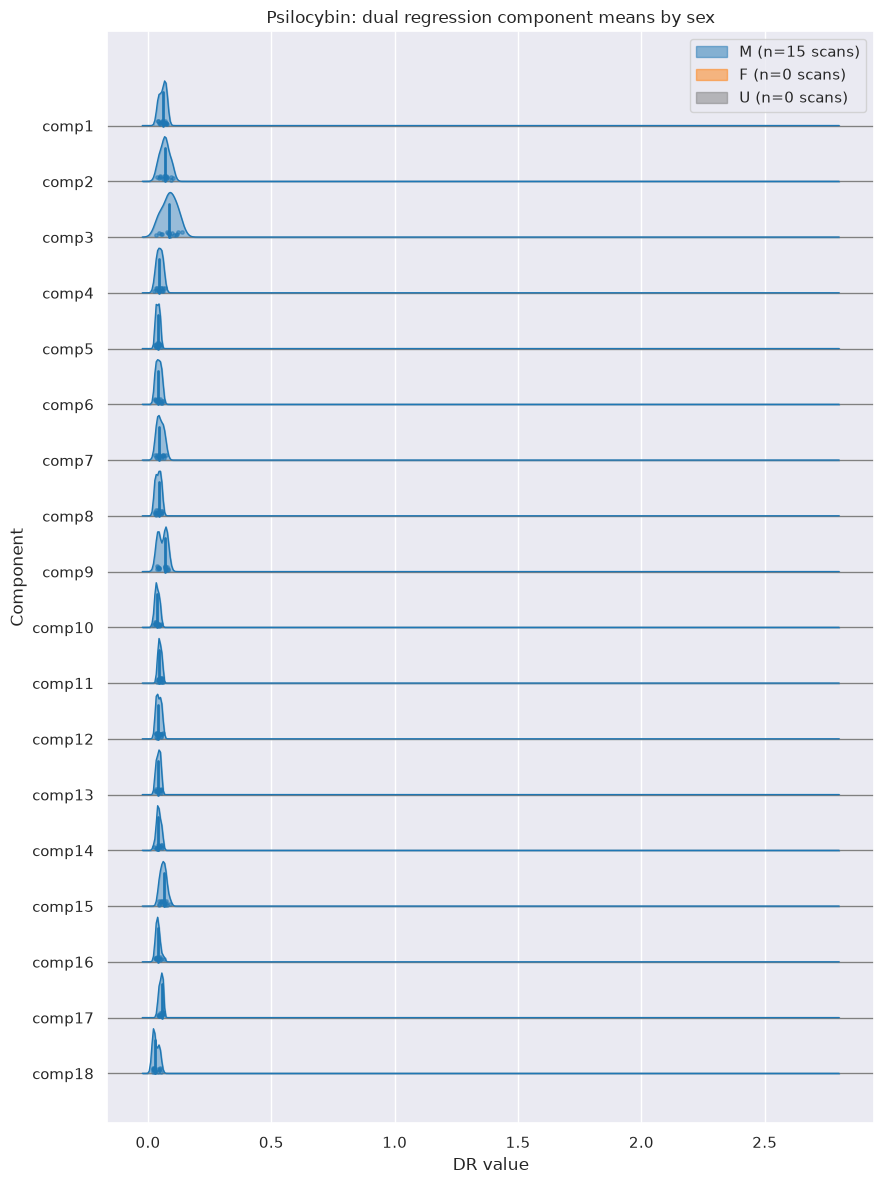

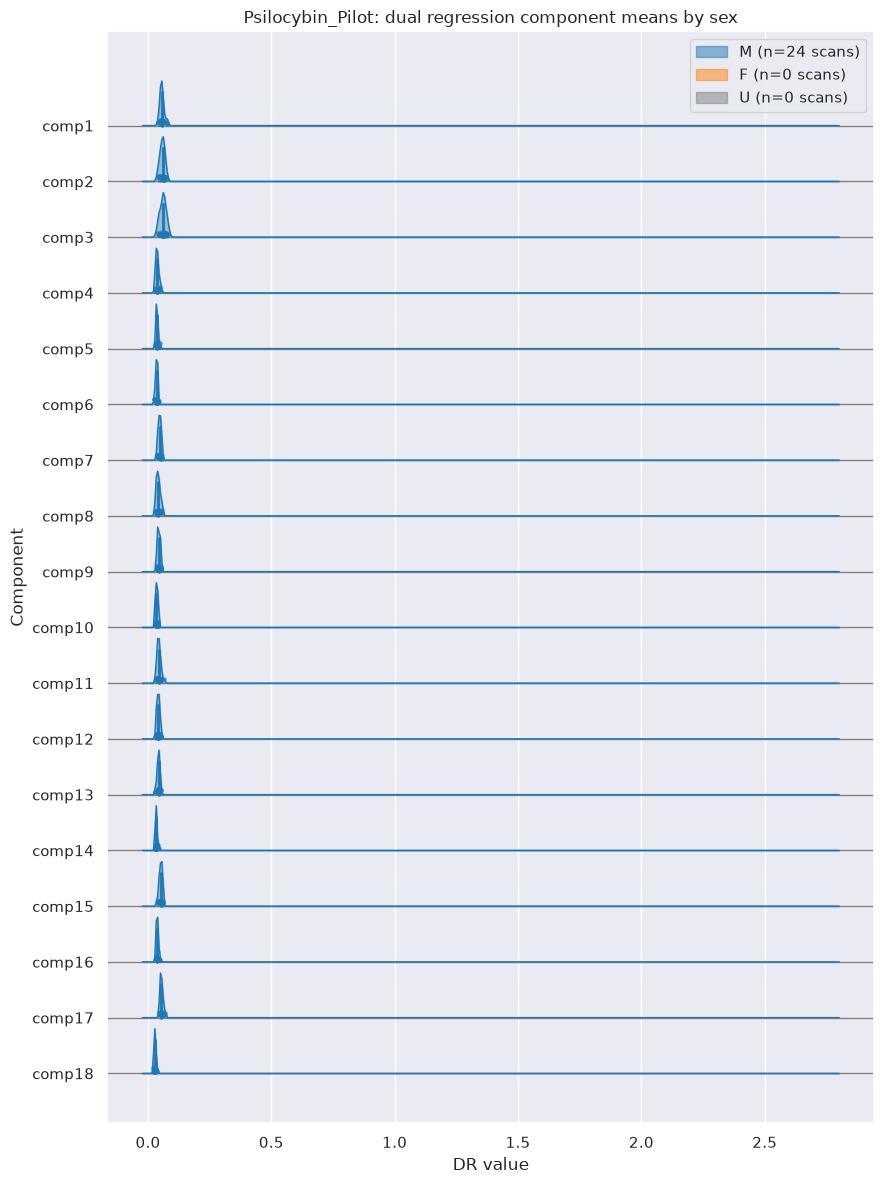

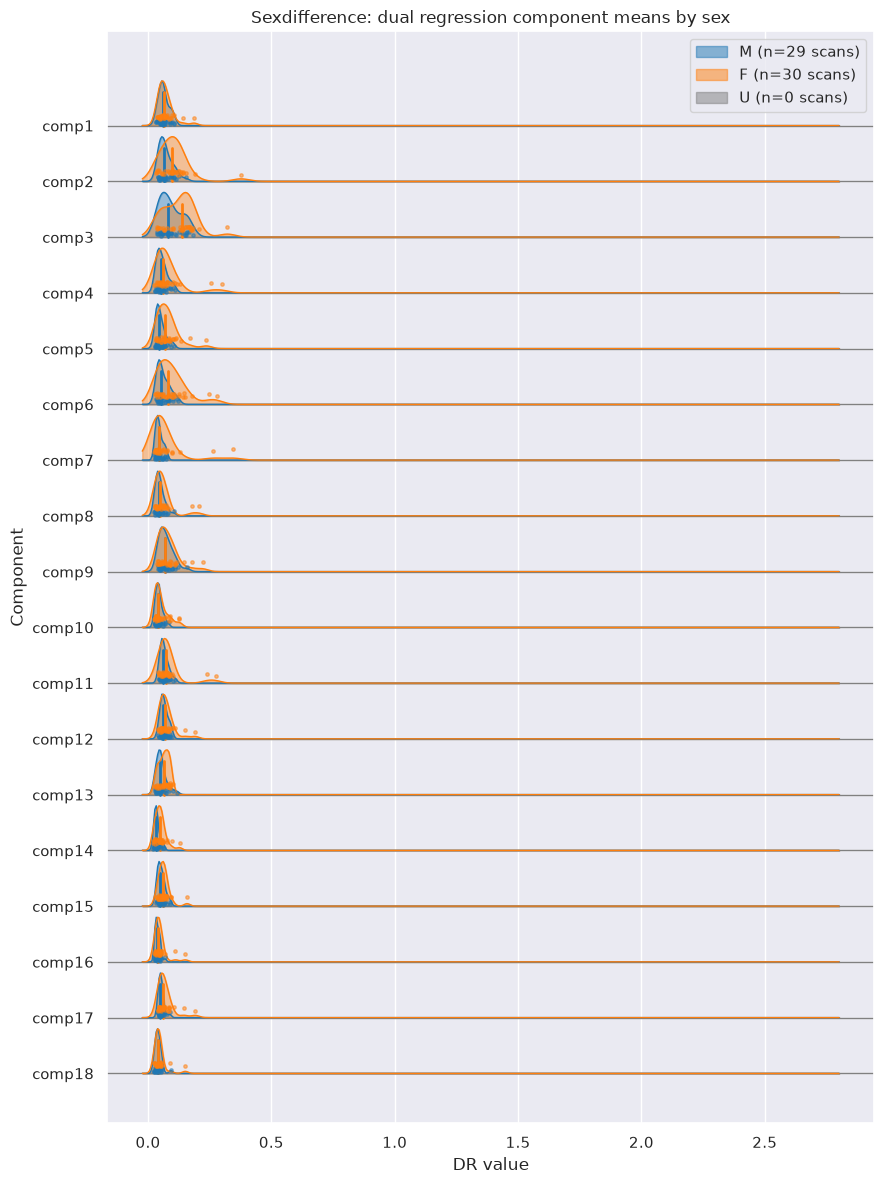

In [4]:
# Ridge plot of all components by sex
sex_colors = {"M": "tab:blue", "F": "tab:orange", "U": "tab:gray"}

# Same x range for every figure, so the datasets are directly comparable
x_grid = np.linspace(df[comp_cols].min().min(), df[comp_cols].max().max(), 500)

def ridge_plot(data, title):
    fig, ax = plt.subplots(figsize=(9, 12))
    rng = np.random.default_rng(0)

    for i, comp in enumerate(comp_cols[::-1]):  # comp1 at the top
        ax.axhline(i, color="grey", lw=1)

        for j, (sex, color) in enumerate(sex_colors.items()):
            values = data.loc[data["Sex"] == sex, comp].values
            if len(values) == 0:
                continue

            # KDE needs at least 2 points that are not all identical
            if len(values) > 1 and np.std(values) > 0:
                kde = gaussian_kde(values)(x_grid)
                kde = kde / kde.max() * 0.8
                ax.fill_between(x_grid, i, i + kde, color=color, alpha=0.4)
                ax.plot(x_grid, i + kde, color=color, lw=1)

            # Points: M slightly lower, F slightly higher, so they don't overlap
            jitter = rng.uniform(0.02, 0.1, size=len(values)) + j * 0.1
            ax.scatter(values, i + jitter, s=6, color=color, alpha=0.5, zorder=3)

            # Median per sex
            med = np.median(values)
            ax.plot([med, med], [i, i + 0.6], color=color, lw=2)

    ax.set_yticks(range(len(comp_cols)))
    ax.set_yticklabels(comp_cols[::-1])
    ax.set_xlabel("DR value")
    ax.set_ylabel("Component")
    ax.set_title(title)

    n_per_sex = data["Sex"].value_counts()
    ax.legend(
        handles=[plt.Rectangle((0, 0), 1, 1, color=c, alpha=0.5) for c in sex_colors.values()],
        labels=[f"{s} (n={n_per_sex.get(s, 0)} scans)" for s in sex_colors],
    )
    plt.tight_layout()
    plt.show()

# All datasets together
ridge_plot(df, "All datasets: dual regression component means by sex")

# One figure per dataset
for name in df["dataset"].unique():
    ridge_plot(df[df["dataset"] == name], f"{name}: dual regression component means by sex")

Train: 1794 scans, 565 mice
Test:  414 scans, 142 mice
Overlap: set()


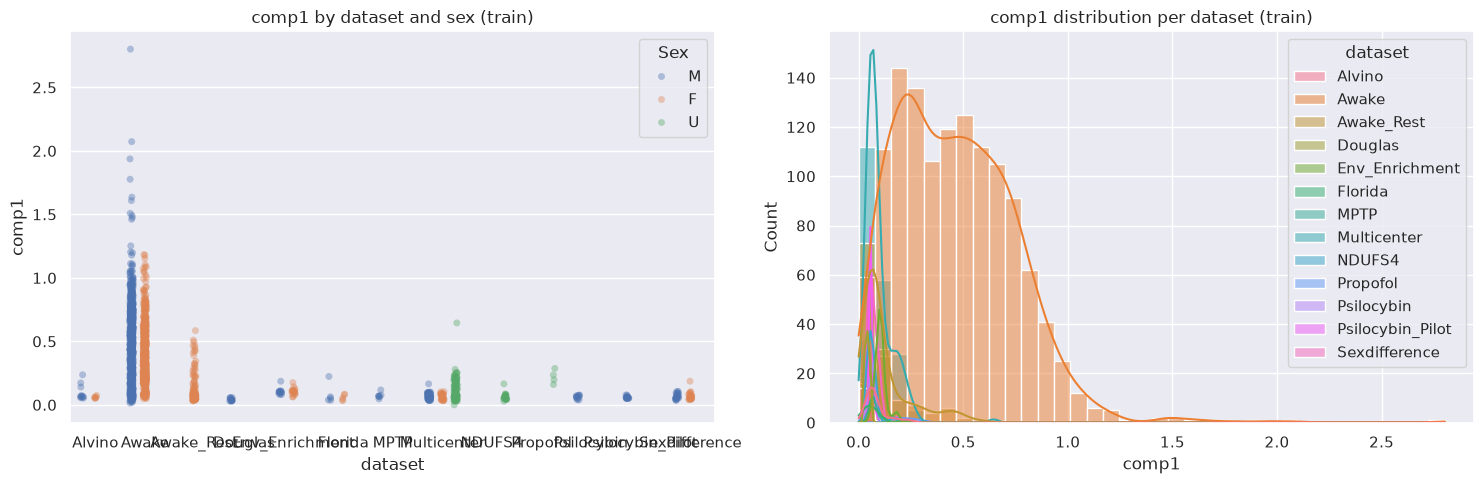

In [5]:
# Split train/test by mouse, stratified by dataset and sex
rng = np.random.default_rng(42)  # fixed seed
test_frac = 0.2

test_mice = []
for _, group in mice.drop_duplicates("mouse_id").groupby(["dataset", "Sex"]):
    ids = group["mouse_id"].values
    n_test = int(round(test_frac * len(ids)))
    test_mice.extend(rng.choice(ids, size=n_test, replace=False))

is_test = df["mouse_id"].isin(test_mice)
train_df = df[~is_test].copy()
test_df = df[is_test].copy()

print("Train:", len(train_df), "scans,", train_df["mouse_id"].nunique(), "mice")
print("Test: ", len(test_df), "scans,", test_df["mouse_id"].nunique(), "mice")
print("Overlap:", set(train_df["mouse_id"]) & set(test_df["mouse_id"]))


# NormData
covariates = dummy_cols
batch_effects = ["dataset"]
feature_to_model = comp_cols  

train = NormData.from_dataframe(
    name="train",
    dataframe=train_df,
    covariates=covariates,
    batch_effects=batch_effects,
    response_vars=feature_to_model,
    remove_Nan=False,
)
test = NormData.from_dataframe(
    name="test",
    dataframe=test_df,
    covariates=covariates,
    batch_effects=batch_effects,
    response_vars=feature_to_model,
    remove_Nan=False,
)

# Visualize one component as a check
feature_to_plot = feature_to_model[0]
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

sns.stripplot(data=train_df, x="dataset", y=feature_to_plot, hue="Sex", dodge=True, alpha=0.4, ax=ax[0])
ax[0].set_title(f"{feature_to_plot} by dataset and sex (train)")

sns.histplot(data=train_df, x=feature_to_plot, hue="dataset", kde=True, ax=ax[1])
ax[1].set_title(f"{feature_to_plot} distribution per dataset (train)")

plt.tight_layout()
plt.show()

In [6]:
# Initialize and Fit Normative Model: HBR with SHASH likelihood
# Mean: Mean: linear in the covariates, intercept varies per dataset
mu = make_prior(
    linear=True,
    slope=make_prior(dist_name="Normal", dist_params=(0.0, 10.0)),
    intercept=make_prior(
        random=True,
        mu=make_prior(dist_name="Normal", dist_params=(0.0, 1.0)),
        sigma=make_prior(dist_name="Normal", dist_params=(0.0, 1.0), mapping="softplus", mapping_params=(0.0, 3.0)),
    ),
)

# Spread: linear in the covariates, intercept varies per dataset
sigma = make_prior(
    linear=True,
    slope=make_prior(dist_name="Normal", dist_params=(0.0, 2.0)),
    intercept=make_prior(
        random=True,
        mu=make_prior(dist_name="Normal", dist_params=(1.0, 1.0)),
        sigma=make_prior(dist_name="Normal", dist_params=(0.0, 1.0), mapping="softplus", mapping_params=(0.0, 3.0)),
    ),
    mapping="softplus",
    mapping_params=(0.0, 3.0),
)

# Skewness and tail heaviness
epsilon = make_prior(dist_name="Normal", dist_params=(0.0, 1.0))
delta = make_prior(dist_name="Normal", dist_params=(1.0, 1.0), mapping="softplus", mapping_params=(0.0, 3.0, 0.6))

model = NormativeModel(
    HBR(
        name="hbr_shashb",
        likelihood=SHASHbLikelihood(mu, sigma, epsilon, delta),
        draws=500,  # 1500 for the final run
        tune=500,
        chains=4,
        cores=4,
        progressbar=True,
    ),
    inscaler="standardize",
    outscaler="standardize",
)

model.fit_predict(train, test)

Progress,Draws,Divergences,Step Size,Gradients/Draw
,1000,0,0.05,127
,1000,0,0.05,511
,1000,1,0.05,639
,1000,0,0.07,255


Progress,Draws,Divergences,Step Size,Gradients/Draw
,1000,0,0.09,511
,1000,0,0.09,255
,1000,0,0.09,191
,1000,0,0.09,319


Progress,Draws,Divergences,Step Size,Gradients/Draw
,1000,0,0.13,255
,1000,0,0.12,383
,1000,0,0.11,63
,1000,0,0.11,127


Progress,Draws,Divergences,Step Size,Gradients/Draw
,1000,0,0.06,63
,1000,0,0.05,511
,1000,0,0.06,1023
,1000,0,0.06,127


Progress,Draws,Divergences,Step Size,Gradients/Draw
,1000,0,0.06,511
,1000,0,0.07,255
,1000,0,0.07,319
,1000,0,0.08,1023


...

Progress,Draws,Divergences,Step Size,Gradients/Draw
,1000,0,0.06,511
,1000,0,0.06,383
,1000,2,0.06,191
,1000,0,0.06,511


Progress,Draws,Divergences,Step Size,Gradients/Draw
,1000,0,0.08,255
,1000,0,0.08,511
,1000,0,0.07,575
,1000,0,0.07,511


Progress,Draws,Divergences,Step Size,Gradients/Draw
,1000,0,0.05,775
,1000,0,0.05,383
,1000,0,0.05,511
,1000,0,0.05,447


/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()
/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()
/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()
/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decoration

<xarray.NormData> Size: 649kB
Dimensions:            (observations: 414, response_vars: 18, covariates: 5,
                        batch_effect_dims: 1, centile: 5, statistic: 13)
Coordinates:
  * observations       (observations) int64 3kB 0 1 2 3 4 ... 410 411 412 413
  * response_vars      (response_vars) <U6 432B 'comp1' 'comp2' ... 'comp18'
  * covariates         (covariates) <U11 220B 'sex_F' 'sex_U' ... 'seq_unknown'
  * batch_effect_dims  (batch_effect_dims) <U7 28B 'dataset'
  * centile            (centile) float64 40B 0.05 0.25 0.5 0.75 0.95
  * statistic          (statistic) <U8 416B 'EXPV' 'Kurtosis' ... 'Skewness'
Data variables:
    subject_ids        (observations) int64 3kB 0 1 2 3 4 ... 410 411 412 413
    Y                  (observations, response_vars) float64 60kB 0.1028 ... ...
    X                  (observations, covariates) float64 17kB 1.0 0.0 ... 0.0
    batch_effects      (observations, batch_effect_dims) <U16 26kB 'Alvino' ....
    Z                  (observations, response_vars) float64 60kB 1.411 ... 0...
    centiles           (centile, observations, response_vars) float64 298kB 0...
    baseline_logp      (observations, response_vars) float64 60kB -1.006 ... ...
    logp               (observations, response_vars) float64 60kB 0.1204 ... ...
    Yhat               (observations, response_vars) float64 60kB 0.0669 ... ...
    statistics         (response_vars, statistic) float64 2kB 0.4459 ... 0.3995
Attributes:
    real_ids:                       False
    is_scaled:                      False
    name:                           test
    unique_batch_effects:           {np.str_('dataset'): ['Alvino', 'Awake', ...
    batch_effect_counts:            defaultdict(<function NormData.register_b...
    covariate_ranges:               {np.str_('sex_F'): {'min': 0.0, 'max': 1....
    batch_effect_covariate_ranges:  {np.str_('dataset'): {'Alvino': {np.str_(...

In [7]:
#import inspect
#print(inspect.signature(HBR.__init__))

#dir(model);
#print([a for a in dir(model) if not a.startswith("_")])

Evaluation

/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


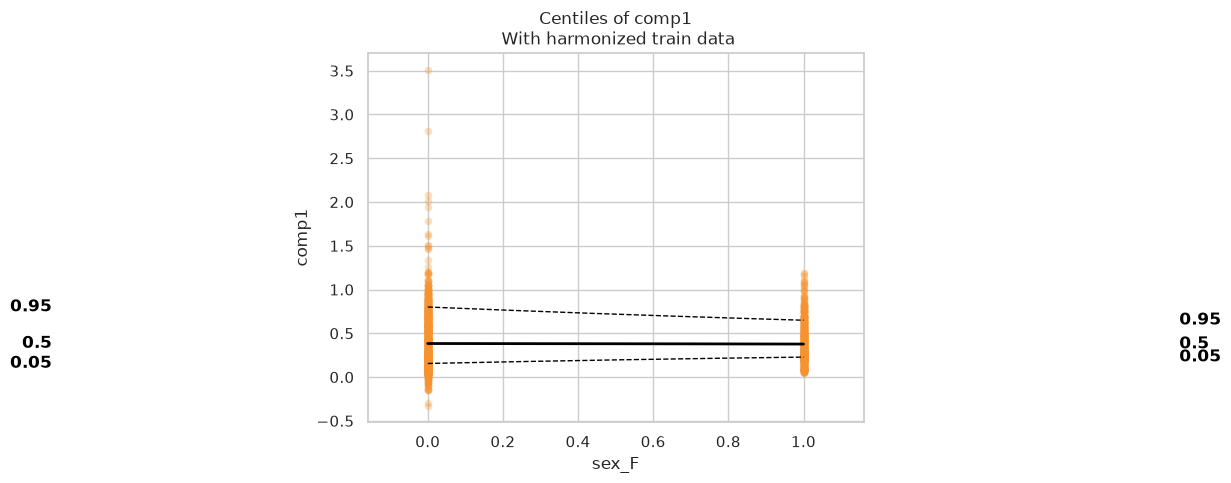

<Figure size 640x480 with 0 Axes>

/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


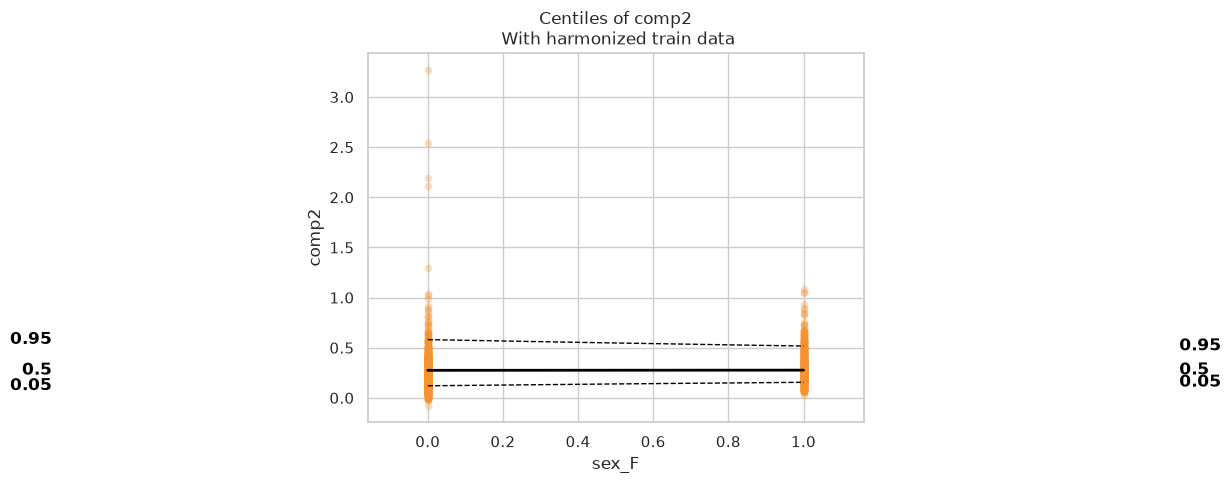

<Figure size 640x480 with 0 Axes>

/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


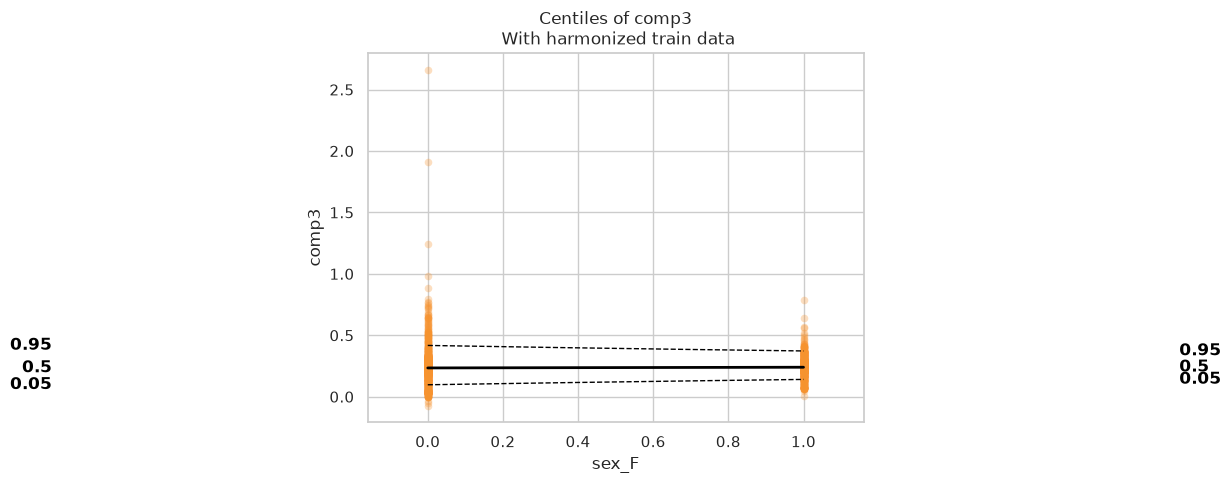

<Figure size 640x480 with 0 Axes>

/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


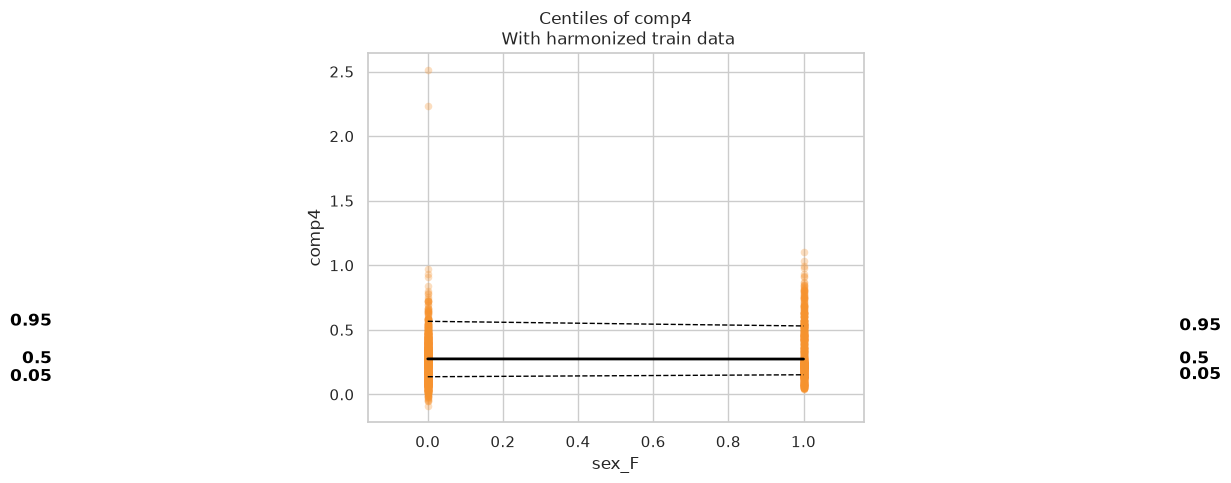

<Figure size 640x480 with 0 Axes>

/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


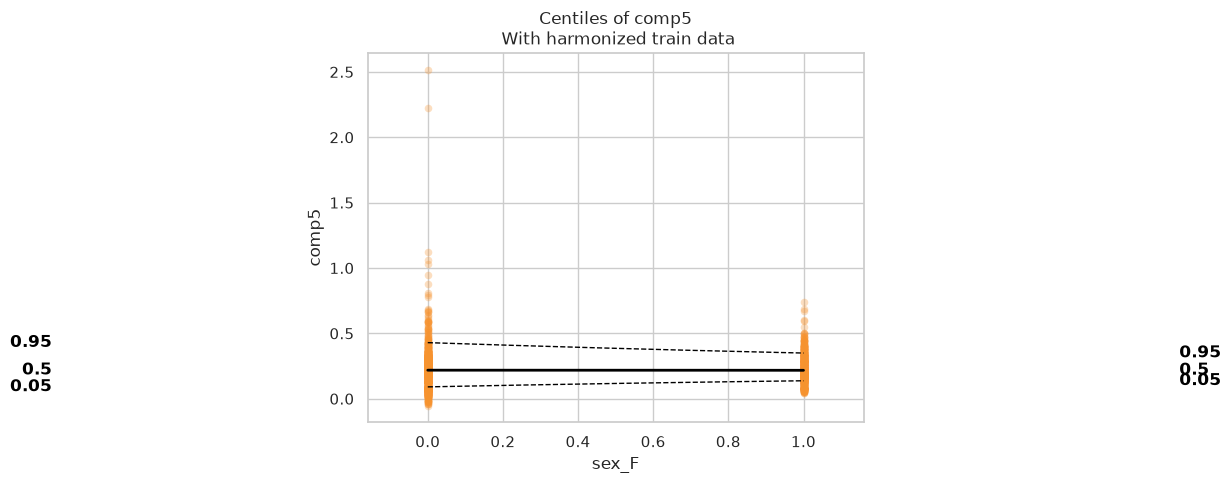

<Figure size 640x480 with 0 Axes>

/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


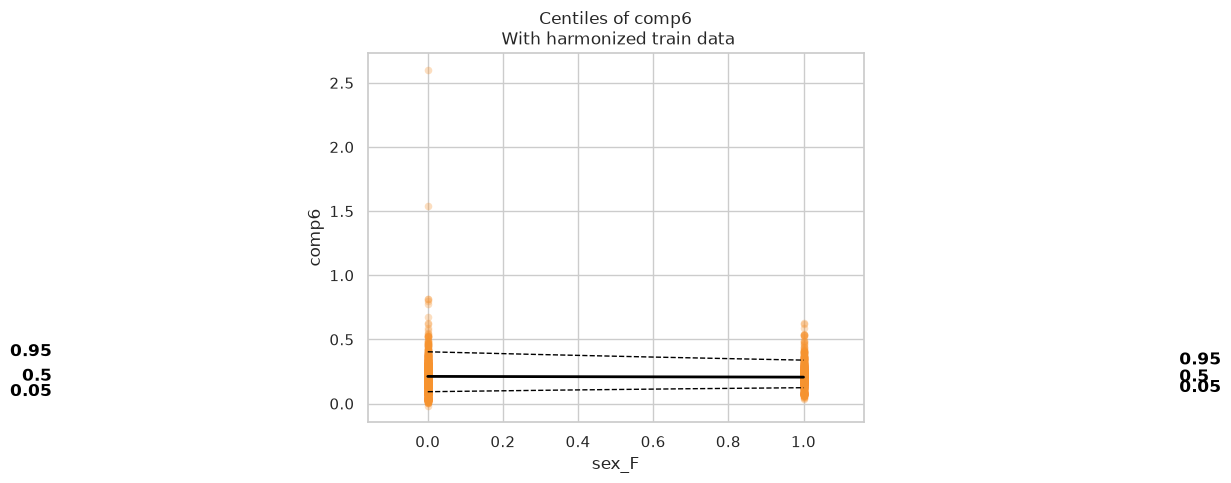

<Figure size 640x480 with 0 Axes>

/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


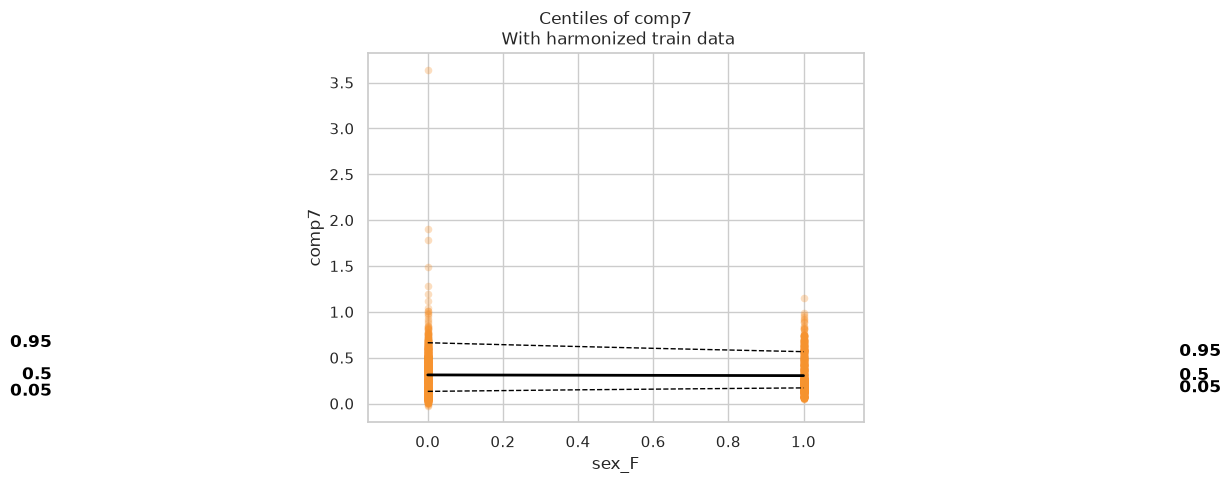

<Figure size 640x480 with 0 Axes>

/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


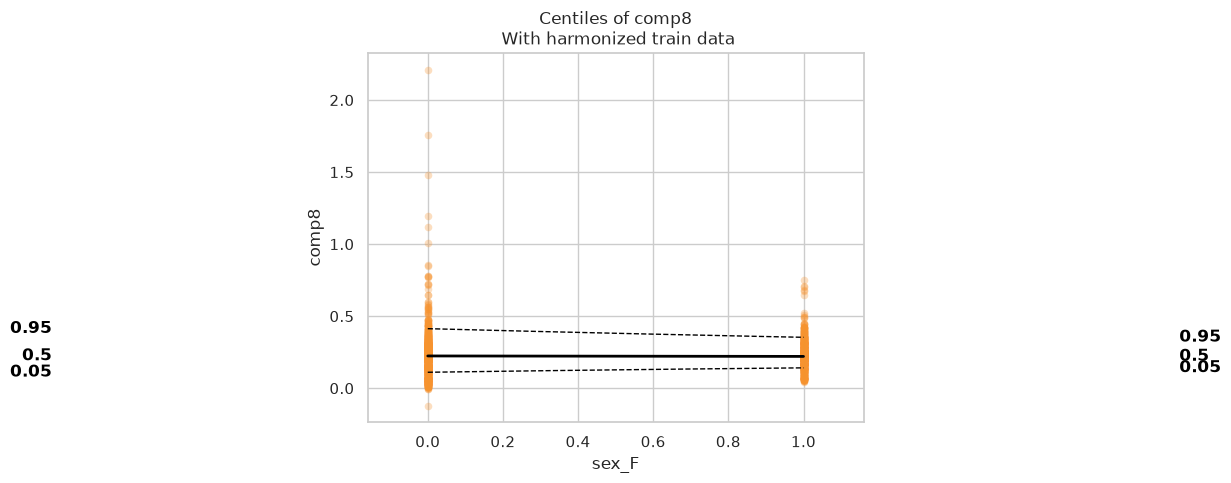

<Figure size 640x480 with 0 Axes>

/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


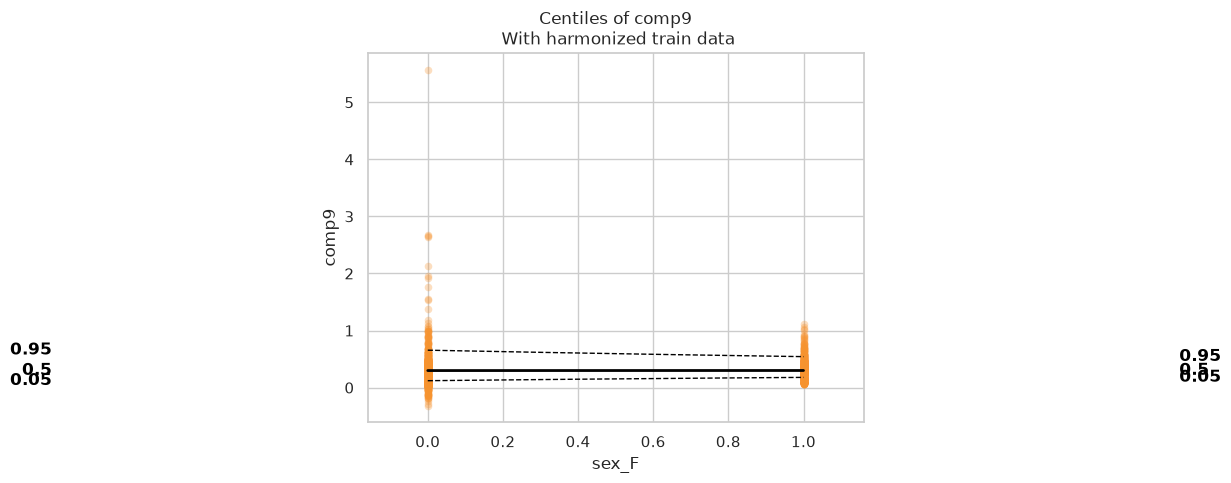

<Figure size 640x480 with 0 Axes>

/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


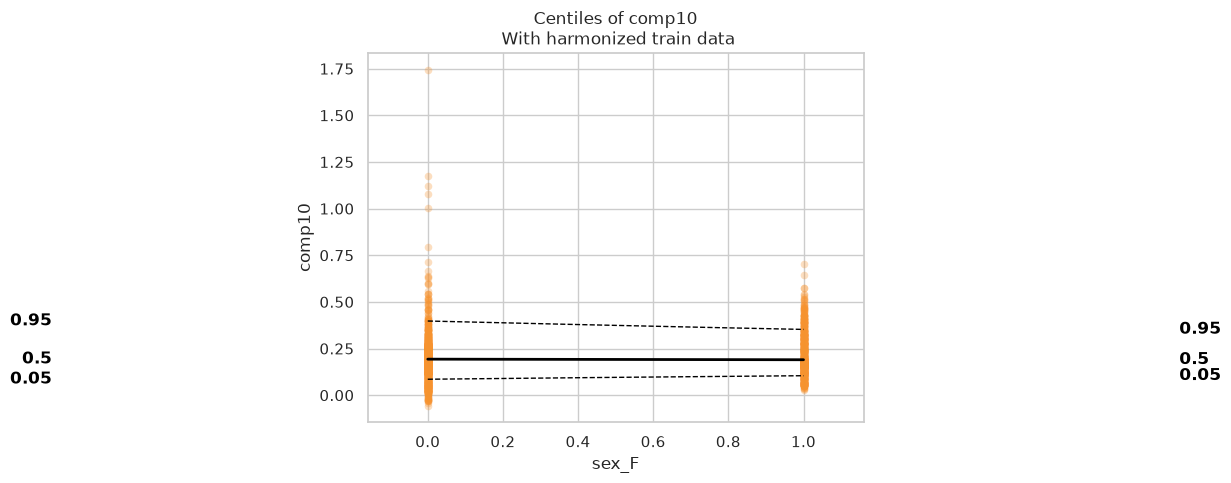

<Figure size 640x480 with 0 Axes>

/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


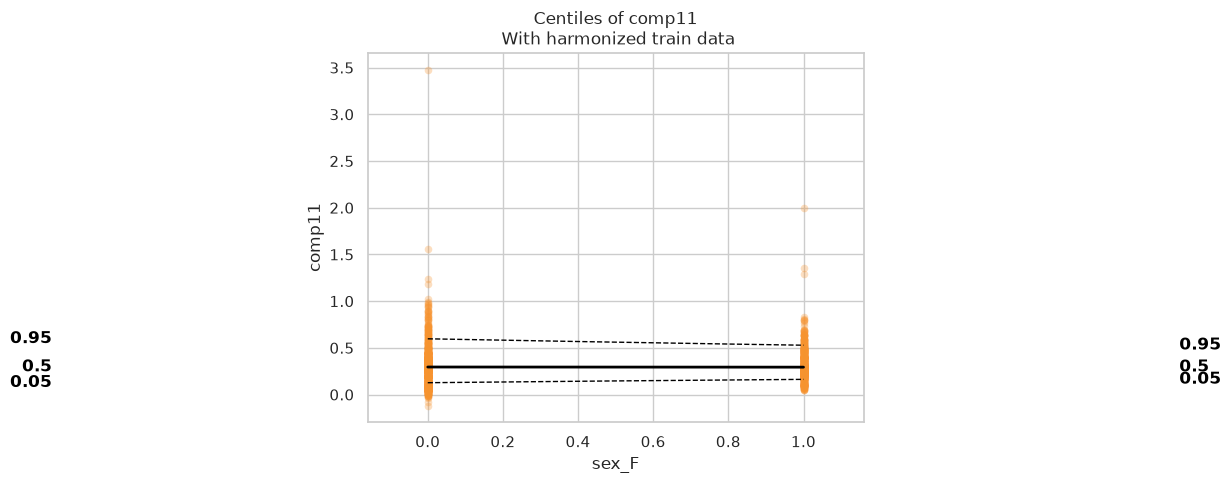

<Figure size 640x480 with 0 Axes>

/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


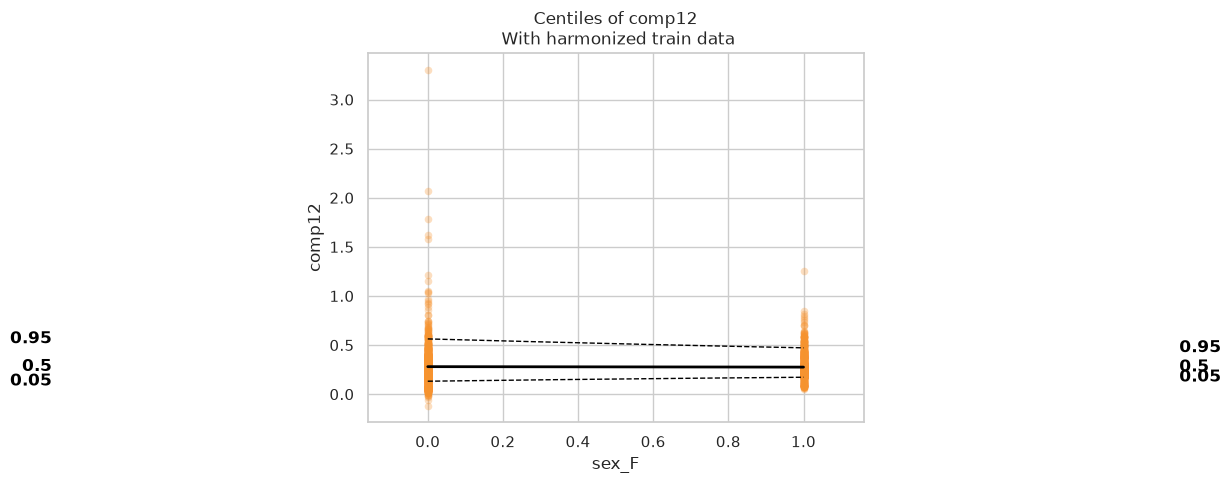

<Figure size 640x480 with 0 Axes>

/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


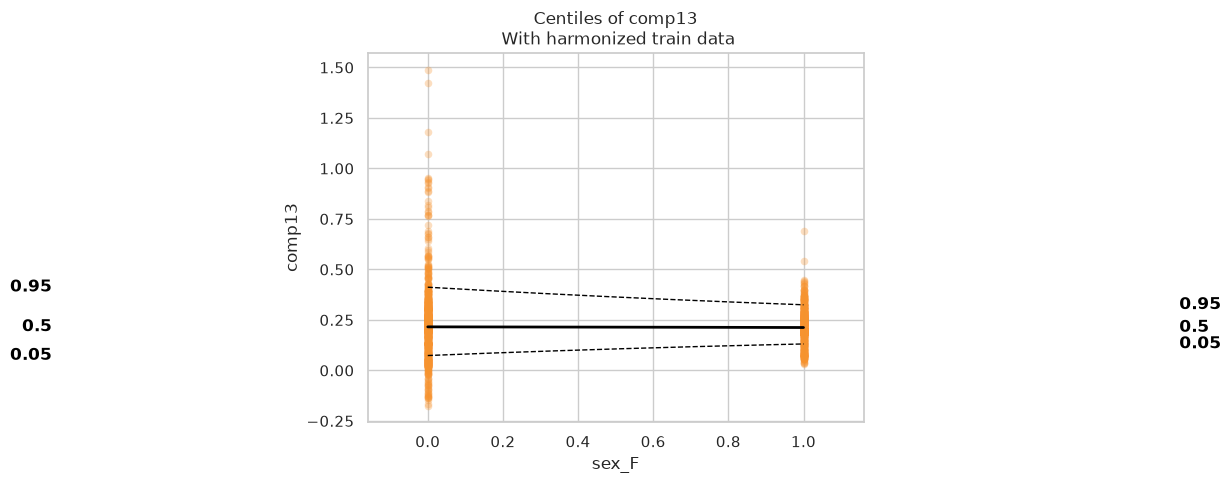

<Figure size 640x480 with 0 Axes>

/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


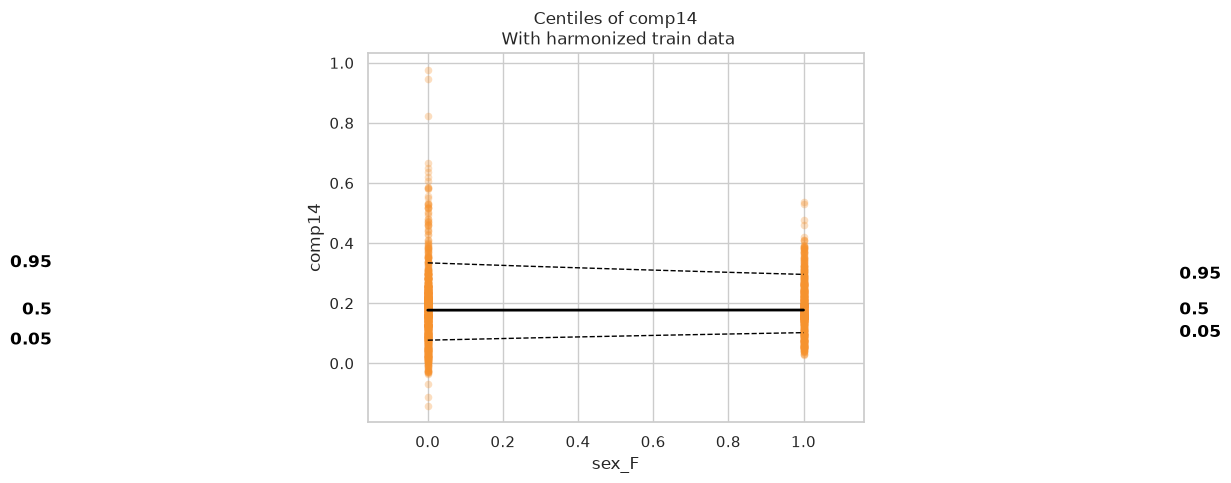

<Figure size 640x480 with 0 Axes>

/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


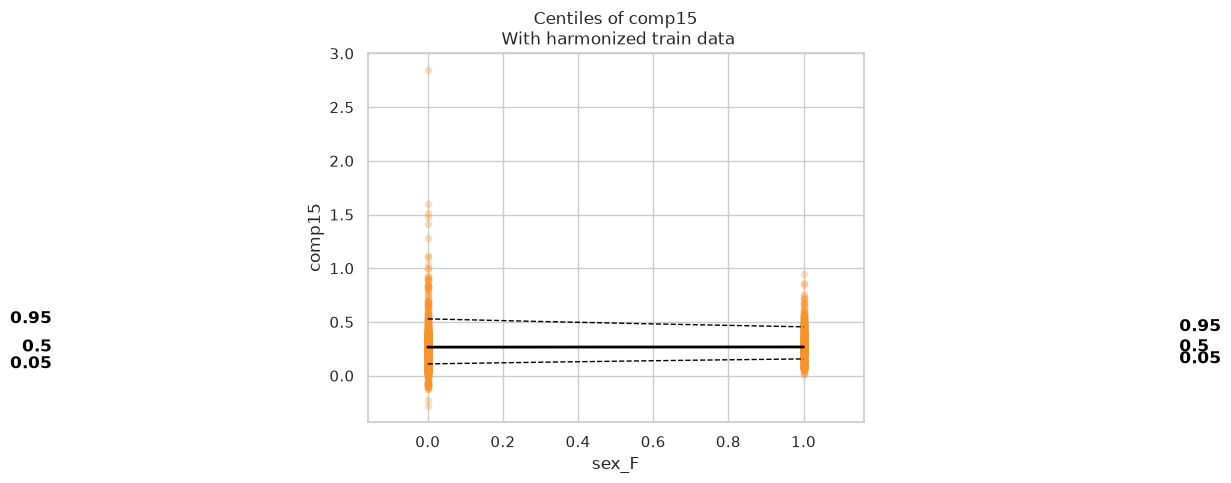

<Figure size 640x480 with 0 Axes>

/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


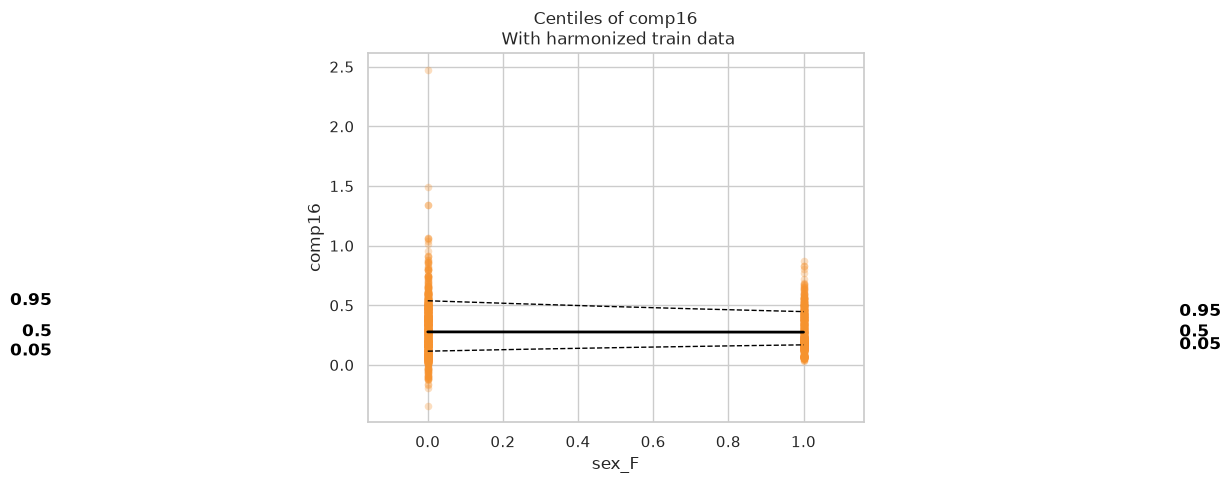

<Figure size 640x480 with 0 Axes>

/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


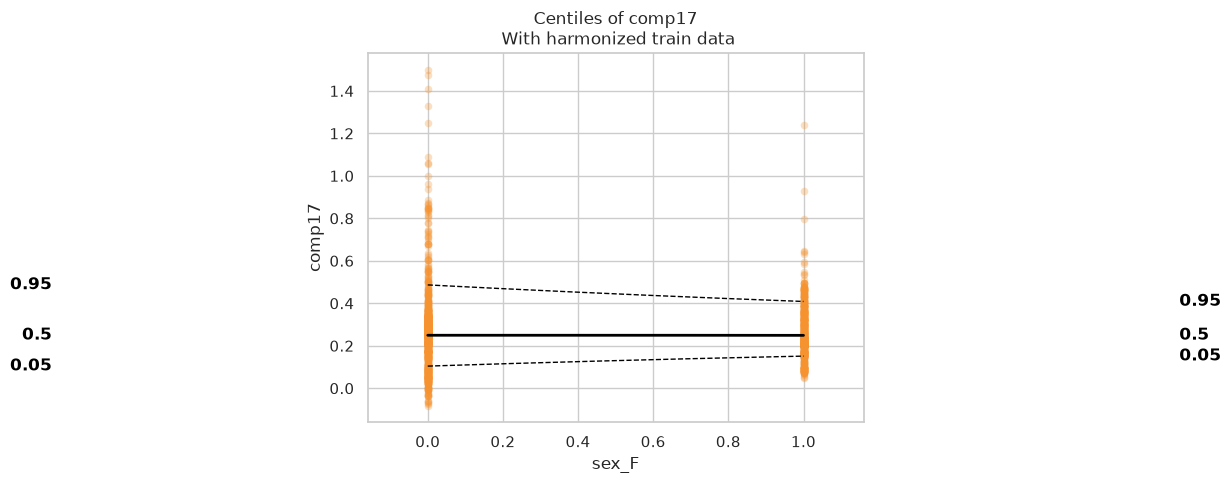

<Figure size 640x480 with 0 Axes>

/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


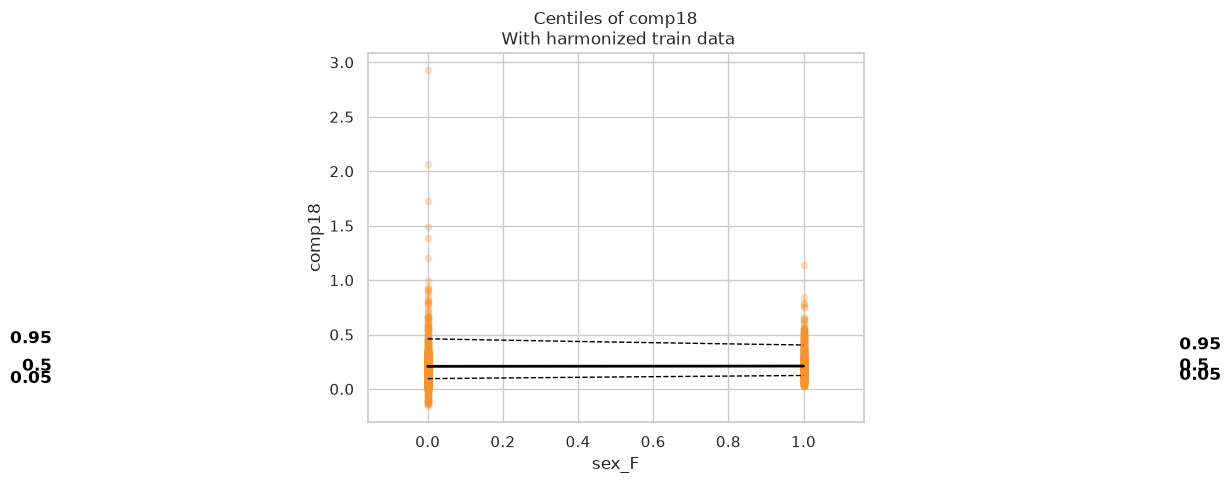

<Figure size 640x480 with 0 Axes>

/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


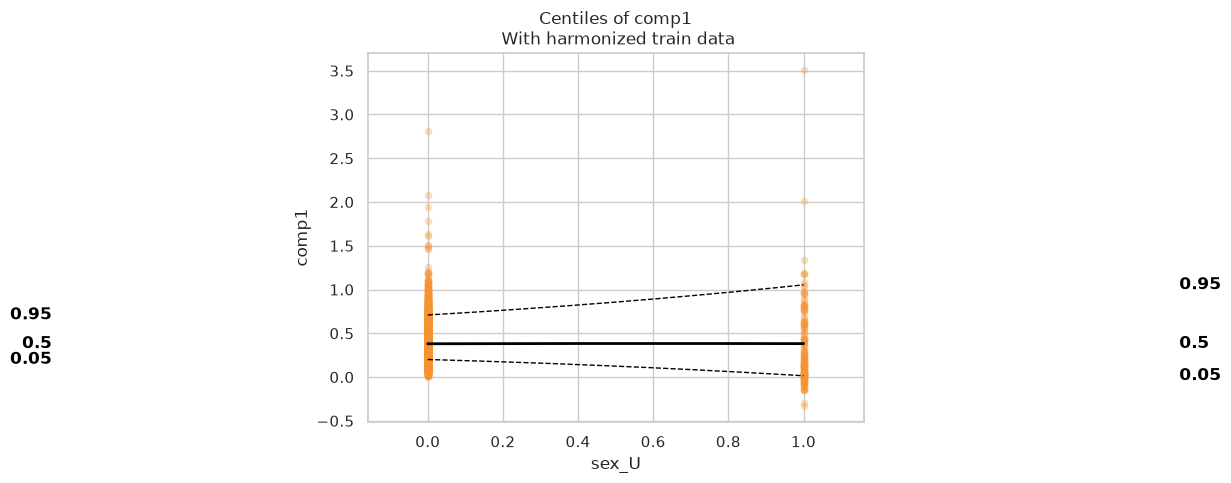

<Figure size 640x480 with 0 Axes>

/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


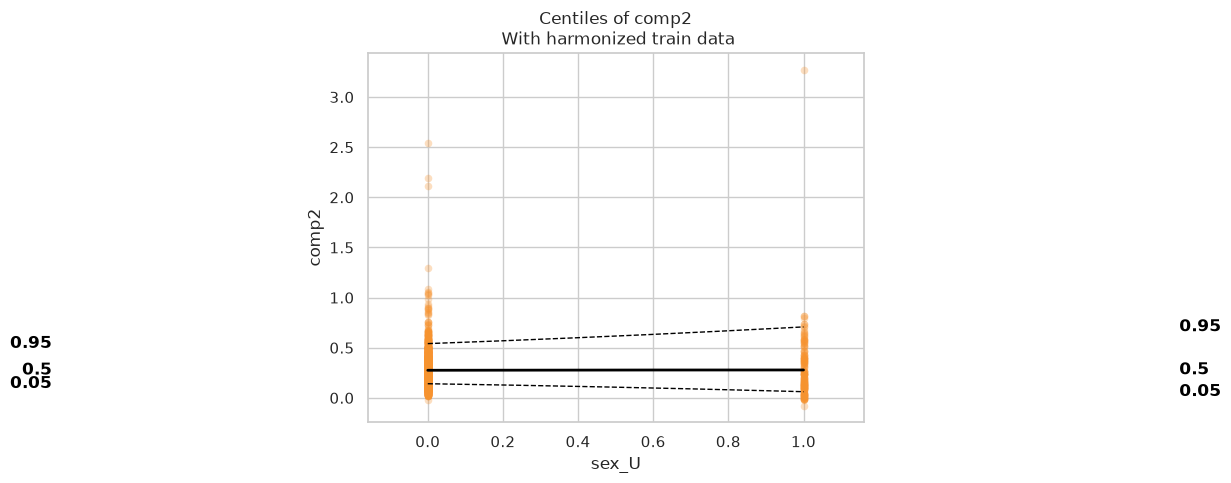

<Figure size 640x480 with 0 Axes>

/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


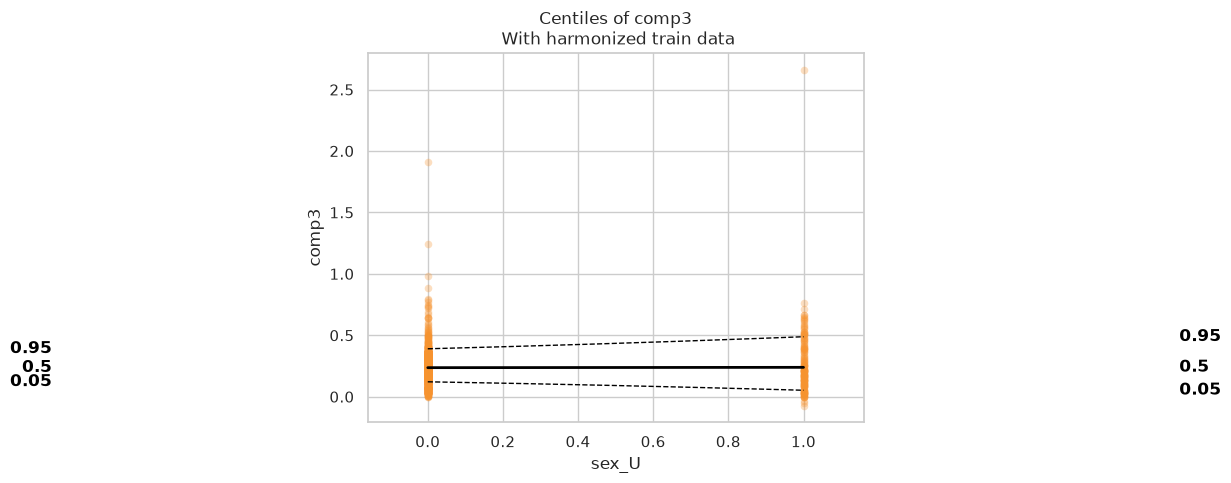

<Figure size 640x480 with 0 Axes>

/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


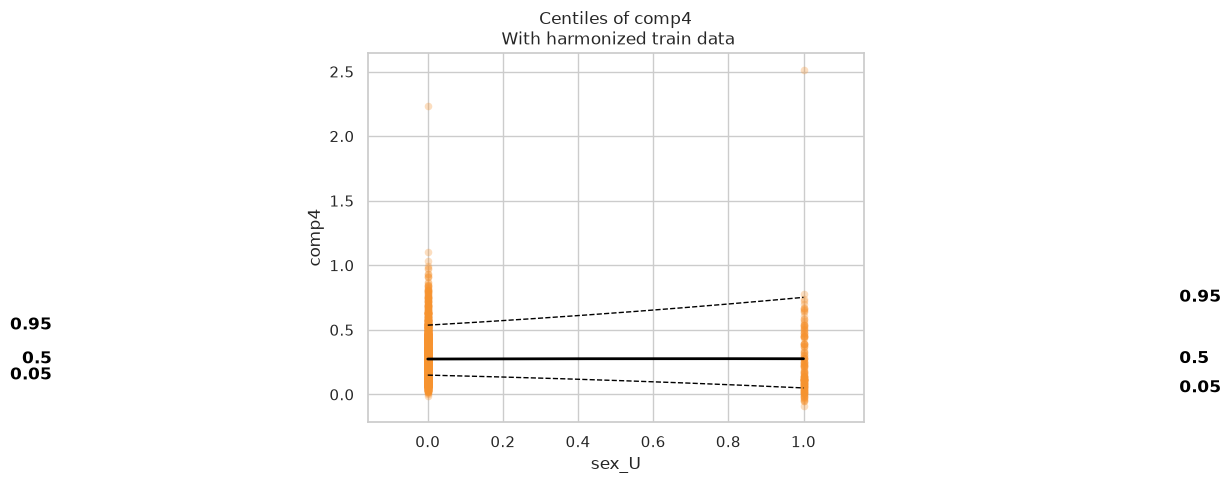

<Figure size 640x480 with 0 Axes>

/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


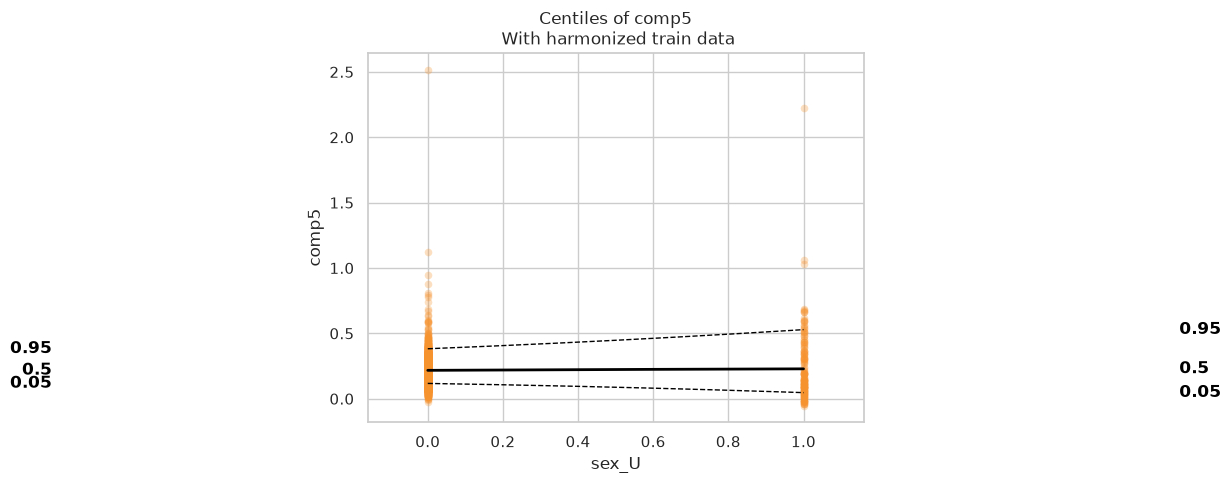

<Figure size 640x480 with 0 Axes>

/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


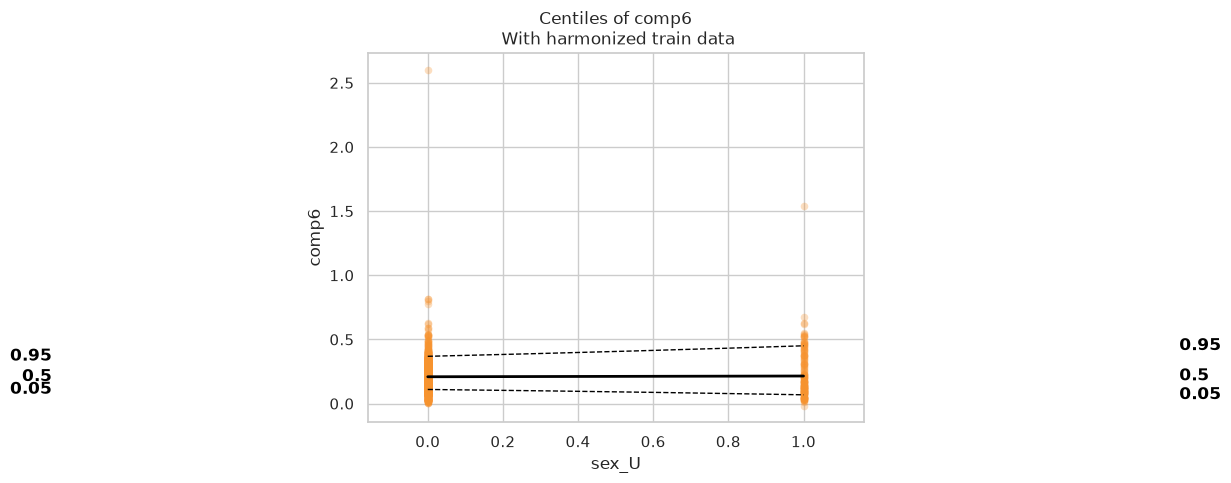

<Figure size 640x480 with 0 Axes>

/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


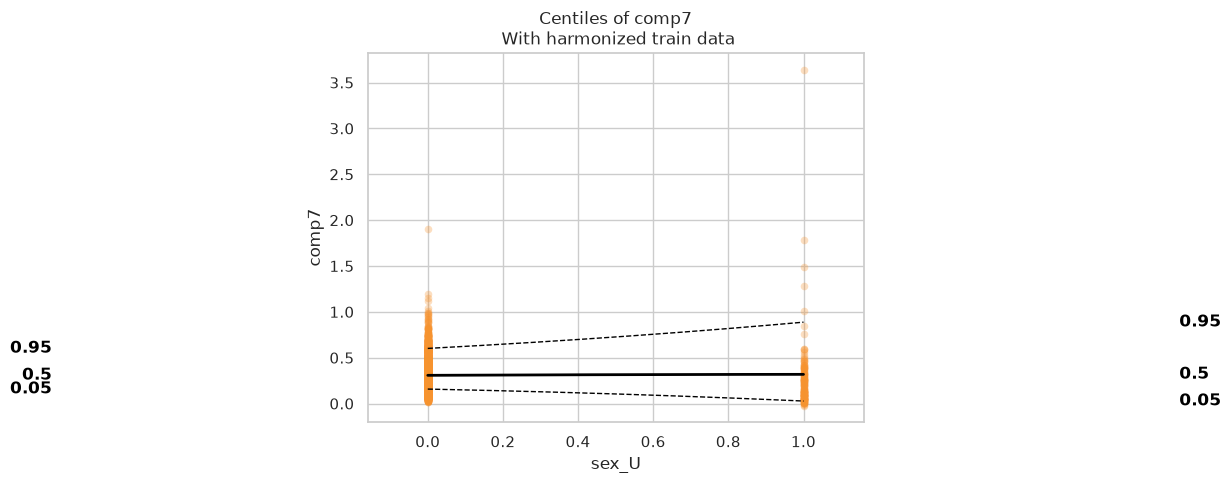

<Figure size 640x480 with 0 Axes>

/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


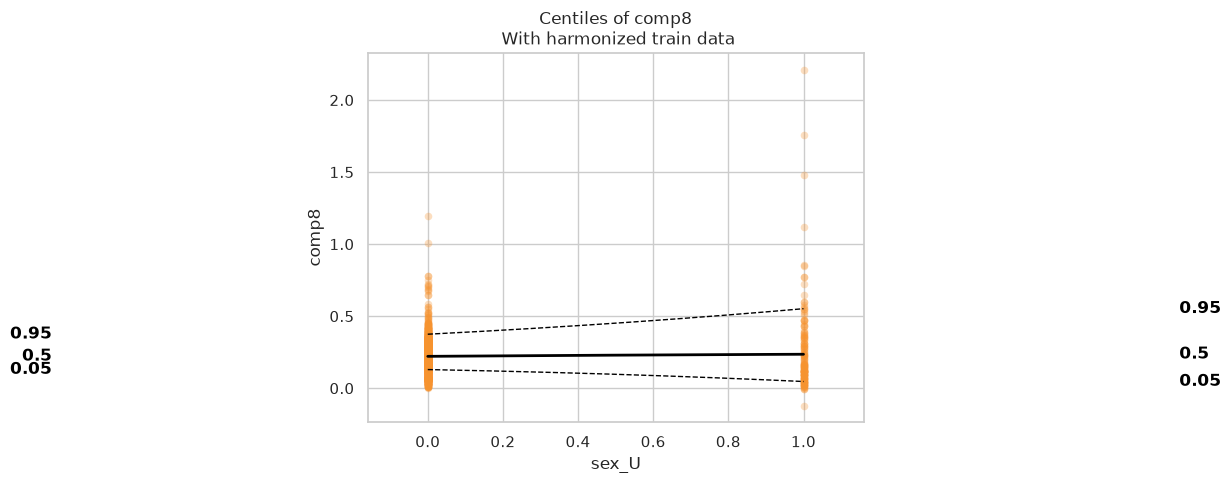

<Figure size 640x480 with 0 Axes>

/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


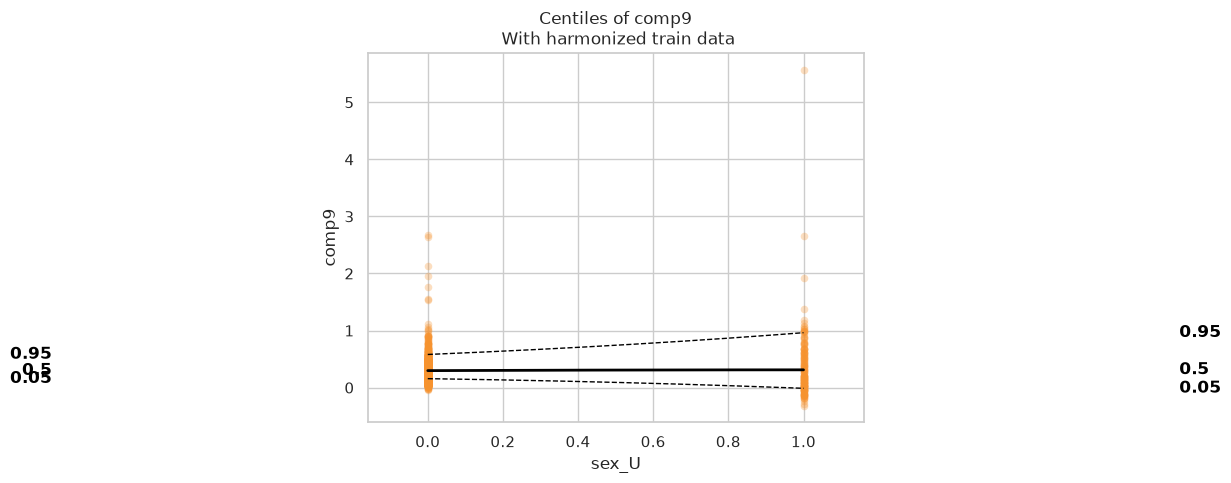

<Figure size 640x480 with 0 Axes>

/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


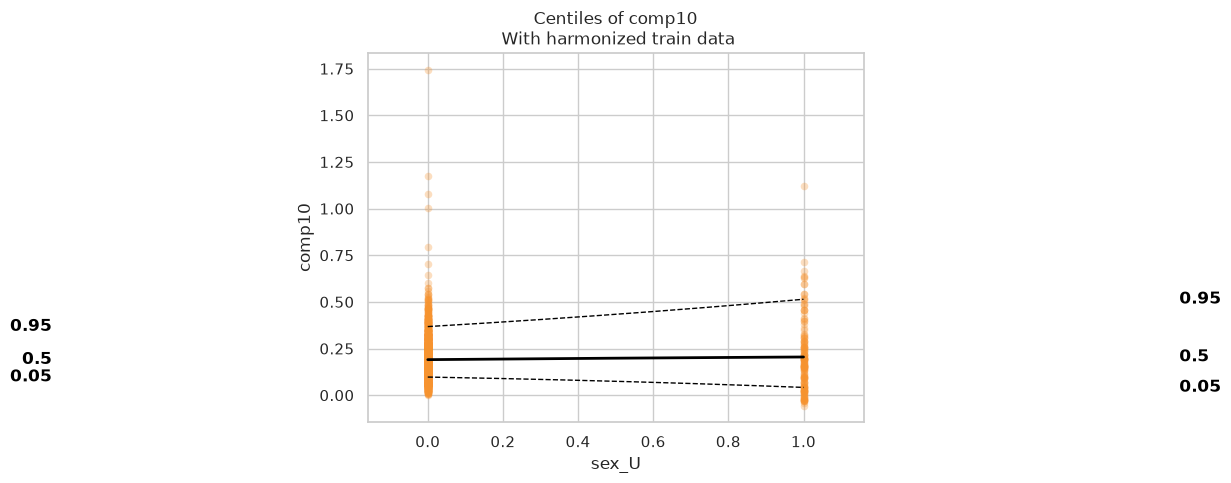

<Figure size 640x480 with 0 Axes>

/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


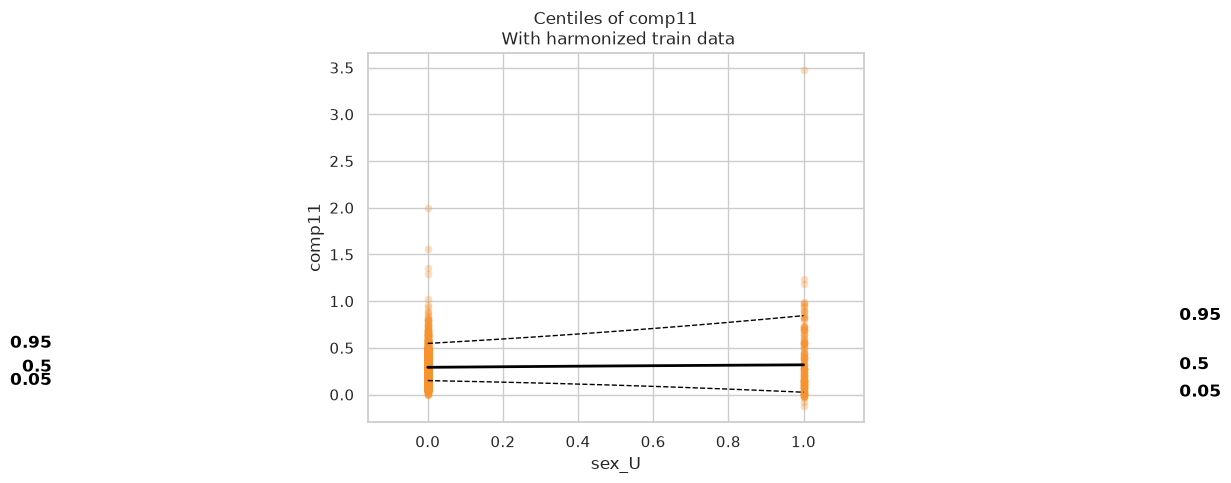

<Figure size 640x480 with 0 Axes>

/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


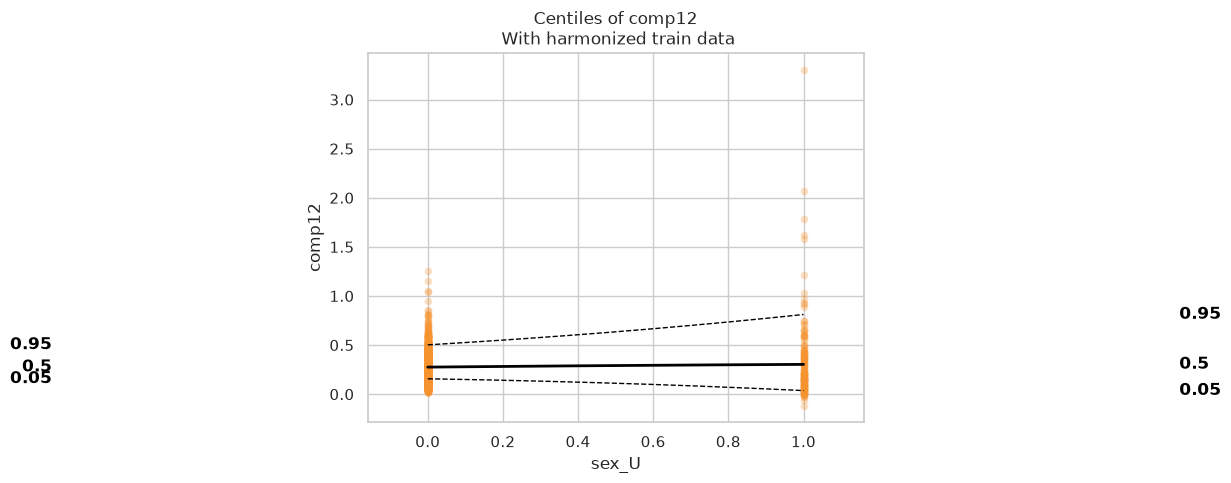

<Figure size 640x480 with 0 Axes>

/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


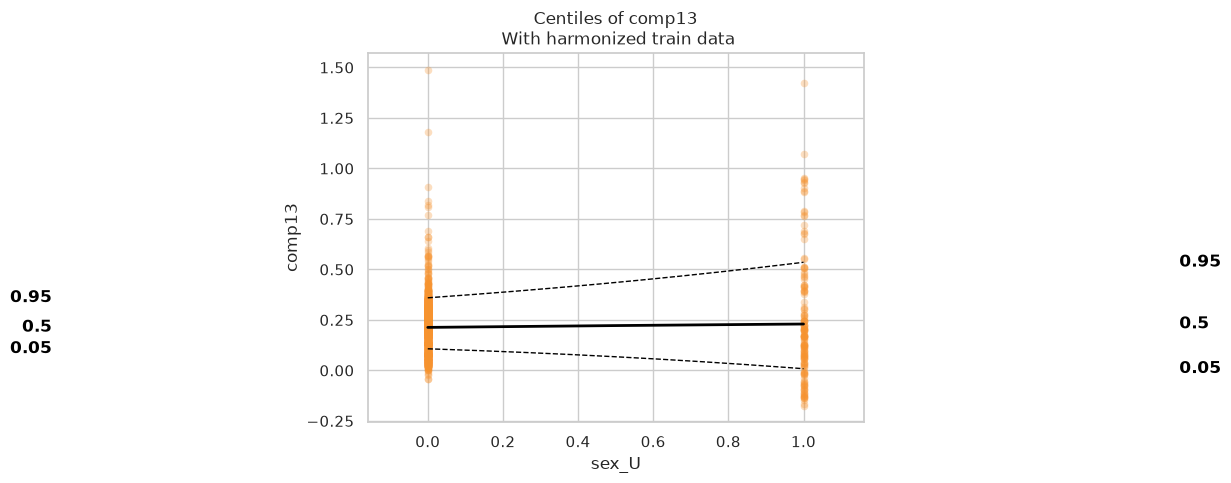

<Figure size 640x480 with 0 Axes>

/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


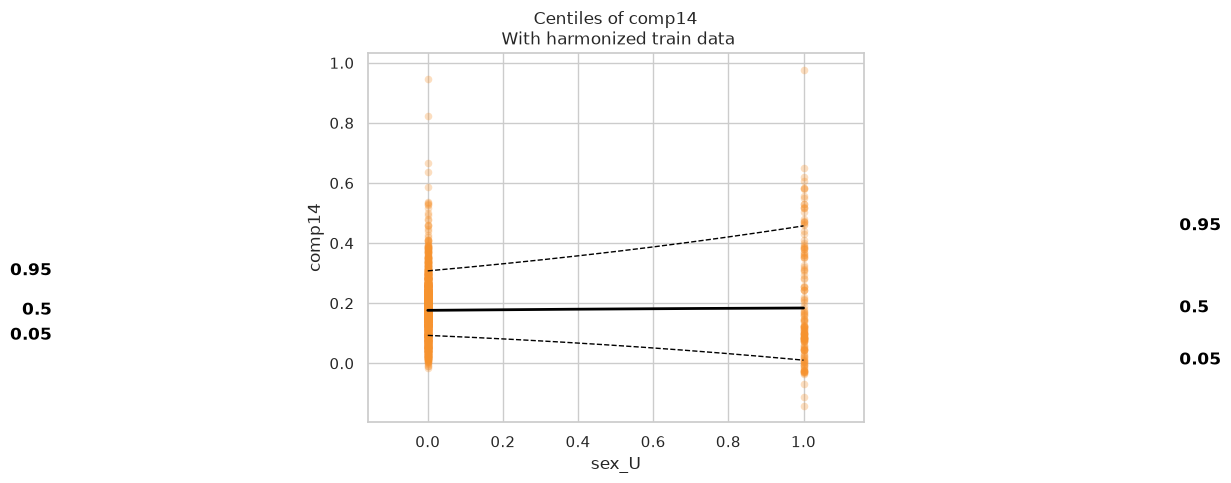

<Figure size 640x480 with 0 Axes>

/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


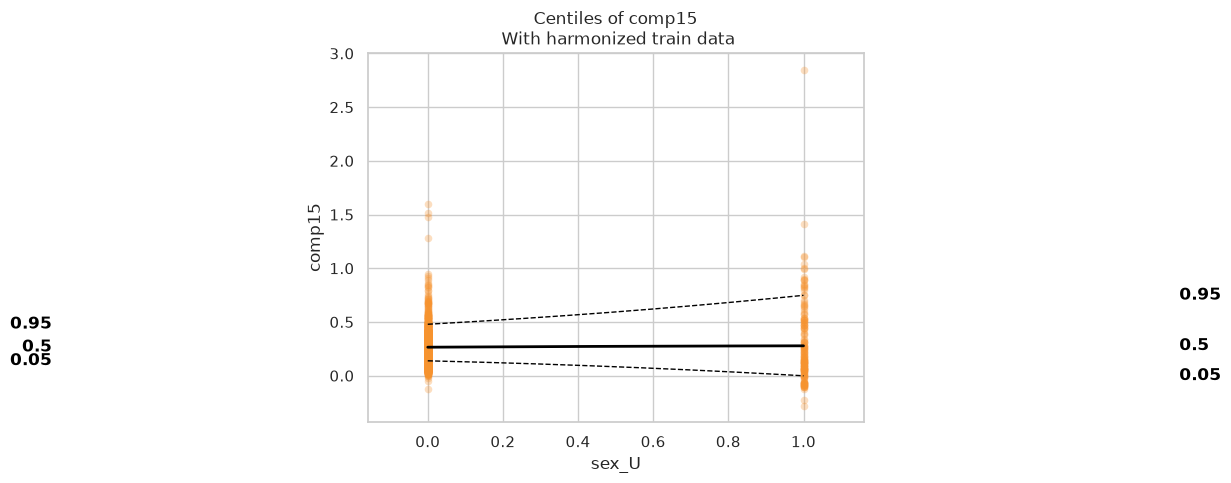

<Figure size 640x480 with 0 Axes>

/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


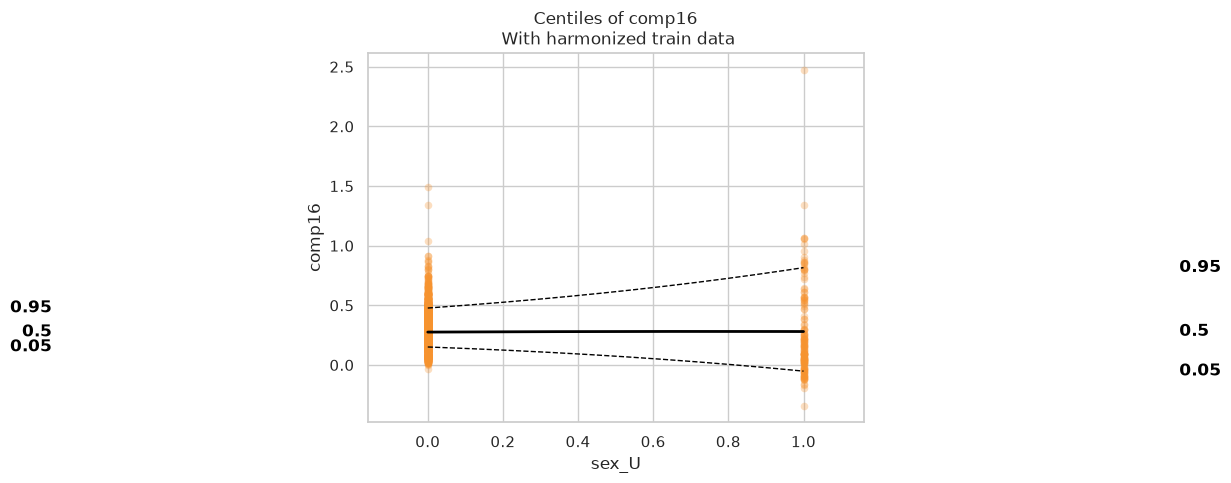

<Figure size 640x480 with 0 Axes>

/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


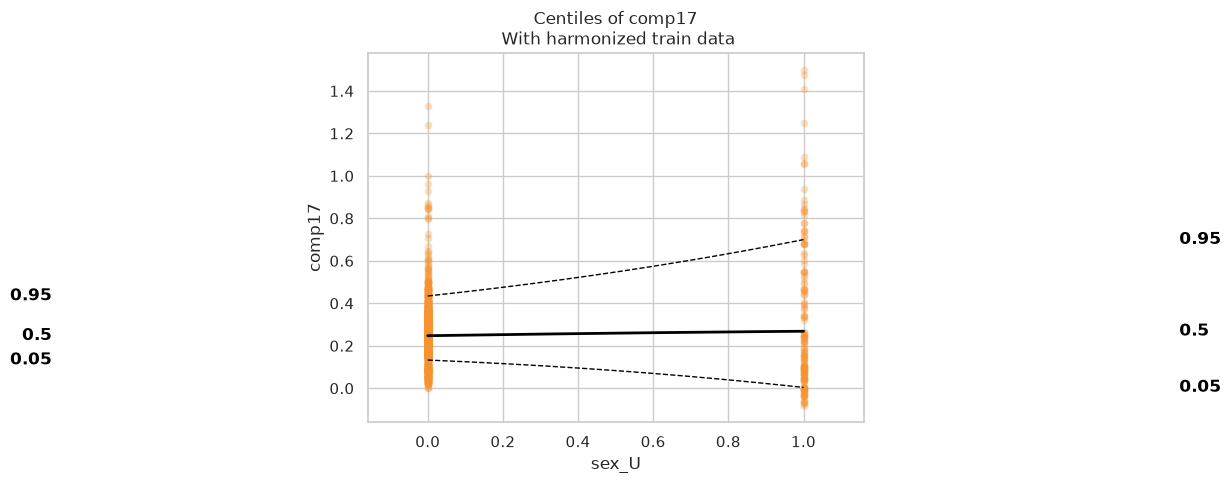

<Figure size 640x480 with 0 Axes>

/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


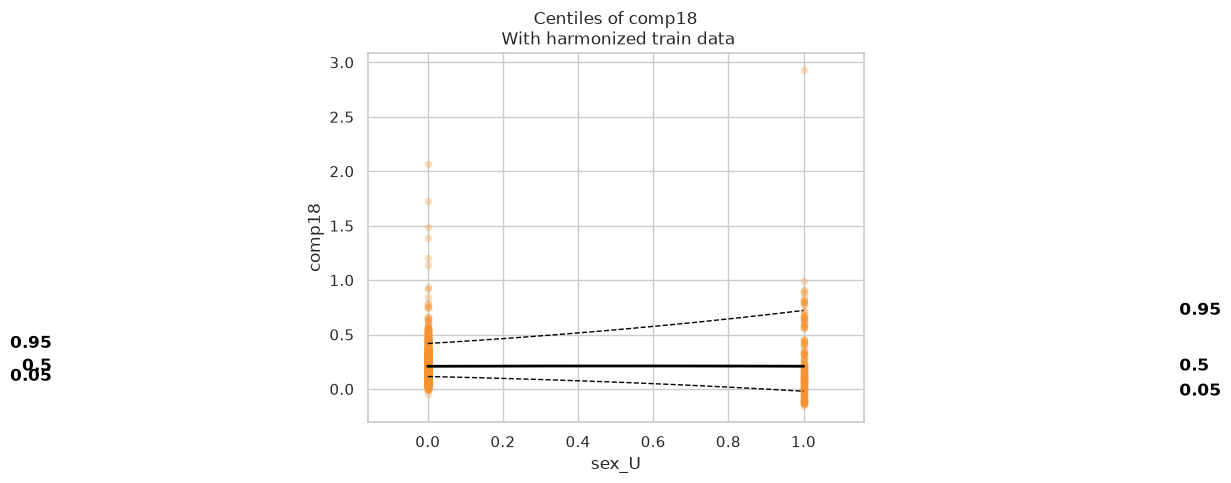

<Figure size 640x480 with 0 Axes>

/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


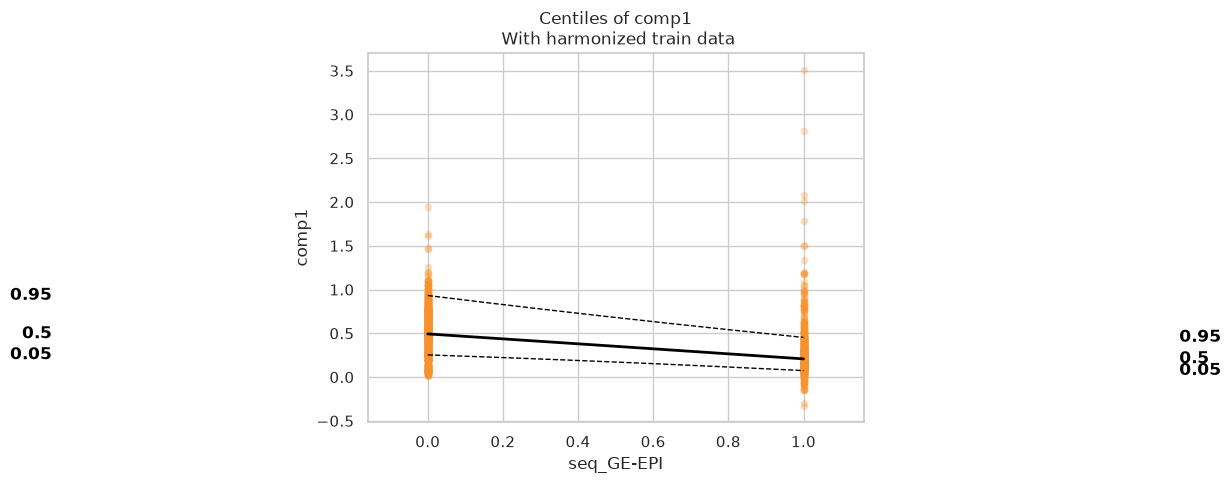

<Figure size 640x480 with 0 Axes>

/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


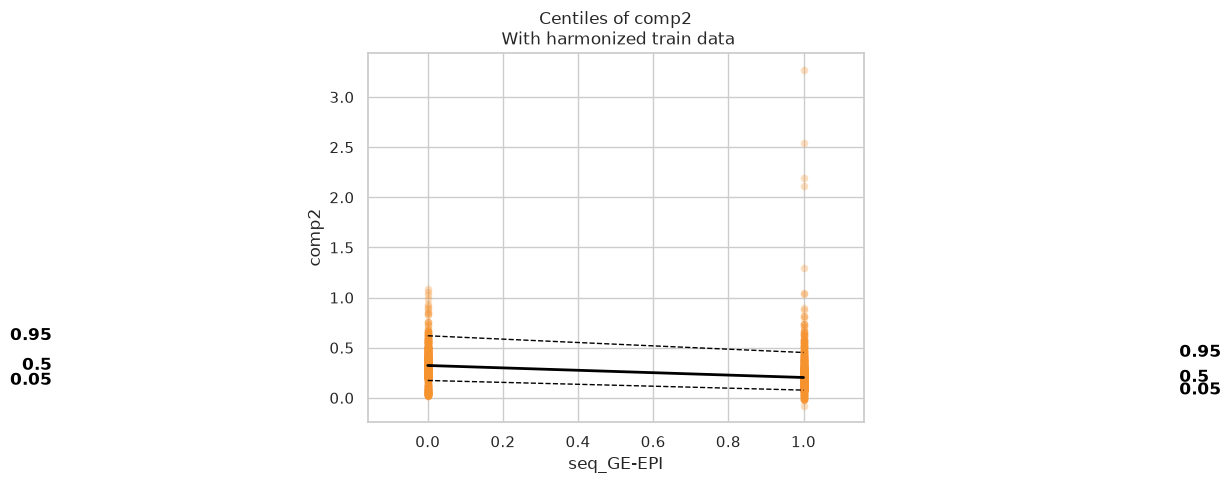

<Figure size 640x480 with 0 Axes>

/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


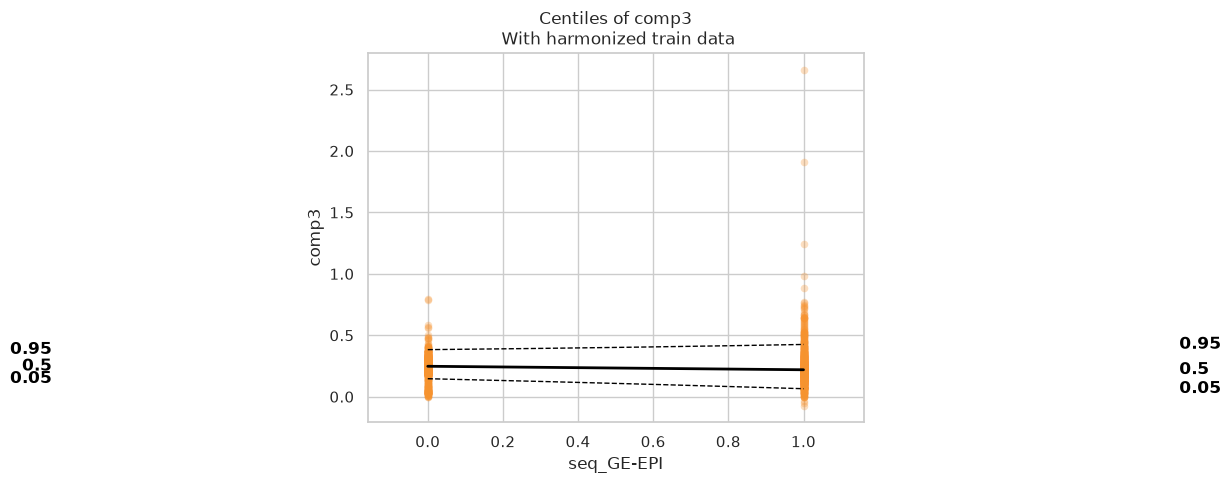

<Figure size 640x480 with 0 Axes>

/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


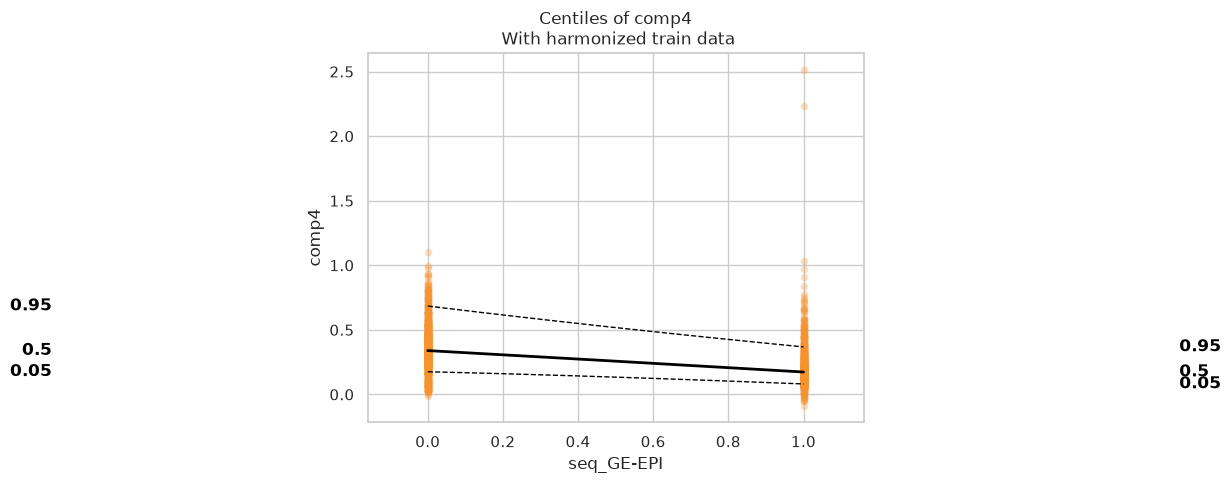

<Figure size 640x480 with 0 Axes>

/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


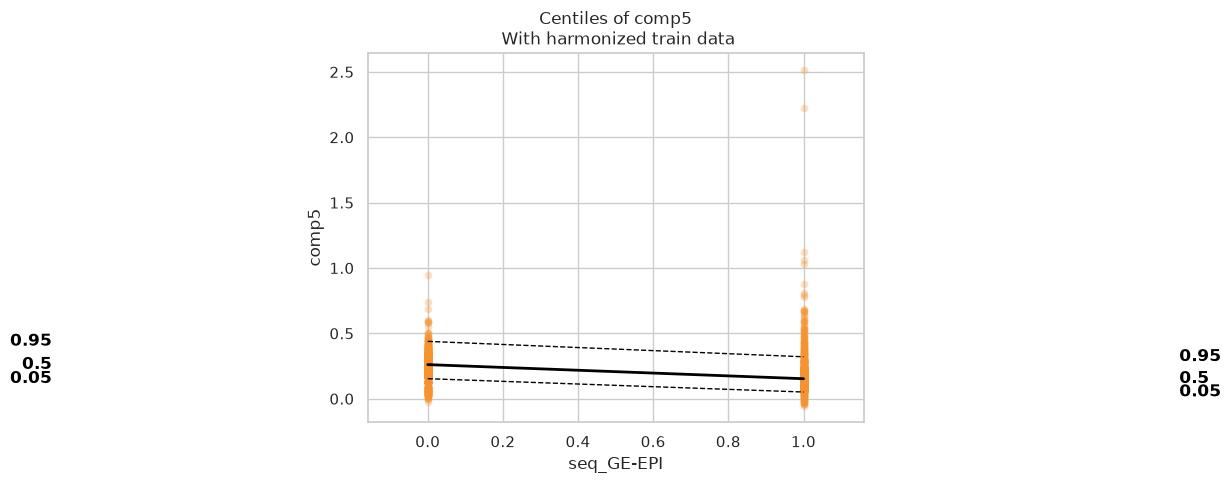

<Figure size 640x480 with 0 Axes>

/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


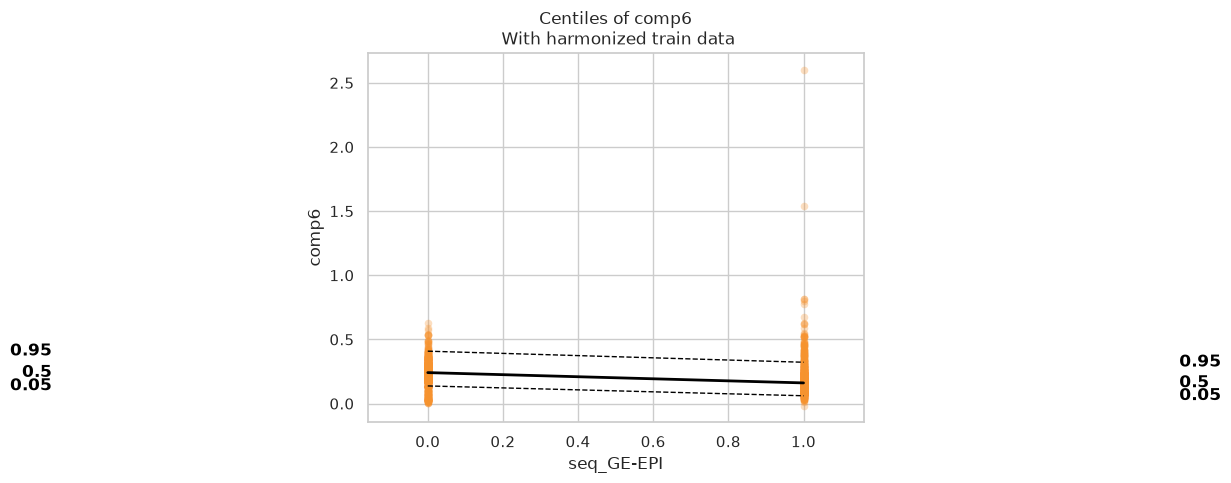

<Figure size 640x480 with 0 Axes>

/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


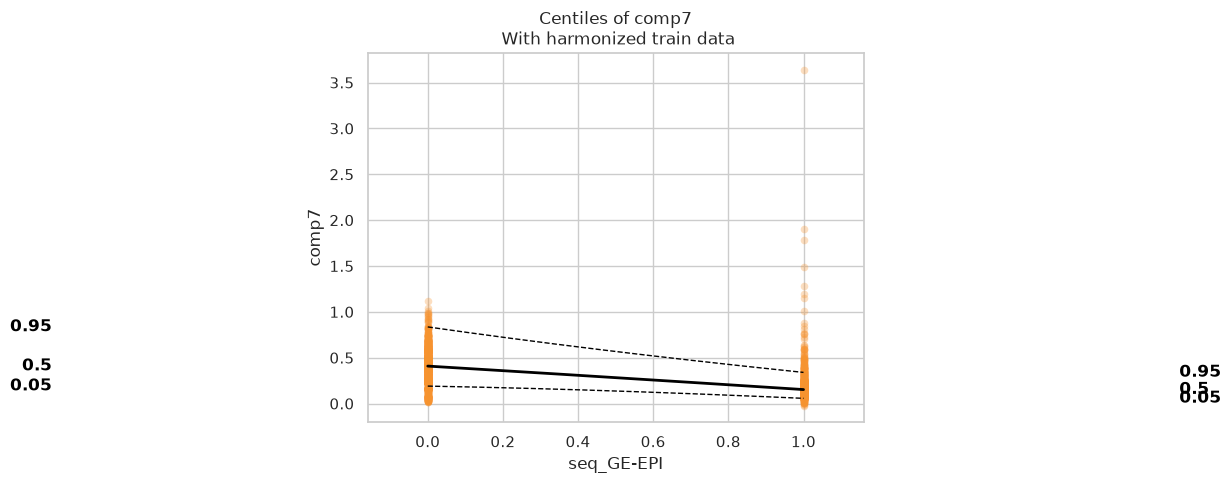

<Figure size 640x480 with 0 Axes>

/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


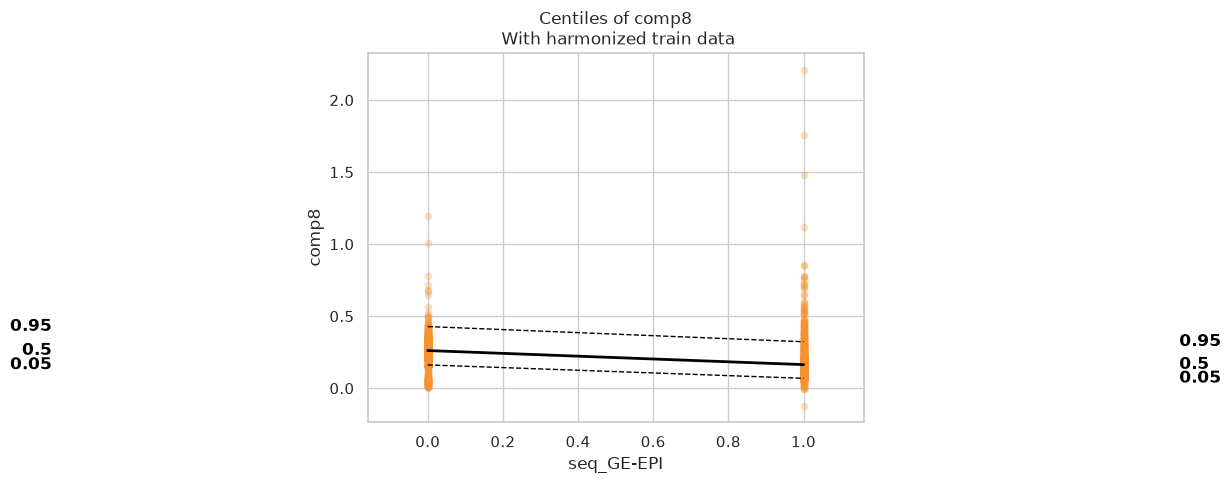

<Figure size 640x480 with 0 Axes>

/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


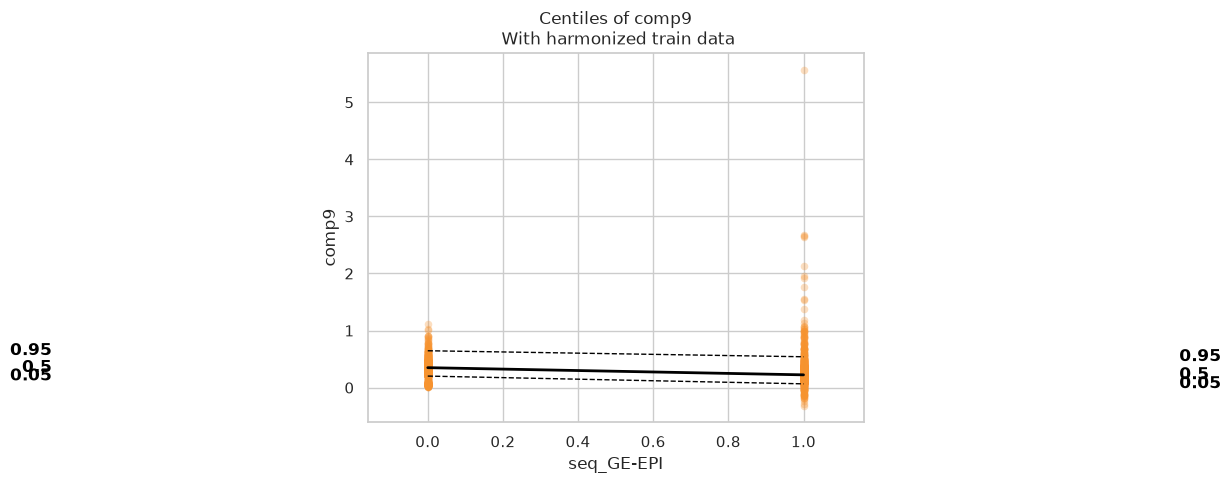

<Figure size 640x480 with 0 Axes>

/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


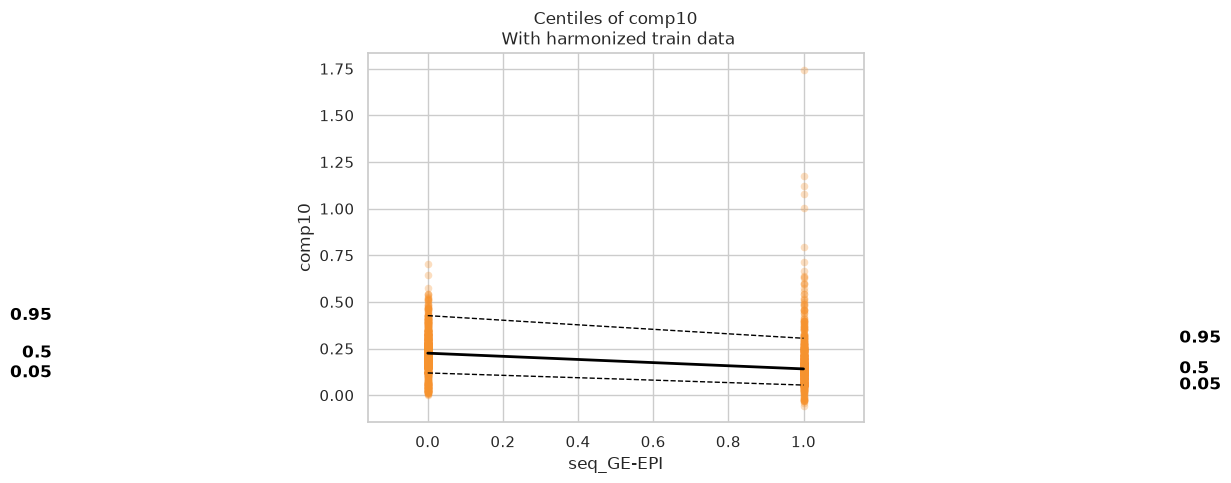

<Figure size 640x480 with 0 Axes>

/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


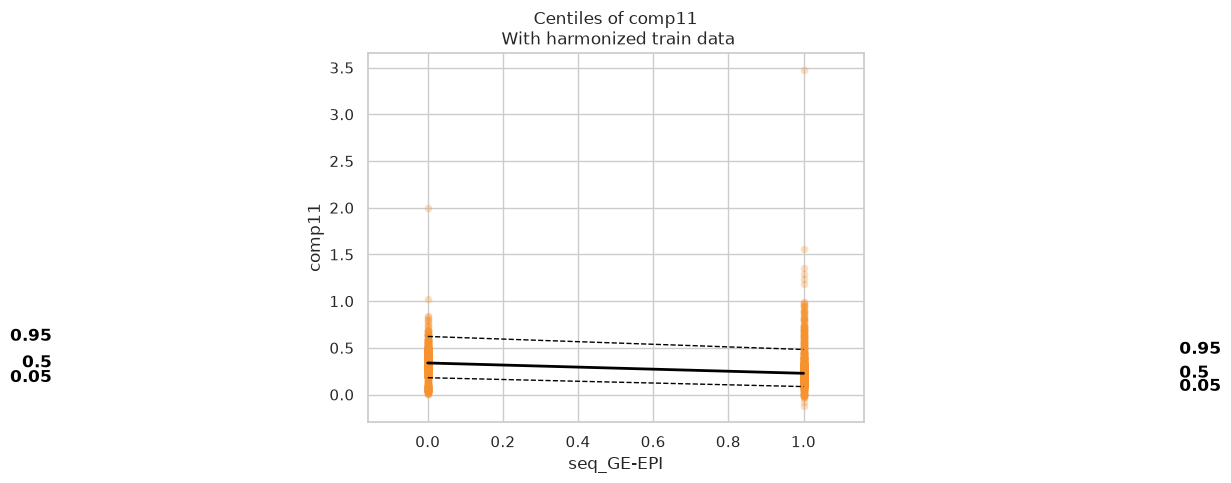

<Figure size 640x480 with 0 Axes>

/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


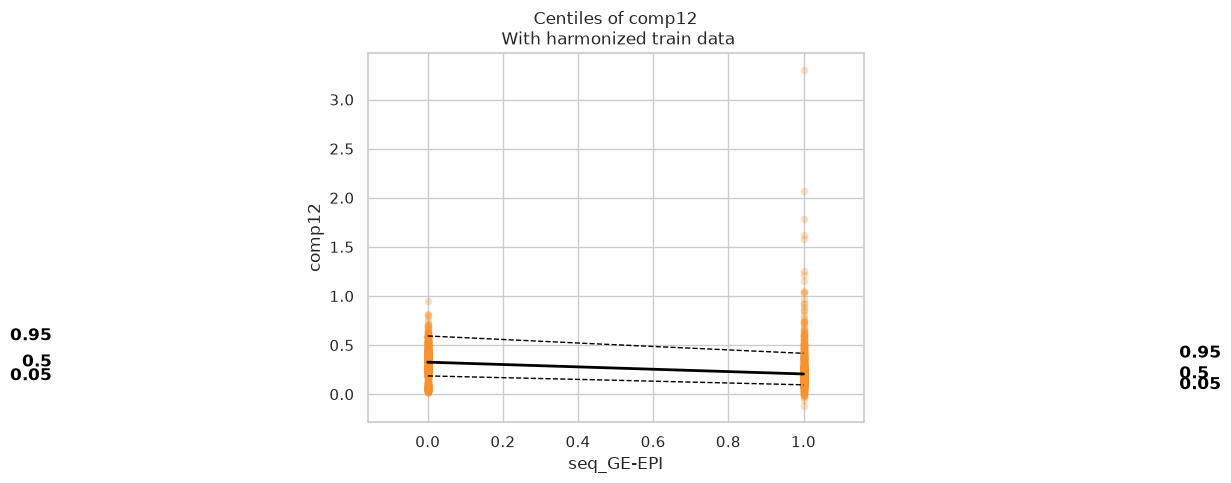

<Figure size 640x480 with 0 Axes>

/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


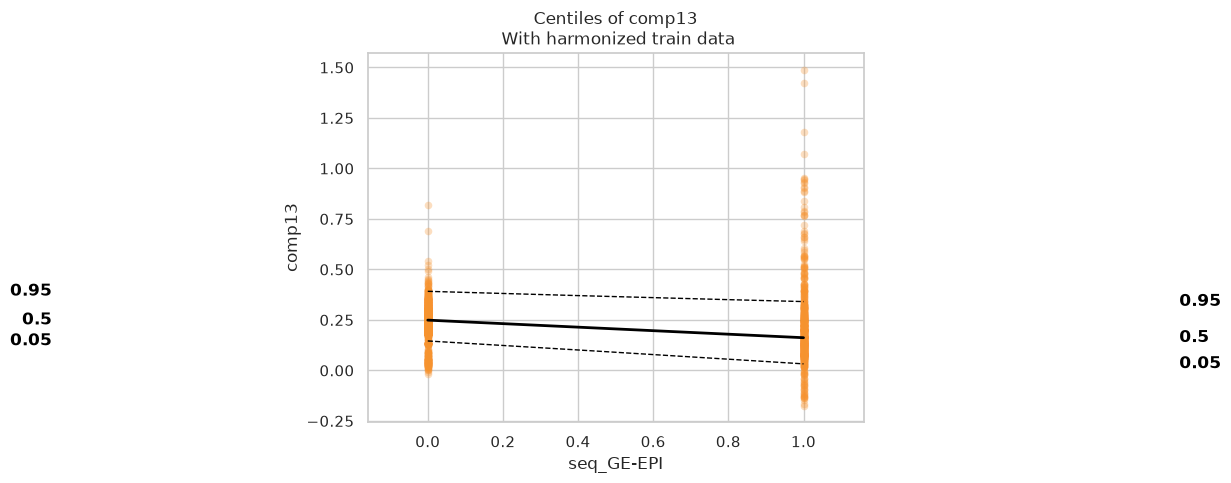

<Figure size 640x480 with 0 Axes>

/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


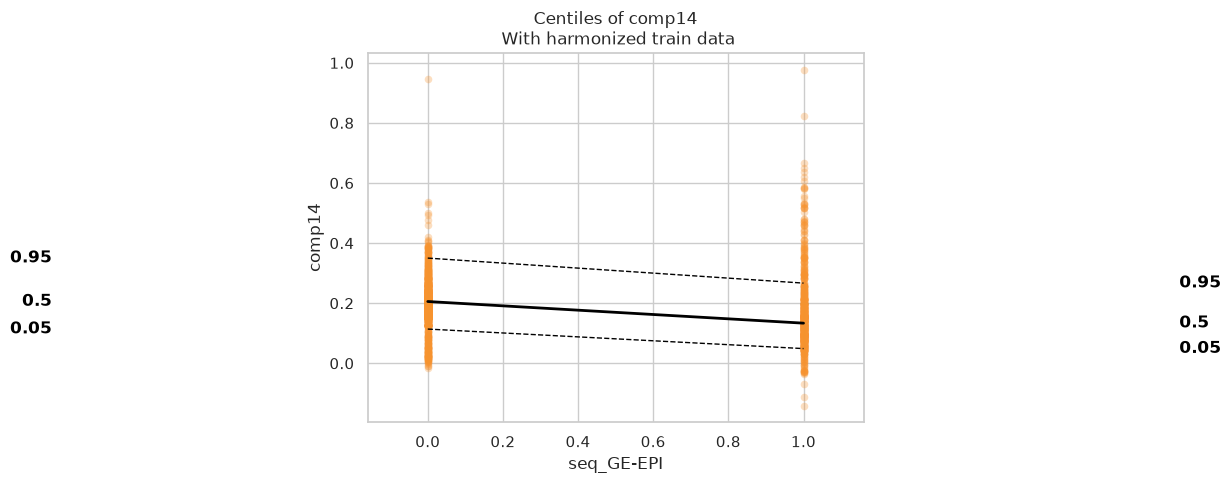

<Figure size 640x480 with 0 Axes>

/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


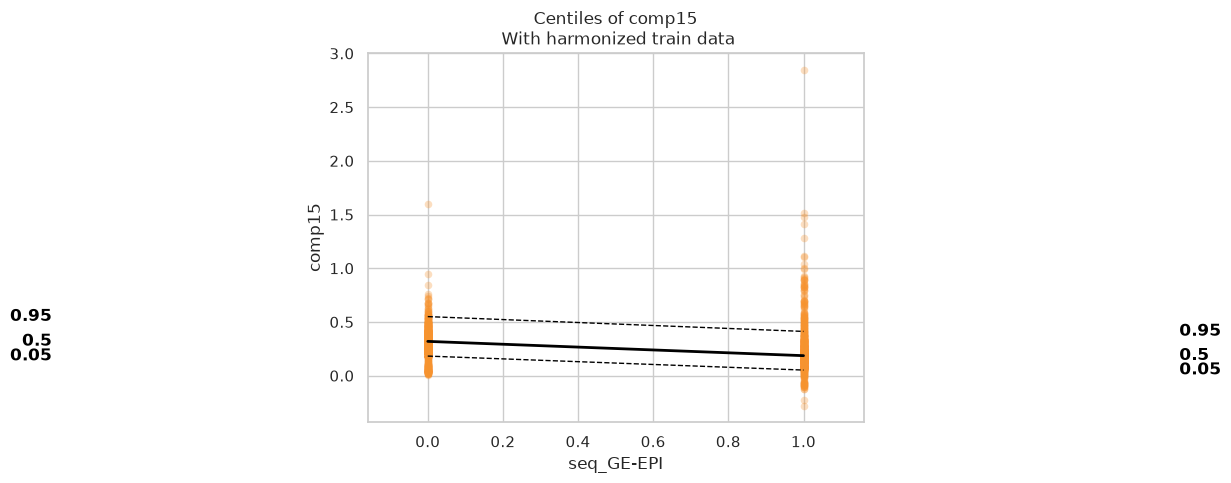

<Figure size 640x480 with 0 Axes>

/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


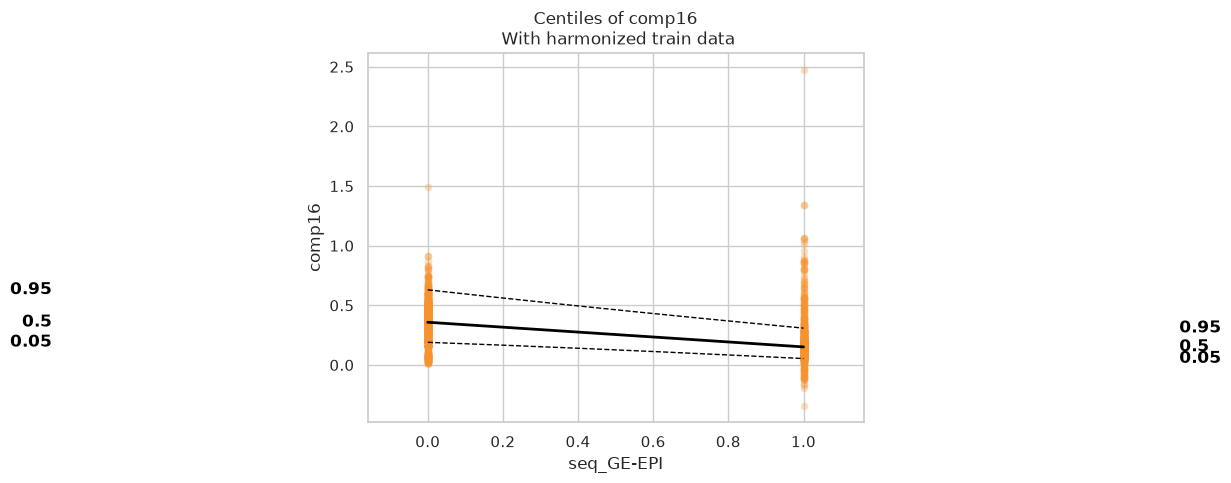

<Figure size 640x480 with 0 Axes>

/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


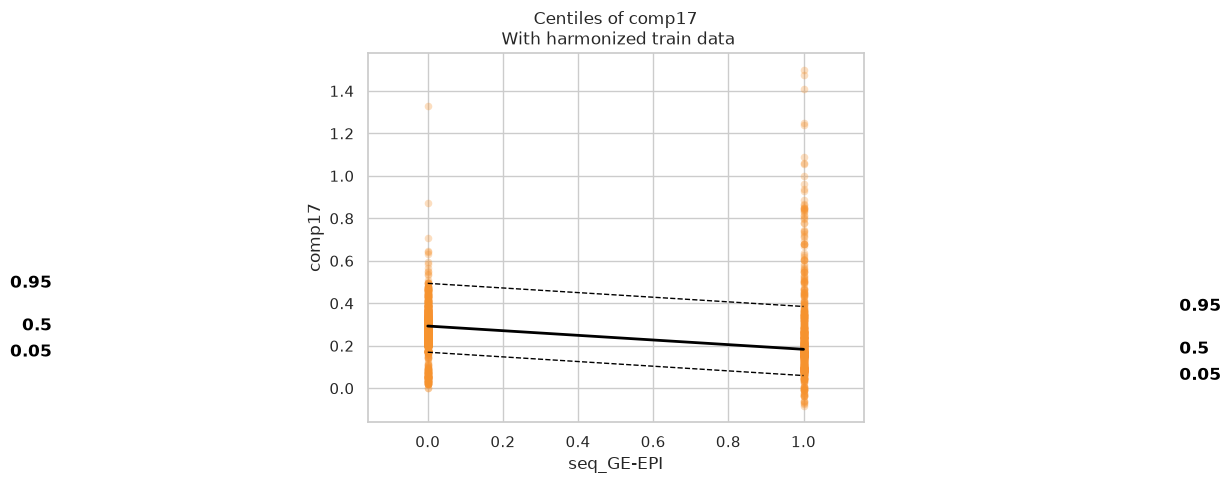

<Figure size 640x480 with 0 Axes>

/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


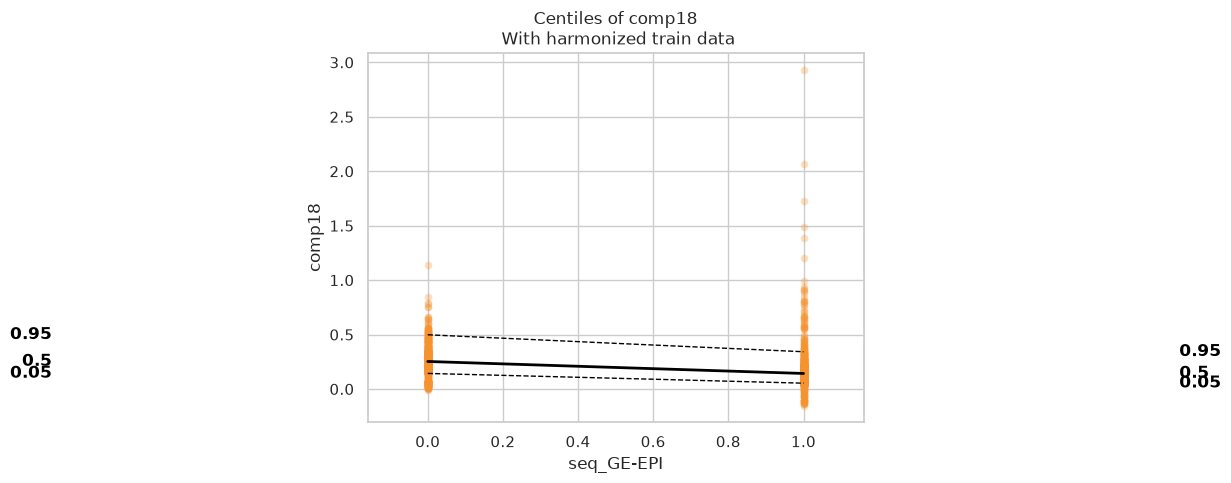

<Figure size 640x480 with 0 Axes>

/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


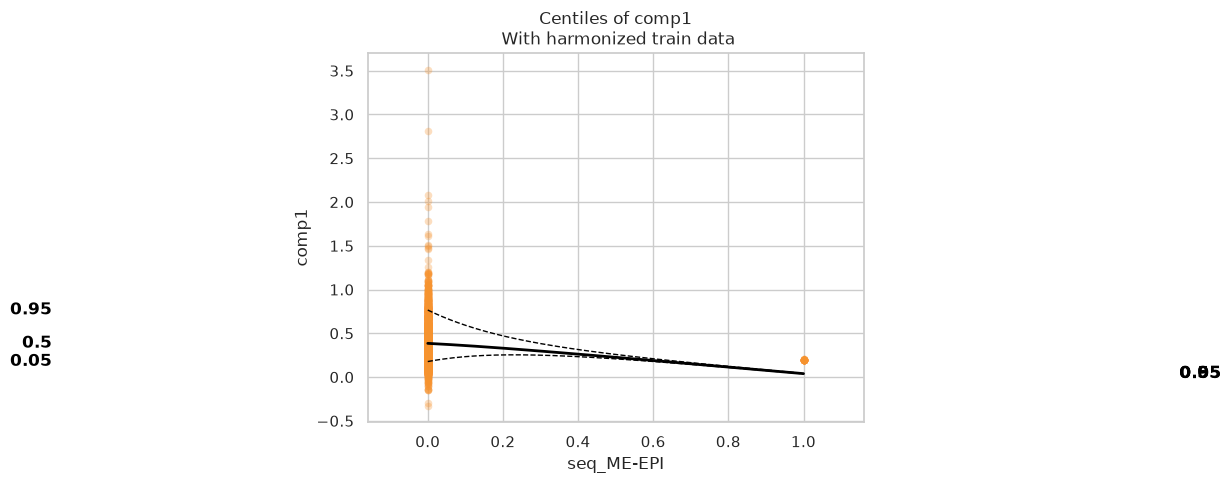

<Figure size 640x480 with 0 Axes>

/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


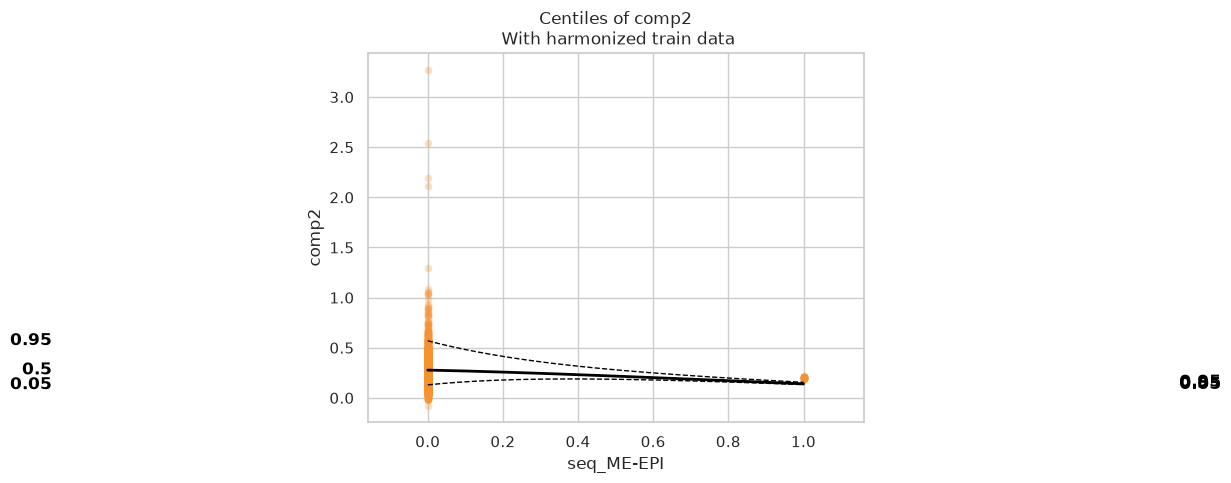

<Figure size 640x480 with 0 Axes>

/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


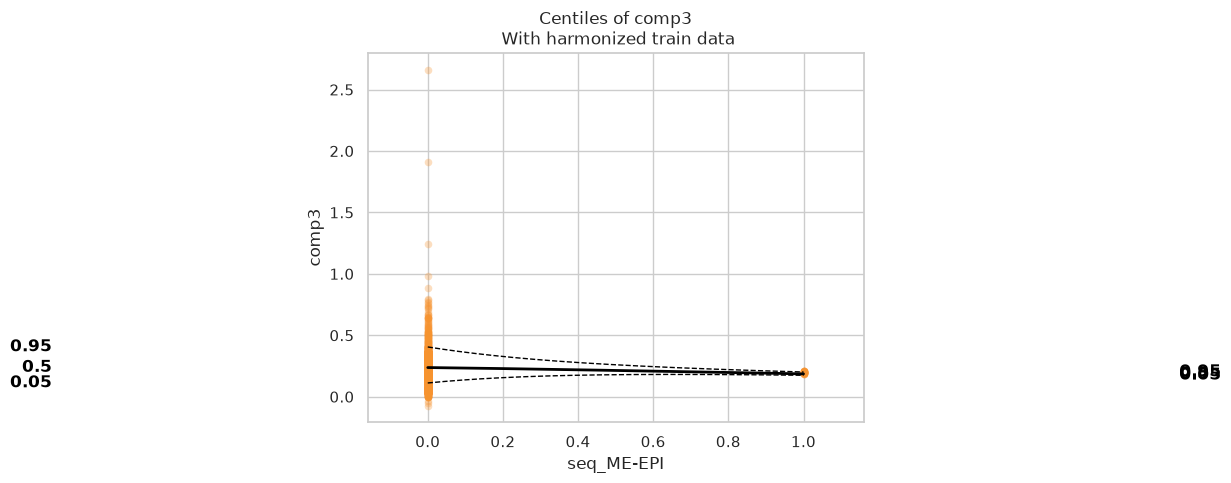

<Figure size 640x480 with 0 Axes>

/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


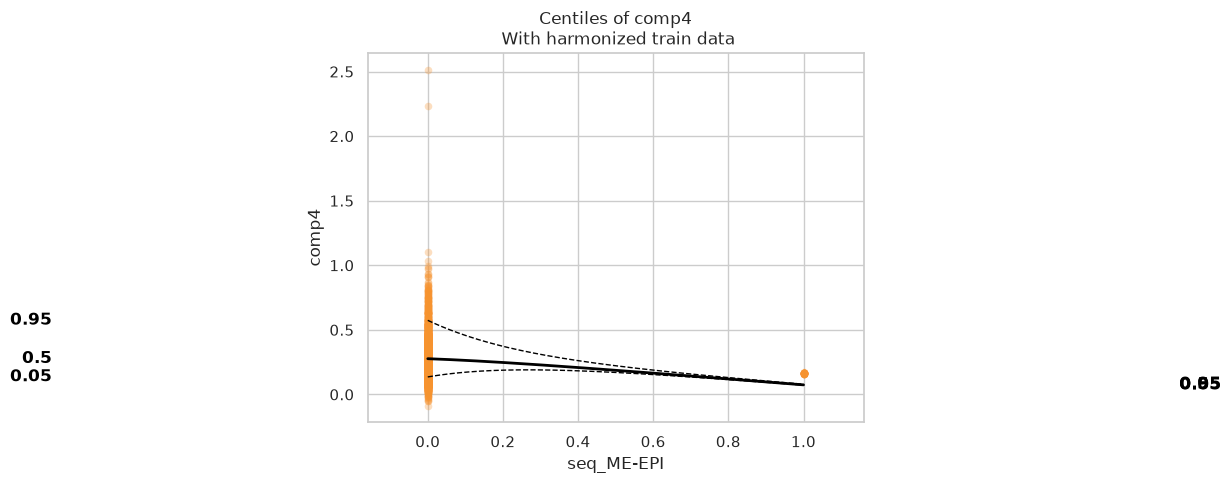

<Figure size 640x480 with 0 Axes>

/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


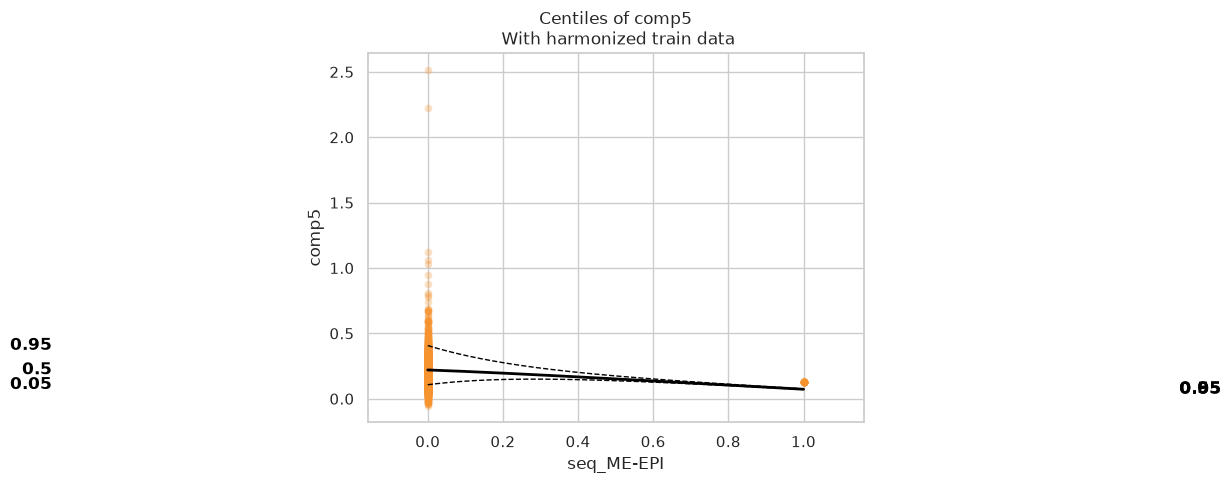

<Figure size 640x480 with 0 Axes>

/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


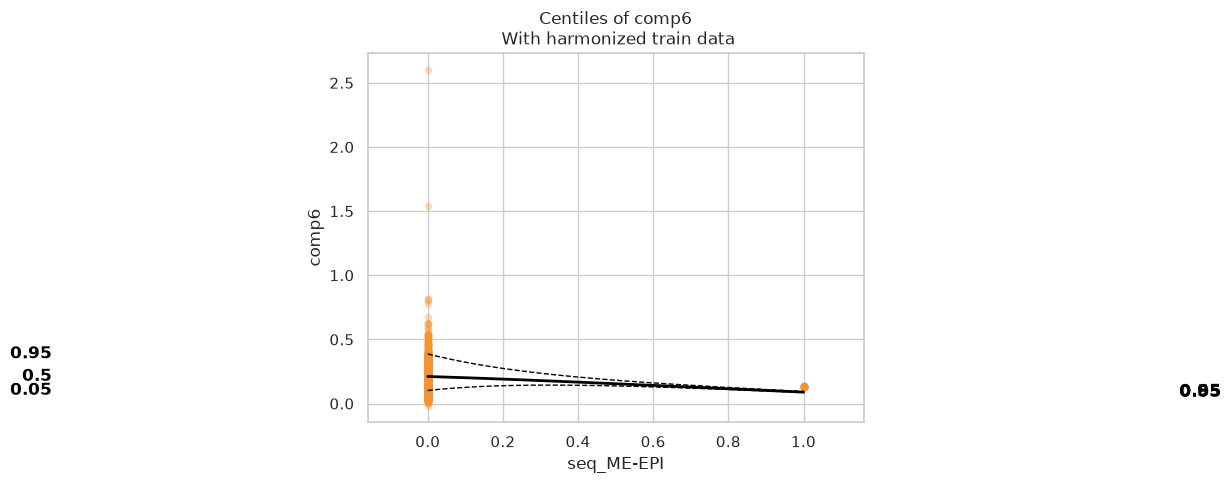

<Figure size 640x480 with 0 Axes>

/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


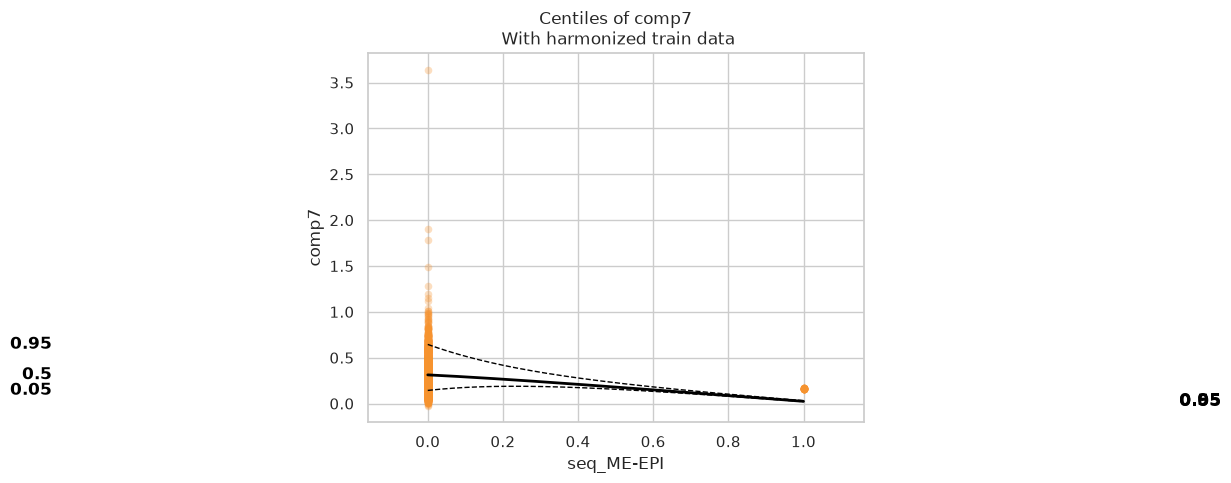

<Figure size 640x480 with 0 Axes>

/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


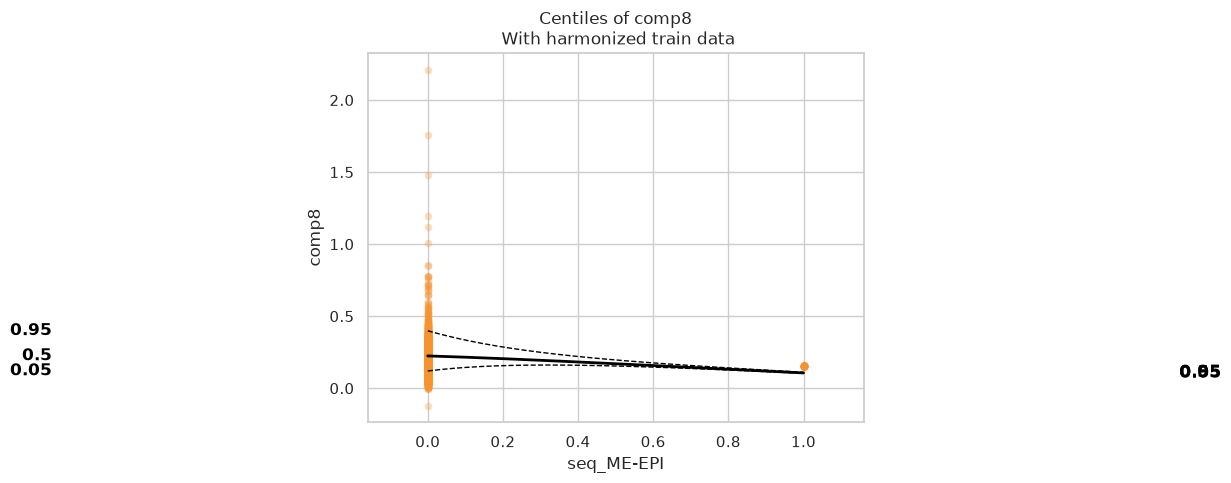

<Figure size 640x480 with 0 Axes>

/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


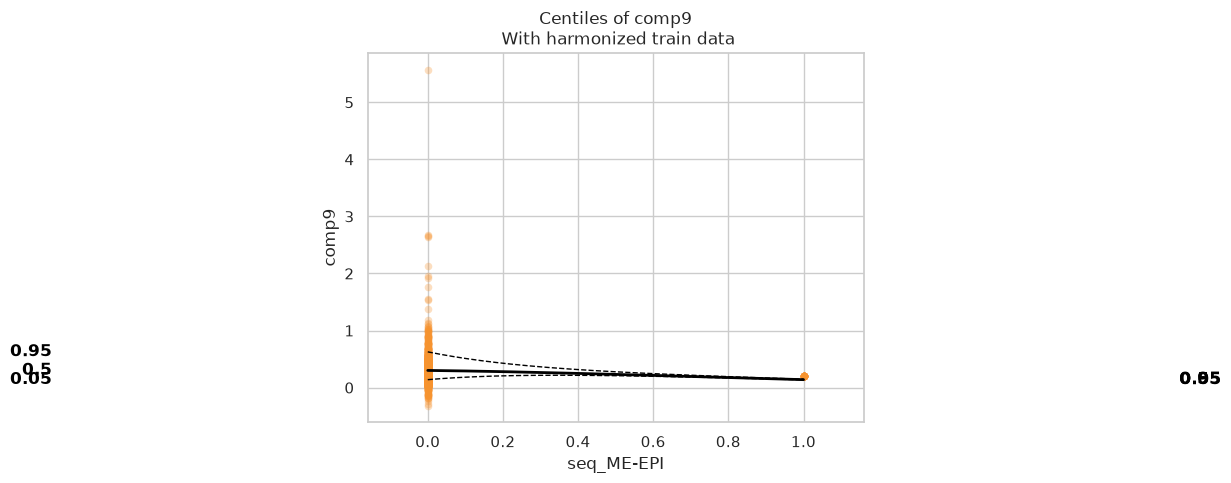

<Figure size 640x480 with 0 Axes>

/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


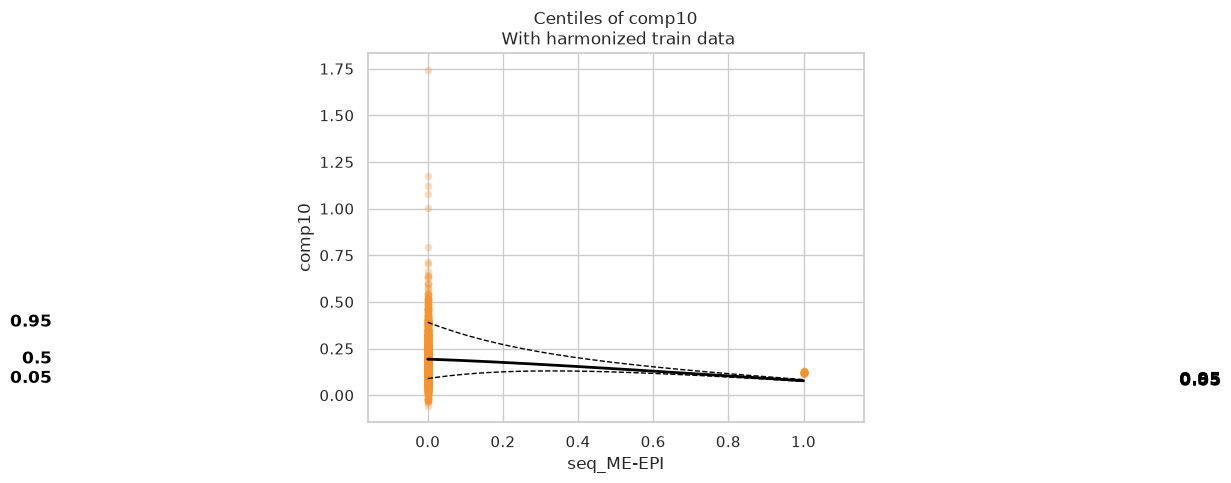

<Figure size 640x480 with 0 Axes>

/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


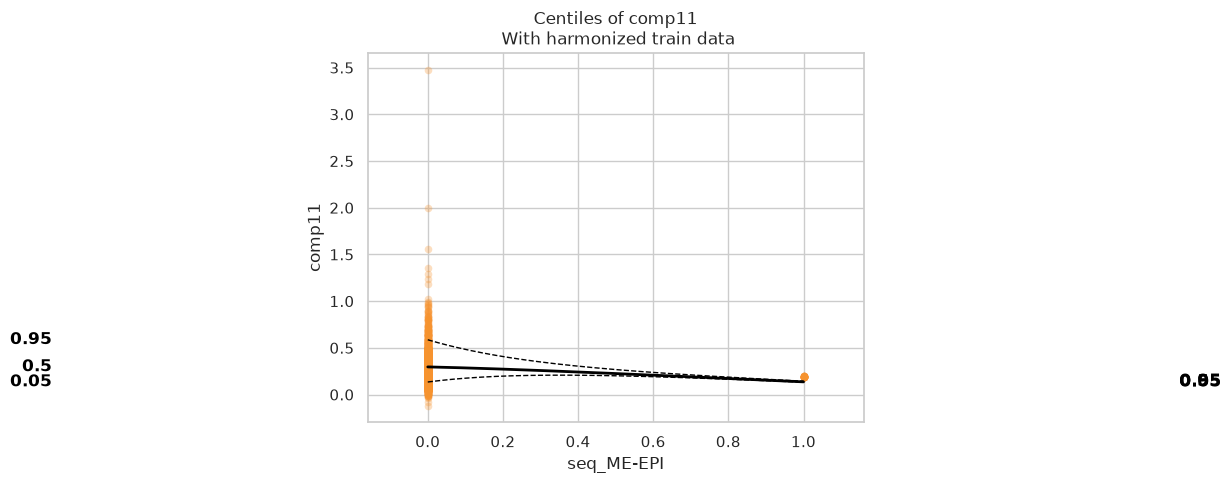

<Figure size 640x480 with 0 Axes>

/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


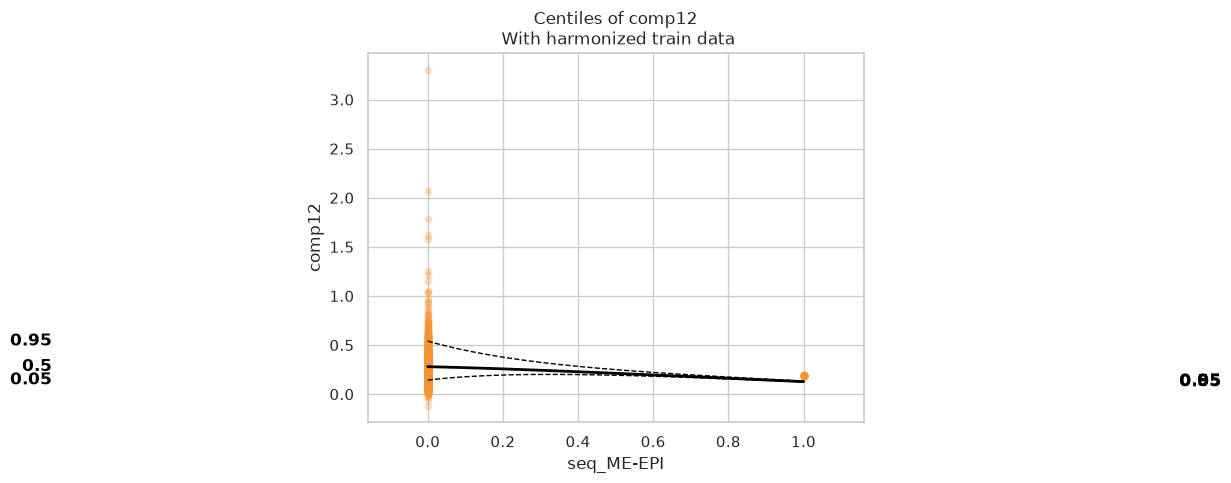

<Figure size 640x480 with 0 Axes>

/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


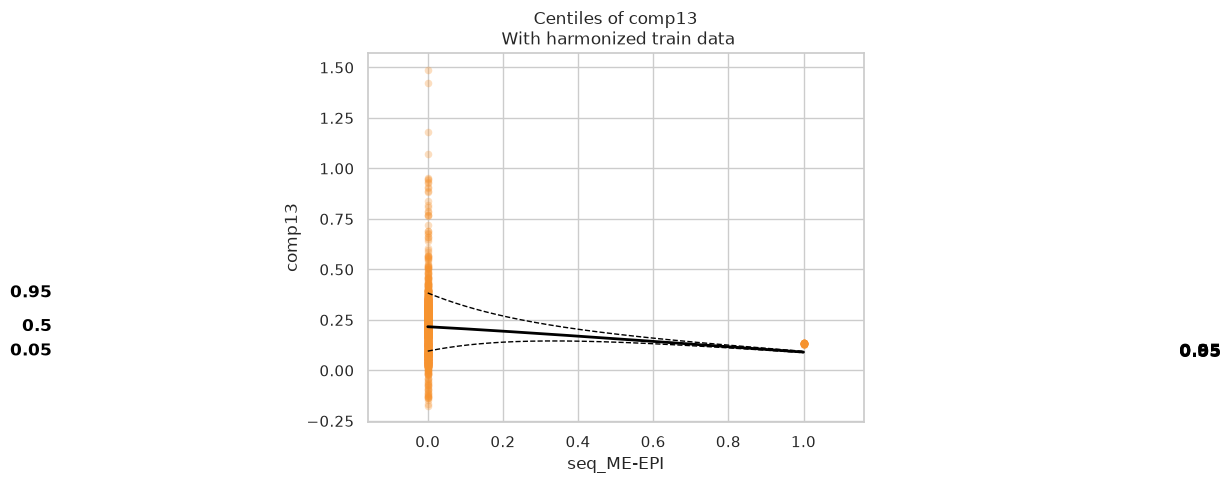

<Figure size 640x480 with 0 Axes>

/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


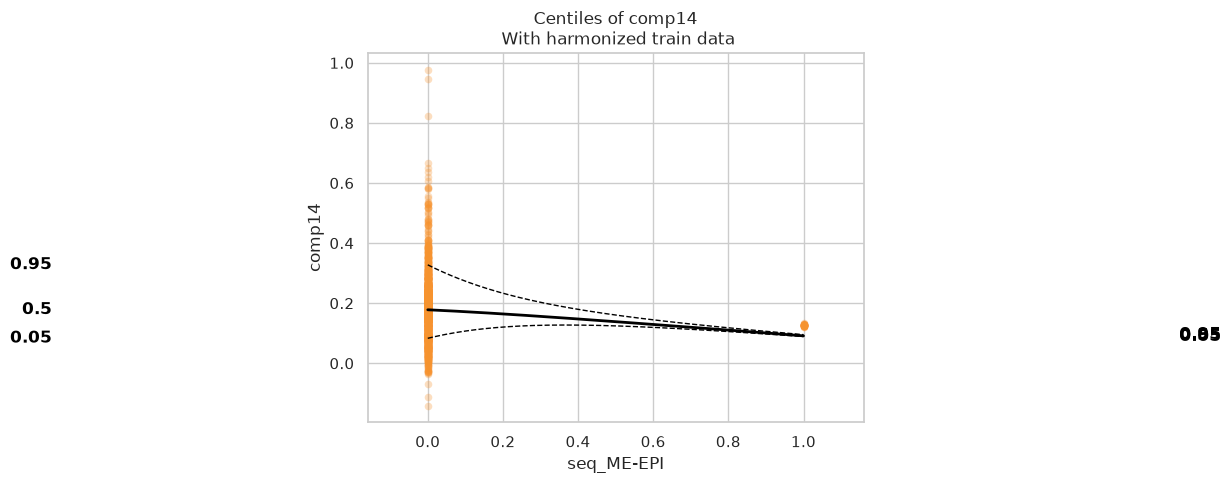

<Figure size 640x480 with 0 Axes>

/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


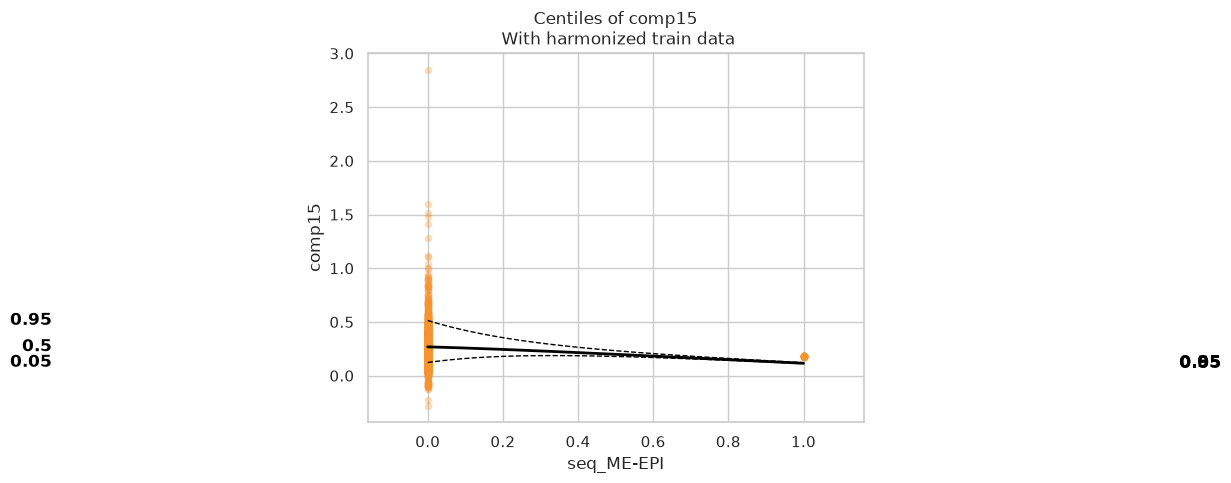

<Figure size 640x480 with 0 Axes>

/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


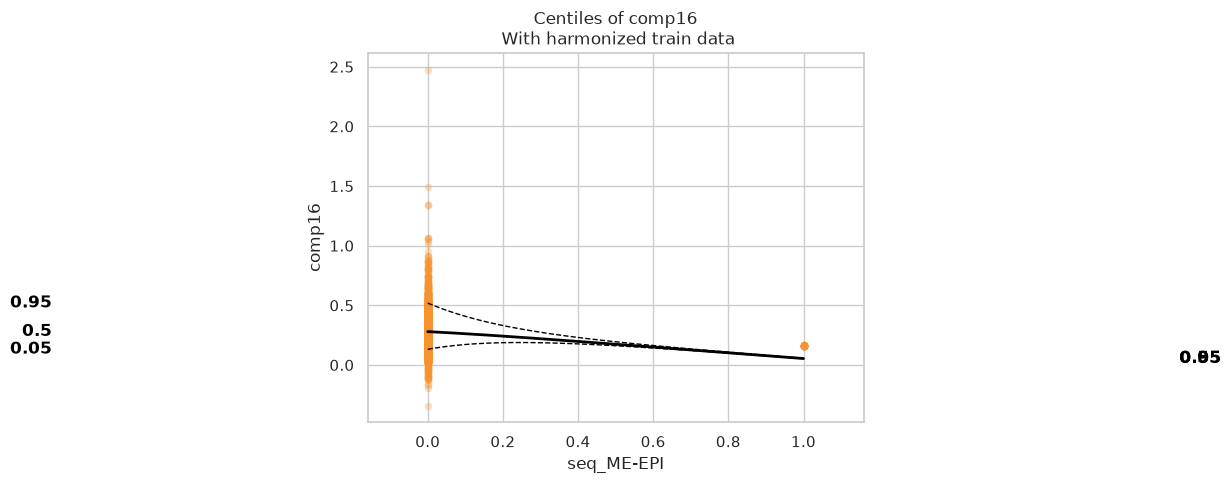

<Figure size 640x480 with 0 Axes>

/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


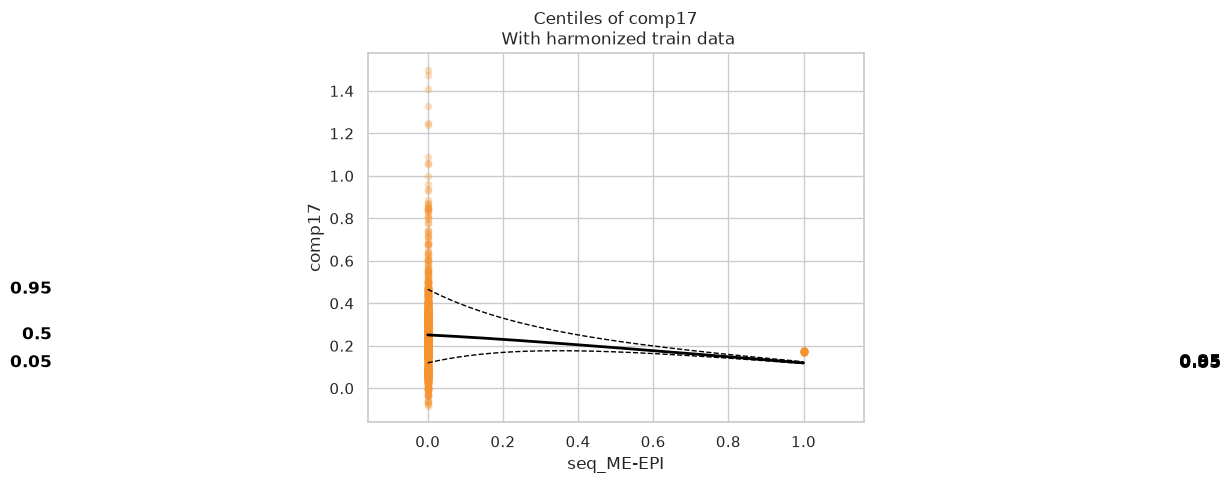

<Figure size 640x480 with 0 Axes>

/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


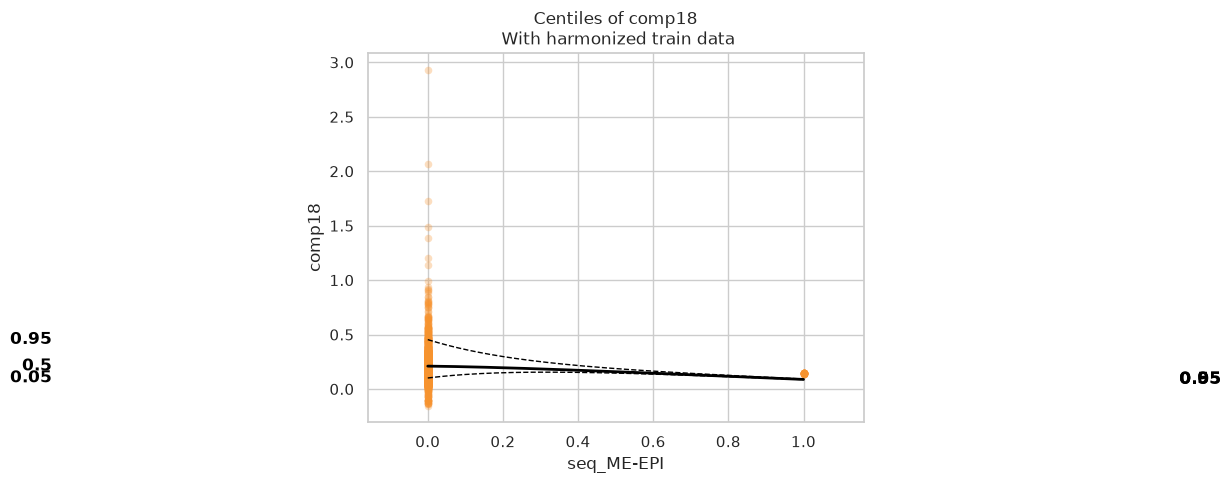

<Figure size 640x480 with 0 Axes>

/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


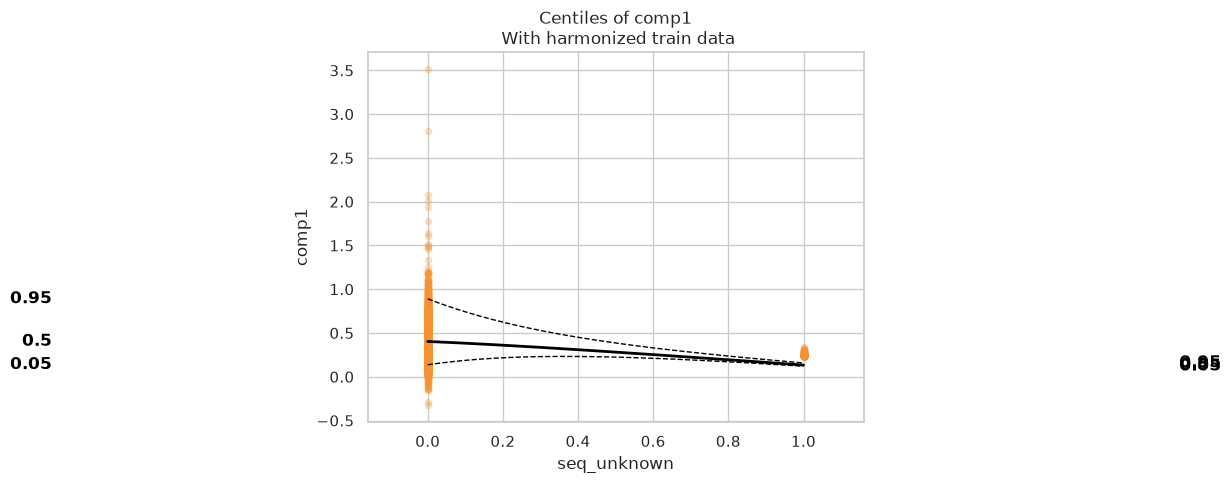

<Figure size 640x480 with 0 Axes>

/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


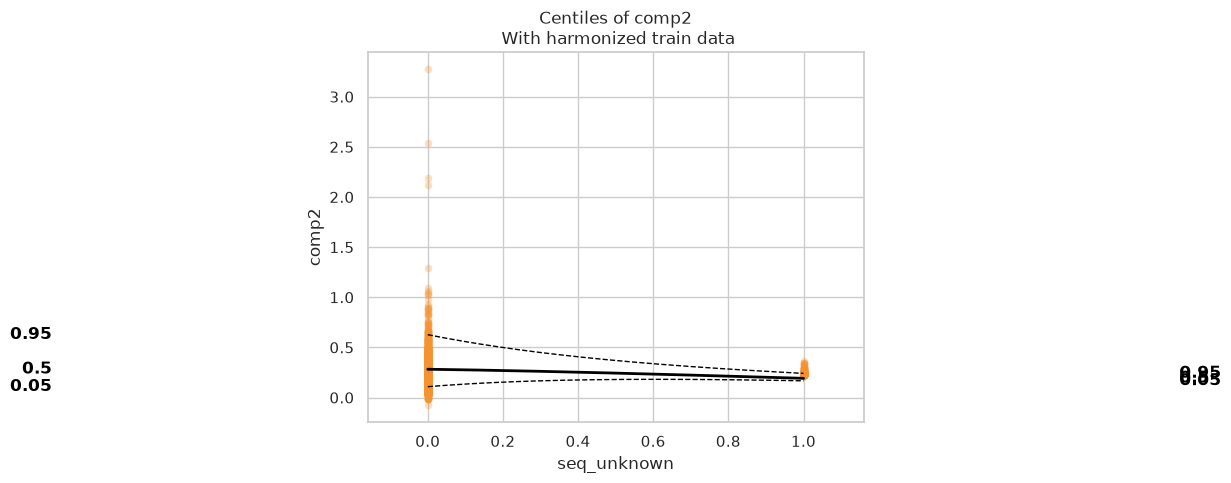

<Figure size 640x480 with 0 Axes>

/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


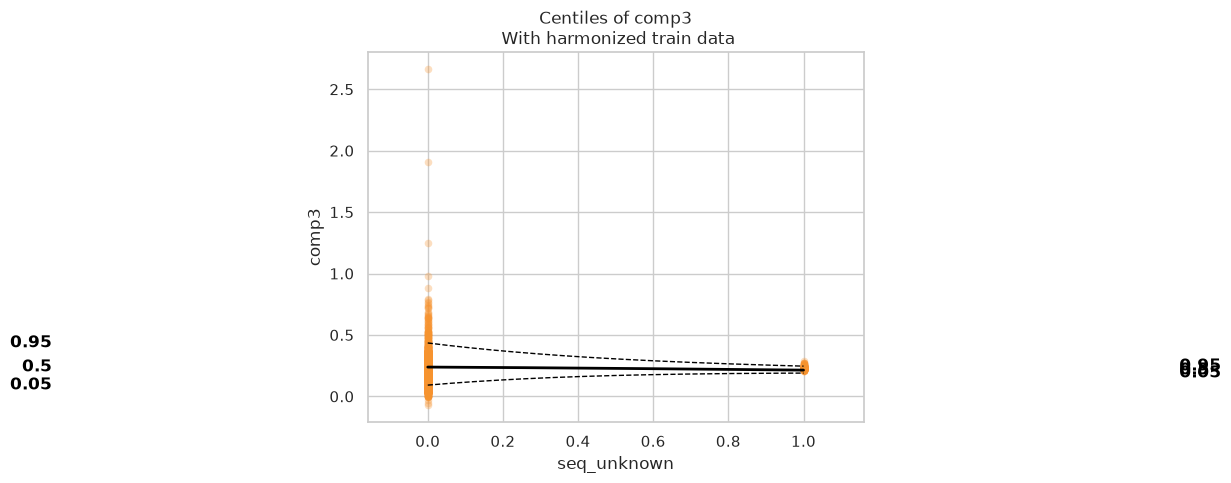

<Figure size 640x480 with 0 Axes>

/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


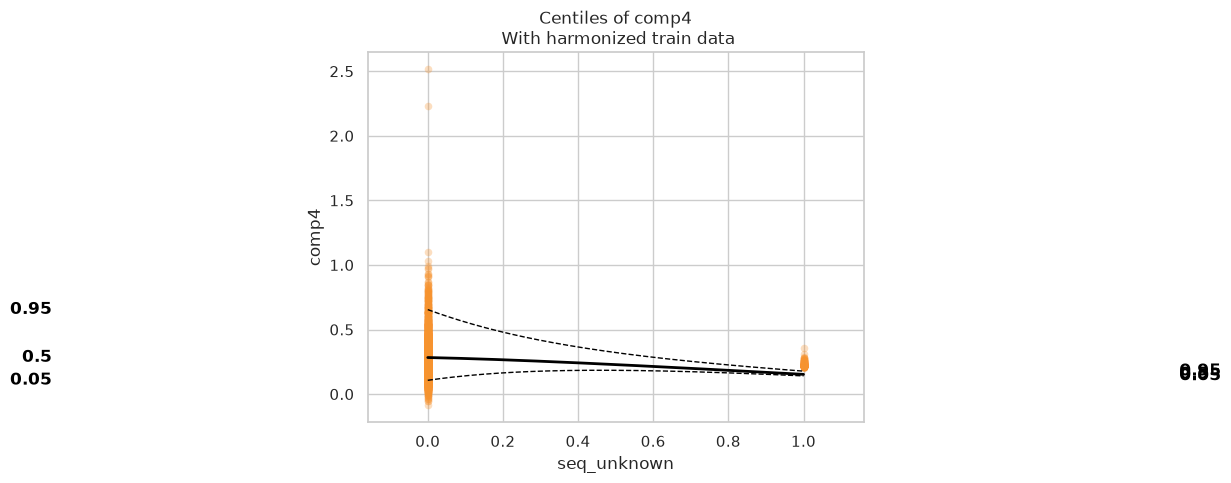

<Figure size 640x480 with 0 Axes>

/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


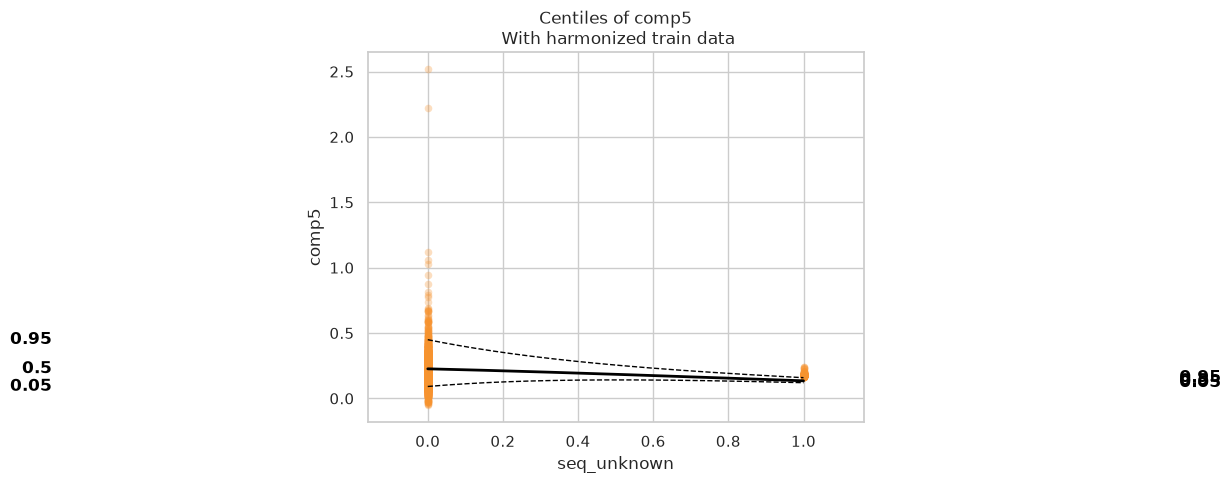

<Figure size 640x480 with 0 Axes>

/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


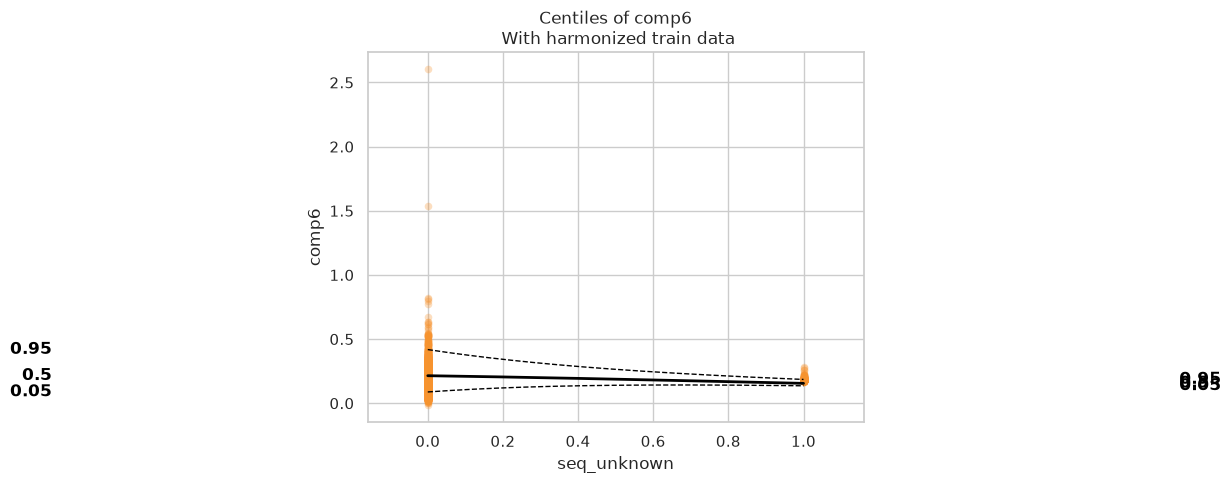

<Figure size 640x480 with 0 Axes>

/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


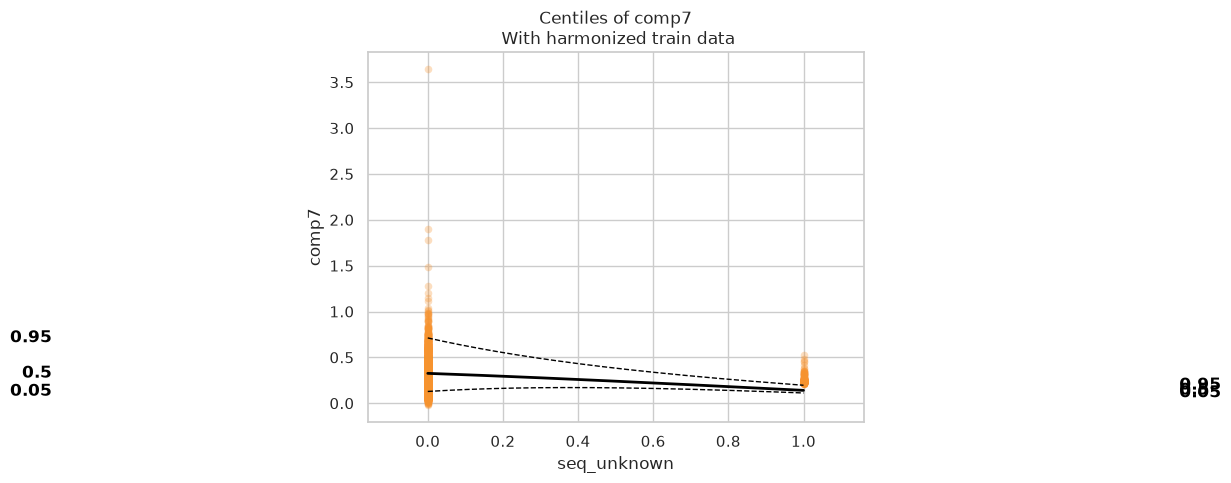

<Figure size 640x480 with 0 Axes>

/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


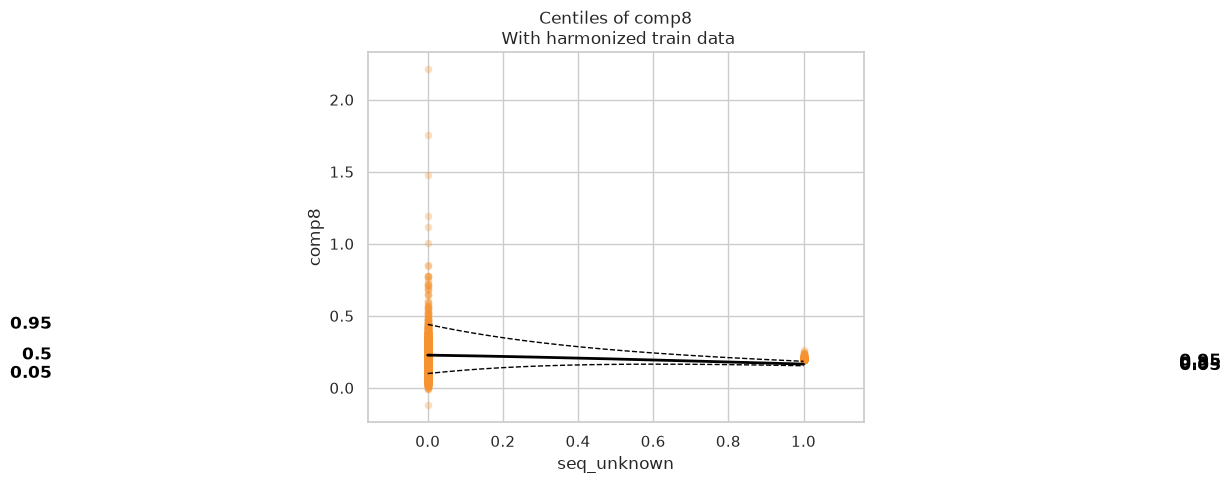

<Figure size 640x480 with 0 Axes>

/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


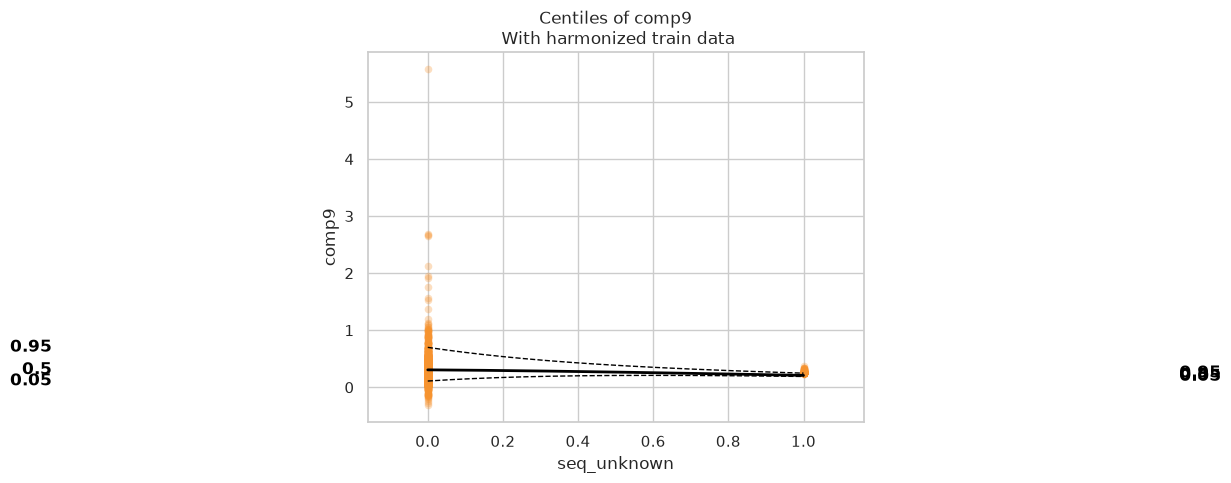

<Figure size 640x480 with 0 Axes>

/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


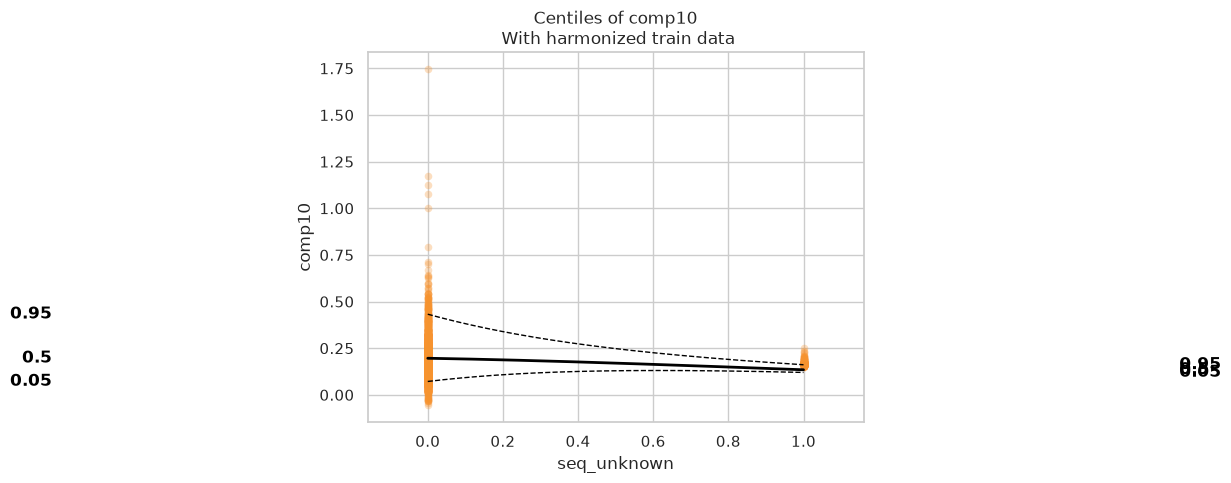

<Figure size 640x480 with 0 Axes>

/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


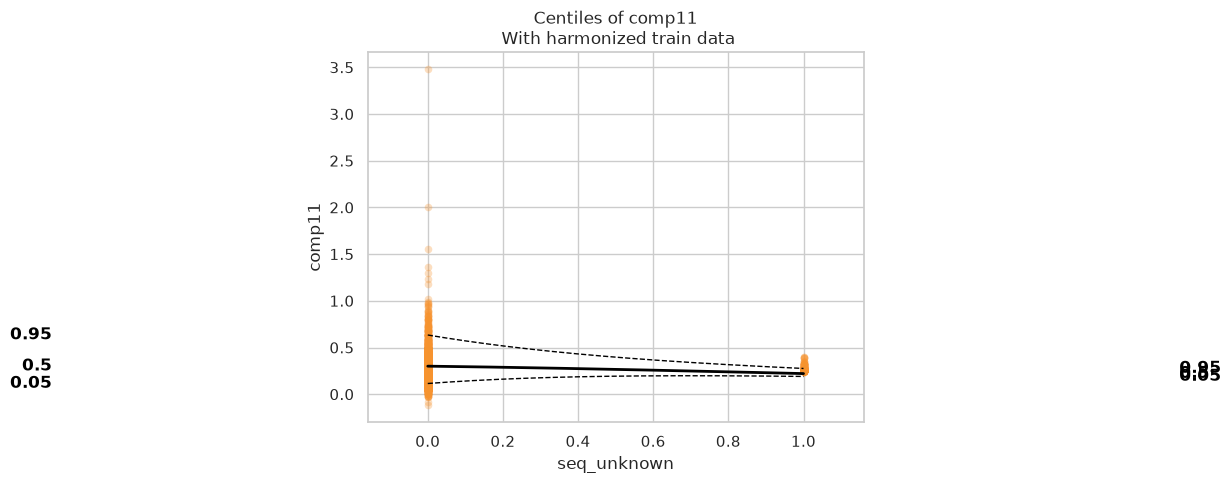

<Figure size 640x480 with 0 Axes>

/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


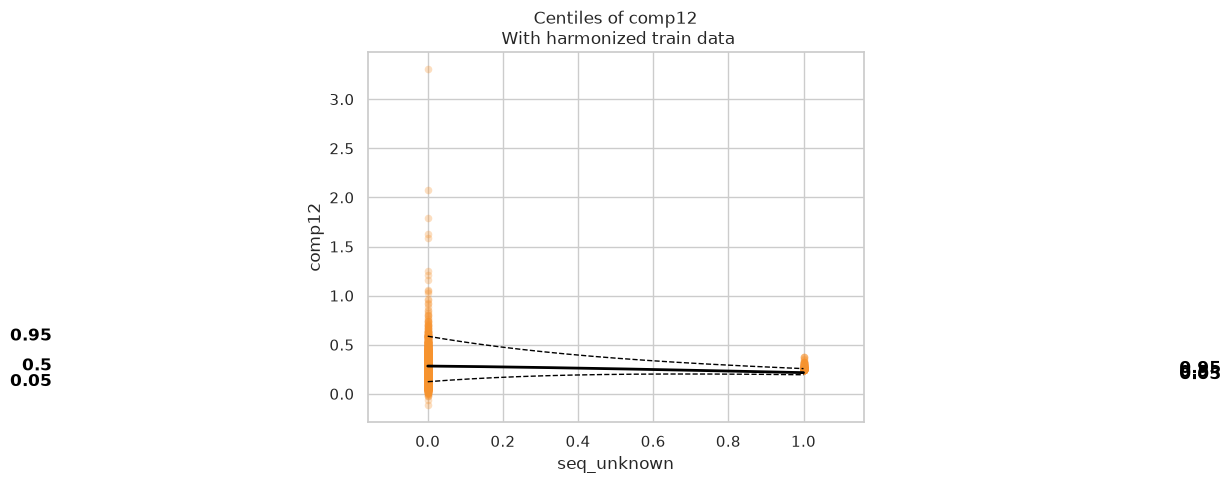

<Figure size 640x480 with 0 Axes>

/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


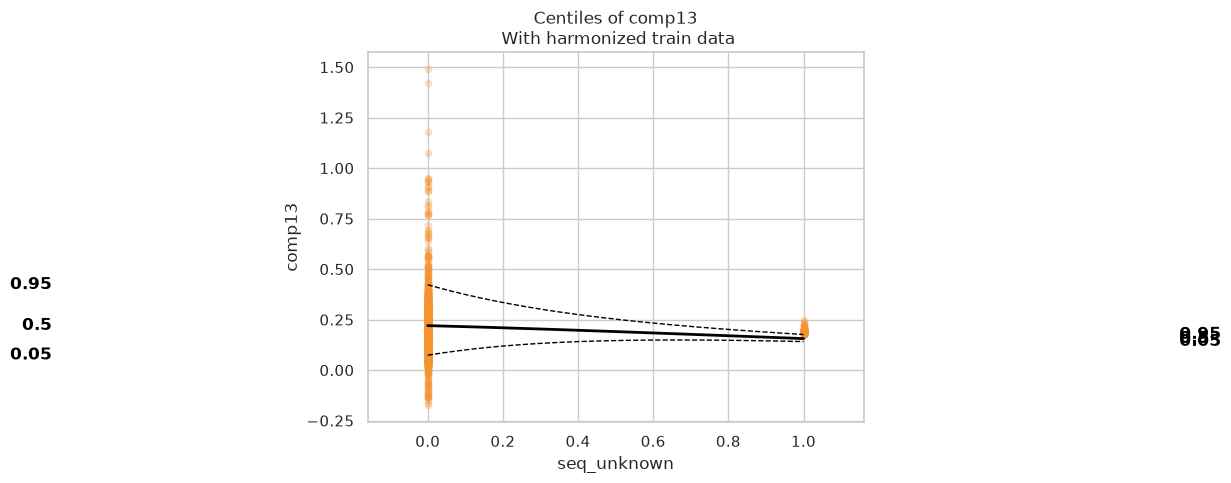

<Figure size 640x480 with 0 Axes>

In [ ]:
# Save plots
results_dir = Path("/home/traaffneu/bersal/digitalrodent/my_model/results")

# Centile plots: one subfolder per covariate, one plot per dummy column and component
for col, prefix in categorical.items():
    cov_dir = results_dir / col
    cov_dir.mkdir(parents=True, exist_ok=True)

    for dummy in [c for c in dummy_cols if c.startswith(prefix + "_")]:
        for comp in feature_to_model:
            plot_centiles(
                model,
                scatter_data=train,
                response_vars=[comp],
                centiles=[0.05, 0.5, 0.95],
                covariate=dummy,
                scatter_kwargs={"s": 30, "alpha": 0.3},
            )
            plt.gcf().savefig(cov_dir / f"centiles_{dummy}_{comp}.png", dpi=150, bbox_inches="tight")
            plt.show()

In [ ]:
# Statistics
print("Train set statistics:")
display(train.get_statistics_df().loc[feature_to_model])
print("Test set statistics:")
display(test.get_statistics_df().loc[feature_to_model])

train.get_statistics_df().loc[feature_to_model].to_csv(results_dir / "statistics_train.csv")
test.get_statistics_df().loc[feature_to_model].to_csv(results_dir / "statistics_test.csv")

In [ ]:
# QQ plots
qq_dir = results_dir / "qq"
qq_dir.mkdir(parents=True, exist_ok=True)

for comp in feature_to_model:
    plot_qq(test.sel({"response_vars": [comp]}), plot_id_line=True)
    plt.gcf().savefig(qq_dir / f"qq_{comp}.png", dpi=150, bbox_inches="tight")
    plt.show()